In [26]:
import sys, json, logging, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output

warnings.filterwarnings("ignore")
logging.disable(logging.INFO)          # the library logs each search stage at INFO

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "explainit").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from explainit.experiments.continuous_minlp._context import load_context
from explainit.experiments.continuous_minlp.priority_sets import PRIORITY_SETS, build_priorities
from explainit.experiments.continuous_minlp.priority_methods.methods import (
    compute_priority_score, max_attainable_priority,
)
from explainit.experiments.paper.common.registry import (
    RESULTS_ROOT, RunRegistry, current_run_ids,
)
from explainit.experiments.paper.common.runspec import expand_grid, load_study_config
from explainit.experiments.paper.common import stats

PAPER_DIR = PROJECT_ROOT / "explainit" / "experiments" / "paper"
FIGURES_DIR = PAPER_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "figure.autolayout": True})
pd.set_option("display.width", 200)

_CTX, _STUDY = {}, {}

def ctx(dataset):
    """Dataset + trained model, cached."""
    if dataset not in _CTX:
        _CTX[dataset] = load_context(dataset)
    return _CTX[dataset]

def study(name, stale=False):
    """Per-counterfactual rows of a study, restricted to the current config."""
    key = (name, stale)
    if key not in _STUDY:
        reg = RunRegistry(name)
        ids = None if stale else current_run_ids(name)
        _STUDY[key] = reg.load_counterfactuals(run_ids=ids)
    return _STUDY[key]

def available_studies():
    return sorted(p.name for p in RESULTS_ROOT.glob("*") if (p / "index.csv").exists())

def base_datasets():
    """Datasets with a priority set and a trained model, excluding factor variants."""
    out = []
    for key in sorted(PRIORITY_SETS):
        if "__" in key:
            continue
        if (PROJECT_ROOT / "explainit/experiments/continuous_minlp/models" / key / "model.keras").exists():
            out.append(key)
    return out

def save_fig(fig, name):
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight", dpi=200)
    print(f"saved {path}")
    return path

print("datasets with priorities:", base_datasets())
print("studies on disk:", available_studies())

datasets with priorities: ['auto_mpg', 'bike_sharing_hourly', 'brazilian_houses_to_rent', 'carseats', 'diabetes', 'diamonds', 'insurance_charges']
studies on disk: ['method_diagnosis', 'smoke', 'step2_validation', 'study1_hyperparams', 'study2_factors', 'study3_comparison']


# Results Explorer, revised version

This notebook is being rebuilt as a paper-writing workspace. The goal is to keep the explanations close to the current implementation, then layer results and interpretation on top of that foundation.

The method section below is implementation-grounded: it reflects the current logic in the search code, the priority materialisation code, and the paper experiment harness.

## Table of contents

### I. Method description

1. Problem setup and optimisation target
2. Main ingredients of the method
3. Pseudoalgorithm
4. Flow diagram
5. Detailed implementation notes
6. What the method is really doing in optimisation terms

### II. Experiment description

1. Datasets and models
2. Priorities
3. Diagnosis
4. Study I
5. Study II
6. Study III

### III. Results

4. Study I
5. Study II
6. Study III

## I. Method description

### 1. Problem setup

The paper workflow uses the continuous-regression version of the method. For one test sample, the method receives:

- a trained predictive model $f$
- the current sample $x$
- a requested target prediction $y^*$
- an allowed tolerance $\varepsilon$
- the training data, used as the search reference set
- a priority set describing which feature values are desirable, neutral, forbidden, or fixed

The search objective implemented in code is: find a counterfactual $x'$ such that $|f(x') - y^*| \leq \varepsilon$, and among all such solutions prefer the one with the highest total priority score.

In the current implementation, the total priority score is the sum of:

- one weight per actionable numerical feature, obtained by evaluating its priority function at the proposed value
- one weight per categorical group, obtained from the weight assigned to the active one-hot state

This means the method is not trying to find the smallest change in the classical distance-only sense. It is trying to find a target-reaching point that is as preferred as possible under the declared priorities.

### 2. Main ingredients

The implementation is built around four ideas.

1. Priorities are the main language of feasibility and preference.
Each numerical feature receives a desirability function over values, while each categorical feature receives weights over valid one-hot states. Features can also be declared non-actionable, in which case they are frozen at the sample's current value.

2. Priorities are materialised per sample.
Some priorities are contextual: their preferred region depends on the sample value or the dataset range. Before the search begins, the declarative priority set is turned into concrete per-feature functions, bounds, and categorical mappings for that specific sample.

3. The nonlinear model is replaced locally by a Shapley-based surrogate.
The true model is queried repeatedly, but the optimisation itself uses a local linear surrogate built from Shapley values between the current iterate and a target exemplar.

4. Search is hybrid rather than purely combinatorial.
The code does not call a generic MINLP solver. Instead, it combines:

- filtering and sampling to get a reachable anchor
- Shapley-based linearisation
- a bounded linear program to get warm starts
- SLSQP to refine numerical values
- a final greedy peak-locking sweep that tries to improve preference without leaving the target band

That implementation detail matters for the paper because it explains both the method's strengths and its failure modes.

### 3. Inputs and representation

Before optimisation, the code converts the declarative priority set into an explainer-ready representation.

- Numerical features are indexed by column number and stored as `{"function": fn, "min": ..., "max": ...}`.
- Categorical features are grouped by their one-hot columns and stored as mappings from one valid one-hot tuple to one weight.
- Non-actionable numerical features are converted into degenerate bounds with `min = max = current sample value`.
- Non-actionable categorical features are converted into a mapping where only the sample's current one-hot state is allowed.

A useful implementation detail is that valid one-hot behaviour is enforced by representation. The search never flips individual category dummy columns independently. Instead, it switches between entire allowed one-hot tuples.

### 4. Pseudoalgorithm

The current implementation can be summarised as follows.

1. Materialise the priority set for the chosen dataset and the current sample.
2. For each actionable numerical feature, derive the allowed intervals where the priority function is strictly positive. These intervals define the real feasible search region.
3. Find a target exemplar.
If there is a training row inside the allowed region whose prediction is close enough to the requested target, use it. Otherwise sample the allowed region randomly until a point within $\varepsilon$ of the target is found.
4. Treat that exemplar as a fixed anchor for the rest of the run.
5. Compute Shapley values between the current iterate and the anchor. Numerical features stay separate; each one-hot categorical block is merged into one Shapley unit.
6. Build a local surrogate model around the current iterate.
For numerical features the code converts Shapley values into per-unit coefficients; for categorical groups the code treats moving from the sample state to the anchor state as a discrete Shapley jump.
7. Reduce the categorical search space.
If a categorical group's Shapley value is zero, keep only the sample's current category. Otherwise allow at most two states in that group: the sample state and the anchor state.
8. For every surviving categorical combination, solve a bounded linear program to obtain a feasible numerical warm start inside the surrogate target band.
9. Starting from each warm start, run SLSQP to maximise total priority score while keeping the surrogate prediction inside the target band.
10. Evaluate the best candidate with the true model, update the incumbent, and optionally re-linearise from the new iterate.
11. After the iterative loop, run a greedy peak-locking pass that tries to move features onto priority peaks while compensating with other features so the prediction stays in band.
12. Return the feasible counterfactual with the highest achieved priority score. If no feasible one exists, return the best near-miss only if failure-return mode is enabled.

### 5. Flow diagram

```mermaid
flowchart TD
    A[Sample x, target y target, model f, dataset D, priority set P] --> B[Materialise priorities for this sample]
    B --> C[Derive allowed numerical intervals from positive priority regions]
    C --> D{Find target exemplar near target}
    D -->|feasible dataset row| E[Use filtered dataset exemplar]
    D -->|no such row| F[Randomly sample allowed region until target band is hit]
    E --> G[Current iterate equals sample, anchor equals exemplar]
    F --> G
    G --> H[Compute Shapley values between iterate and anchor]
    H --> I[Prune categorical states using categorical Shapley values]
    I --> J[Build local linear surrogate]
    J --> K[LP warm start for each surviving categorical combination]
    K --> L[SLSQP refinement under surrogate target band]
    L --> M[Evaluate candidate with true model]
    M --> N{Accepted or improved}
    N -->|yes| O[Update incumbent and optionally advance iterate]
    N -->|no| P[Keep incumbent and optionally shrink step controls]
    O --> Q{More refinement passes}
    P --> Q
    Q -->|yes| H
    Q -->|no| R[Greedy peak lock in with Shapley compensation]
    R --> S[Return best feasible counterfactual by priority score]
```

### 6. Detailed stage-by-stage explanation

To make the stages concrete, it helps to keep one tiny running example in mind. Suppose the current sample has two actionable numerical features and one categorical group:

- current sample: `income = 0.20`, `hours = 0.80`, `transport = car`
- target prediction: $y^* = 0.45$
- tolerance: $\varepsilon = 0.05$
- current model prediction: $f(x) = 0.70$

So the method is trying to move the prediction downward into the interval $[0.40, 0.50]$ while keeping the resulting feature values as desirable as possible under the priorities.

### 6.1 Stage 0: derive the true allowed numerical region

This stage is easy to miss, but it is central to how the method actually works.

The code does not trust only user-declared min and max bounds. Instead, for each actionable numerical feature it scans the feature's priority function over the dataset support and extracts the intervals where the priority is positive. Those intervals are stored as `allowed_intervals`. As a result:

- zero-priority gaps inside a broad min-max box are excluded from the search
- the effective feasible region is defined by positive desirability, not only by simple bounds
- later LP and SLSQP steps must respect both outer bounds and internal gaps

So in practice the method searches inside the support of the priority functions, not inside a plain hyper-rectangle.

Mini example. Suppose `income` has declared outer bounds `[0.0, 1.0]`, but its priority is positive only on `[0.0, 0.35]` and `[0.55, 0.90]`. Then the search is not allowed to use values like `0.45` at all, even though `0.45` lies inside the broad min-max box. The effective allowed region is the union of the two positive-priority intervals.

### 6.2 Stage 1: choose a reachable anchor

The target exemplar is not chosen by preference. It is chosen by reachability.

First, the training set is filtered by:

- categorical states that are not forbidden
- numerical bounds
- numerical positive-priority intervals

Among the remaining rows, the method selects the one whose model prediction is closest to the requested target. If the closest row is still farther than `target_exemplar_epsilon`, the code falls back to random sampling inside the allowed region and accepts the first sampled point that lands within $\varepsilon$ of the target.

This is important conceptually: the exemplar is a target-reaching anchor, not the final counterfactual and not necessarily a high-priority point.

Mini example. After filtering, suppose three eligible training rows remain, with predictions `0.62`, `0.49`, and `0.37`. The target is `0.45`, so the row with prediction `0.49` is chosen because its distance to target is only `0.04`. If no filtered row were that close, the code would randomly sample allowed points until it found one with prediction between `0.40` and `0.50`.

### 6.3 Stage 2: freeze the feasible frame

At this point the search has:

- one fixed anchor exemplar
- a concrete feasible region for every actionable numerical feature
- a set of frozen features that the optimisation is not allowed to move

From here on, the search is local and structured around that frame.

Mini example. Suppose the chosen anchor is `income = 0.60`, `hours = 0.30`, `transport = bus`, with prediction `0.49`. From now on, the search linearises the model between the current point `(0.20, 0.80, car)` and that fixed anchor `(0.60, 0.30, bus)`. It does not choose a new anchor every time SLSQP tests another candidate.

### 6.4 Stage 3: compute Shapley values between iterate and exemplar

The code computes Shapley values between the current iterate and the anchor exemplar. The purpose is not explanation for its own sake. The purpose is to obtain a local decomposition of the prediction gap.

Two implementation choices are especially important.

1. Numerical features remain one-by-one variables.
2. One-hot categorical groups are collapsed into single Shapley units.

That second choice avoids assigning separate Shapley values to mutually exclusive dummy columns and gives the method one group-level contribution for each categorical variable.

The code supports:

- exact Shapley computation by enumerating all subsets of the consolidated feature set
- approximate Shapley computation by Monte Carlo subset sampling

Mini example. Suppose the prediction drops from `0.70` at the sample to `0.49` at the anchor, so the total change is `-0.21`. The Shapley decomposition might say:

- `income` contributes `-0.08`
- `hours` contributes `-0.05`
- `transport` changing from `car` to `bus` contributes `-0.08`

These three contributions sum to `-0.21`, which is exactly the total model change between sample and anchor.

### 6.5 Stage 4: turn Shapley values into a local optimisation problem

For each numerical feature $i$, the code builds a local coefficient

$$
c_i = \frac{\phi_i}{x_i^{\text{anchor}} - x_i^{\text{current}}}
$$

with the convention that $c_i = 0$ if the anchor and current value coincide.

Using those coefficients, the surrogate prediction has the form

$$
h(x') = f(x) + \sum_i c_i (x'_i - x_i) + \text{categorical jump}(x').
$$

The categorical part is discrete: if a categorical group stays in the sample's state, it contributes 0; if it switches to the anchor's state, it contributes that group's Shapley value.

This surrogate is then used in two ways.

First, the code prunes categorical combinations. If a categorical group has zero Shapley value, the group is fixed to the sample state. Otherwise the group may take at most two states: sample-state or anchor-state. The Cartesian product of those options defines the categorical combinations that remain in play.

Second, for each surviving categorical combination, the code constructs an adjusted linear target for the numerical variables and solves a bounded linear program. The LP is not the final answer. Its role is to find at least one numerically feasible point whose surrogate prediction lands in the target band, so SLSQP has a sensible warm start.

Mini example. With the Shapley values above, the numerical coefficients become

$$
c_{income} = \frac{-0.08}{0.60 - 0.20} = -0.20, \qquad
c_{hours} = \frac{-0.05}{0.30 - 0.80} = 0.10.
$$

If `transport` stays at `car`, its categorical jump is `0`. If it switches to `bus`, its categorical jump is `-0.08`. So one surrogate version is

$$
h(x') = 0.70 - 0.20(income' - 0.20) + 0.10(hours' - 0.80),
$$

and the `bus` version is the same expression minus another `0.08`.

### 6.6 Stage 5: optimise preference subject to the surrogate band

Starting from each LP solution, the code runs SLSQP over the actionable numerical features.

The optimisation target is the negative of the total priority score, so SLSQP effectively maximises preference. The constraints force the surrogate prediction to stay inside the target band, and the bounds plus interval checks prevent stepping into forbidden numerical regions.

This reveals the real optimisation problem solved by the implementation:

- objective: maximise declared preference
- feasibility proxy: satisfy the Shapley-linear surrogate
- validation: check the resulting point on the true model afterwards

That is a stronger and more accurate description than saying only that the method 'searches for a counterfactual'.

Mini example. Suppose the LP finds a feasible warm start `income = 0.52`, `hours = 0.44` for the `bus` category. SLSQP may then improve preference by moving to `income = 0.58`, `hours = 0.47` as long as the surrogate prediction remains within `0.45 \pm 0.05`. So LP provides feasibility first; SLSQP spends that feasibility budget on preference improvement.

### 6.7 Stage 6: select the best candidate across categorical combinations

If there are several categorical combinations, SLSQP returns one candidate per combination. The method selects the candidate with the highest evaluable total priority score.

If none of the candidates has a valid score, the code falls back to the first one, but that is explicitly treated as a degraded situation in the logs.

Mini example. Suppose the best `car` candidate has priority score `1.30` and the best `bus` candidate has priority score `1.46`, with both satisfying the surrogate target band. The method keeps the `bus` candidate, because Stage 6 is a best-over-combinations selection step.

### 6.8 Iterative re-linearisation

The method is iterative.

After Stage 6, the chosen candidate is evaluated with the real model. Then the algorithm tracks two incumbents:

- `best_feasible`: the best candidate that truly satisfies $|f(x') - y^*| \leq \varepsilon$, ranked by priority score
- `best_infeasible`: the closest candidate to the target while no feasible solution exists yet

If a candidate is accepted, the current iterate can be advanced to that candidate and the method recomputes Shapley values around the new point while keeping the same anchor exemplar. This is the mechanism that lets the method walk toward better feasible regions instead of trusting one linearisation.

The implementation also contains optional step-control mechanisms:

- trust-region control
- residual correction
- restoration of near-miss candidates back into the target band

These are implemented in the explainer, but the current paper study configurations switch them off. That is worth stating explicitly later in the experiment section, because the paper results are about a specific operating regime of the method, not every feature present in the code.

Mini example. Suppose SLSQP proposes a candidate whose surrogate prediction is `0.46`, but the real model prediction is `0.53`. That candidate is outside the true target band, so it is not yet a feasible incumbent. If no better feasible point exists, it may still become `best_infeasible` because its real-model distance to target is only `0.08`. On the next iteration, the method can linearise again around this updated point and try to close the remaining gap.

### 6.9 Stage 7: peak lock-in

After the main loop, the code can run one more preference-improvement step called peak lock-in.

For each actionable numerical feature, it checks whether moving that feature directly to the peak of its priority function would increase the total score. If yes, it tries to compensate for the induced prediction change by adjusting another feature with the smallest preference loss per unit of prediction correction. The move is accepted only if:

- the true model prediction remains inside the target band
- the total priority score strictly improves

So this stage is a greedy post-processor that tries to keep the candidate feasible while snapping features to more preferred locations.

Mini example. Suppose the current feasible counterfactual is `income = 0.58`, `hours = 0.47` with prediction `0.44`, but the priority peak for `income` is `0.62`. Moving `income` to `0.62` may raise the prediction to `0.47`. If lowering `hours` slightly to `0.43` brings the prediction back to `0.45` while increasing the total priority score from `1.46` to `1.52`, the move is accepted. If it breaks validity or reduces total priority, it is rejected.

### 7. What the method is really doing

A useful paper-level interpretation of the implementation is this:

- It is a preference-constrained counterfactual search method.
- It uses the dataset to find a reachable target-side anchor.
- It uses Shapley values to linearise the model locally around the current iterate.
- It uses LP only for warm starts, not for the final search.
- It uses SLSQP for the actual continuous optimisation of preference.
- It handles categorical variables by enumerating a heavily pruned set of valid one-hot states rather than by solving a full mixed-integer program.

So despite the historical `MINLP` name, the implemented method is best described as a hybrid local search procedure with Shapley-guided surrogate constraints and priority-driven objective optimisation.

That interpretation is important for the rest of the notebook because it gives a precise language for later sections: when we analyse failures, cost, and comparative performance, we should ask which part of this pipeline is responsible.

## II. Experiment description

### 1. Datasets and models

This section describes the experimental data and predictive models from the current codebase, not from a separate paper draft. The relevant implementation lives in:

- `explainit/experiments/continuous_minlp/data_setup.py` for raw-data loading, feature typing, preprocessing, train/test splitting, and dataset caching
- `explainit/experiments/continuous_minlp/model_setup.py` for model construction, training, evaluation, and model caching
- `explainit/experiments/continuous_minlp/_context.py` for loading the cached dataset-model pair back into the experiment pipeline
- `explainit/experiments/paper/study2_factors/factor_datasets.py` for derived Study II dataset variants

#### 1.1 Which datasets exist in the workspace

There are four practically different groups of datasets in the current project state.

1. **Datasets used directly in the paper studies.**
These are the datasets that appear in the paper experiment configs: `auto_mpg`, `carseats`, `bike_sharing_hourly`, `diabetes`, and `insurance_charges`.

2. **Datasets already prepared, modelled, and also equipped with priority sets.**
These are immediately reusable inside the current priority-based counterfactual pipeline: `auto_mpg`, `bike_sharing_hourly`, `brazilian_houses_to_rent`, `carseats`, `diabetes`, `diamonds`, and `insurance_charges`.

3. **Datasets already prepared and modelled, but not yet wired into the current priority-set registry.**
These exist on disk and have trained models, but they are not immediately usable in the current counterfactual studies until matching priority sets are defined: `wage`, `cps85`, and `forest_fires`.

4. **Datasets defined in code but not currently active in the registry.**
`california_housing` and `synthetic` have loader functions and target-name entries in `data_setup.py`, but they are commented out in the active `DATASETS` registry, so they are not part of the current prepared artifact set.

In addition, Study II creates many **derived dataset variants** such as `auto_mpg__train_size_0p5` or `carseats__label_noise_0p2`. Those variants are saved exactly like ordinary datasets under the same cache directories, but they are generated by factor logic rather than by direct raw-data loading.

#### 1.2 How raw datasets are loaded

Raw dataset loading is implemented as one loader function per dataset in `data_setup.py`. The source is dataset-specific:

- `diabetes` is loaded from `sklearn.datasets.load_diabetes`
- `auto_mpg` and `diamonds` are loaded from seaborn-hosted CSV files
- `bike_sharing_hourly` and `forest_fires` are loaded from UCI sources
- `carseats`, `wage`, and `cps85` are loaded from Rdatasets
- `insurance_charges` and `brazilian_houses_to_rent` are loaded from external CSV URLs

Operationally, adding a new base dataset means adding one raw loader function and one entry in the `DATASETS` registry.

#### 1.3 How datasets are preprocessed

The preprocessing pipeline is implemented in `_prepare_dataset(...)` in `data_setup.py`. The exact steps are:

1. load raw `X` and `y`
2. detect categorical and numerical features, with manual overrides from `CATEGORICAL_FEATURES` and `NUMERICAL_FEATURES`
3. split into train and test sets with `train_test_split(test_size=0.2, random_state=42)`
4. standard-scale only the numerical columns using `StandardScaler`
5. one-hot encode categorical columns using category codes derived from the full raw dataset
6. reassemble the final matrix in the original logical feature order, replacing each categorical feature with its one-hot block
7. transform the target if configured in `TARGET_TRANSFORMS`
8. min-max scale the target to `[0, 1]` using `TargetScaler` and `MinMaxScaler`

A few implementation details matter for later interpretation.

- The default split is always **80% train / 20% test**.
- Numerical scaling is applied only to numerical features; categorical features become 0/1 one-hot columns.
- The target is scaled to `[0, 1]` for all experiment datasets.
- `wage` uses a `log1p` target transform before min-max scaling; the other active datasets use the identity transform.
- Raw train/test views are also preserved in the saved payload, so the project retains both the preprocessed and pre-encoding versions of the split.

The saved dataset payload includes:

- the processed train/test matrices
- the raw train/test matrices
- feature names before and after one-hot encoding
- numerical feature names
- categorical feature names and their one-hot group metadata
- the fitted `x_scaler` and `y_scaler`
- feature-analysis CSV paths and typing reasons

#### 1.4 Where prepared datasets are saved

Prepared datasets are cached under `setup_dataset(...)` in:

- `explainit/experiments/continuous_minlp/data/<dataset_key>/data.pkl`

Automatic feature summaries are written under:

- `explainit/experiments/continuous_minlp/data_analysis/<dataset_key>/numerical_features.csv`
- `explainit/experiments/continuous_minlp/data_analysis/<dataset_key>/categorical_features.csv`

Study II variants are materialised by `materialise(...)` in `study2_factors/factor_datasets.py` and written to the same kind of cache path, just under variant keys such as `auto_mpg__feature_noise_0p25`.

#### 1.5 How models are built and trained

Model training is implemented in `train_model_with_report(...)` in `model_setup.py`. The project uses TensorFlow / Keras regressors, with one saved model per prepared dataset.

The common model family is `build_mlp_regressor(...)`, which creates a feed-forward MLP with:

- dense ReLU hidden layers
- a final linear output layer
- Adam optimiser
- mean-squared-error loss unless overridden
- optional dropout and L2 regularisation

The dataset-specific builder registry `MODEL_BUILDERS` then overrides the base architecture for selected datasets. In the current code:

- default architecture: hidden layers `(64, 32)`, learning rate `1e-3`, loss `mse`, dropout `0`, L2 `0`
- `diabetes`: `(192, 96, 48)`, learning rate `7e-4`, dropout `0.05`, L2 `1e-5`
- `bike_sharing_hourly`: `(256, 128)`
- `insurance_charges`: `(256, 128)`
- `carseats`: `(256, 128)`
- `wage`: default hidden layers with dropout `0.1`
- `cps85`: `(256, 128)`, learning rate `5e-4`, Huber loss, L2 `1e-5`
- `auto_mpg`: default hidden layers with L2 `1e-4`
- `forest_fires`: no hidden layers, effectively a linear-output model
- `brazilian_houses_to_rent`: default hidden layers with L2 `1e-4`

Training defaults are dataset-specific through `TRAINING_DEFAULTS`. Examples:

- `auto_mpg`: `epochs=250`, `batch_size=32`
- `carseats`: `epochs=250`, `batch_size=32`
- `bike_sharing_hourly`: `epochs=120`, `batch_size=128`
- `diabetes`: `epochs=200`, `batch_size=32`
- `forest_fires`: `epochs=600`, `batch_size=32`, `patience=100`

The training loop also applies:

- `tf.keras.utils.set_random_seed(42)` for reproducibility
- `EarlyStopping(monitor='val_loss', restore_best_weights=True)`
- `ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=max(10, patience/2), min_lr=1e-5)`

One important methodological detail is that the code uses the saved test split as the Keras validation set during training. So the same split is serving both as the monitored validation loss source and as the held-out evaluation set later. That is the current implementation and should be reported honestly.

#### 1.6 How models are evaluated and where results are saved

After training, `model_setup.py` computes regression metrics on both the scaled target and the inverse-transformed raw target using `_compute_regression_metrics(...)`:

- `R2`
- `RMSE`
- `MAE`
- `MSE`
- `MAPE` where defined

Models are saved by `model.save(...)` under:

- `explainit/experiments/continuous_minlp/models/<dataset_key>/model.keras`

The model-score summary is written by `_write_model_analysis_csv(...)` to:

- `explainit/experiments/continuous_minlp/model_analysis/model_analysis.csv`

This is the main registry of fitted model quality used by the experiment notebook.

#### 1.7 Which datasets are actually used in the paper studies

At the study-config level, the current paper experiments use datasets as follows:

- `method_diagnosis`: `diabetes`, plus `insurance_charges`, `carseats`, and `auto_mpg` for the generic-priority diagnosis arms
- `step2_validation`: `diabetes`
- `study1_hyperparams`: `auto_mpg`, `carseats`, with `diabetes` only as a stress-case verification arm
- `study2_factors`: `auto_mpg`, `carseats`, `bike_sharing_hourly`, plus many derived variants of `auto_mpg` and `carseats`
- `study3_comparison`: `auto_mpg`, `carseats`, `bike_sharing_hourly`

So the main comparative paper backbone is built around `auto_mpg`, `carseats`, and `bike_sharing_hourly`, with `diabetes` and `insurance_charges` used mainly as diagnostic or stress-case datasets.

#### 1.8 What to read in the live tables below

The code cell below reads the saved dataset pickles and the saved model-analysis CSV. It gives four views:

- which base datasets are prepared on disk
- which of those base datasets are currently used in at least one study config
- which of those base datasets currently have priority sets
- one row per logical raw feature with its inferred type
- one row per base dataset model with architecture summary, training defaults, and saved evaluation metrics



In [27]:
import pickle

from IPython.display import HTML

from explainit.experiments.continuous_minlp.data_setup import DATA_DIR
from explainit.experiments.continuous_minlp.model_setup import MODELS_DIR, TRAINING_DEFAULTS
from explainit.experiments.continuous_minlp.priority_sets import PRIORITY_SETS
from explainit.experiments.paper.common.runspec import expand_grid, load_study_config

def _base_dataset_keys():
    keys = []
    for path in sorted(DATA_DIR.iterdir()):
        if not path.is_dir() or "__" in path.name:
            continue
        if (path / "data.pkl").exists():
            keys.append(path.name)
    return keys

def _used_base_datasets():
    used = set()
    for cfg_path in sorted(PAPER_DIR.glob("*/config.yaml")):
        cfg = load_study_config(cfg_path)
        for spec in expand_grid(cfg):
            used.add(str(spec.dataset).split("__", 1)[0])
    return used

def _model_builder_summary(dataset_key):
    if dataset_key == "diabetes":
        return "MLP 192-96-48, Adam lr=7e-4, dropout=0.05, L2=1e-5"
    if dataset_key == "bike_sharing_hourly":
        return "MLP 256-128, Adam lr=1e-3, MSE"
    if dataset_key == "insurance_charges":
        return "MLP 256-128, Adam lr=1e-3, MSE"
    if dataset_key == "wage":
        return "MLP 64-32, Adam lr=1e-3, MSE, dropout=0.1"
    if dataset_key == "carseats":
        return "MLP 256-128, Adam lr=1e-3, MSE"
    if dataset_key == "cps85":
        return "MLP 256-128, Adam lr=5e-4, Huber, L2=1e-5"
    if dataset_key == "auto_mpg":
        return "MLP 64-32, Adam lr=1e-3, MSE, L2=1e-4"
    if dataset_key == "forest_fires":
        return "Linear output only, Adam lr=1e-3, MSE"
    if dataset_key == "brazilian_houses_to_rent":
        return "MLP 64-32, Adam lr=1e-3, MSE, L2=1e-4"
    return "MLP 64-32, Adam lr=1e-3, MSE"

def _frame_to_html(df):
    return HTML(
        "<div style='overflow-x:auto; max-width:100%;'>"
        + df.to_html(index=False, escape=False)
        + "</div>"
    )

base_keys = _base_dataset_keys()
used_keys = _used_base_datasets()

dataset_rows = []
feature_rows = []
for key in base_keys:
    with open(DATA_DIR / key / "data.pkl", "rb") as handle:
        data = pickle.load(handle)

    raw_features = list(data.get("raw_feature_names", []))
    numerical = set(data.get("numerical_features", []))
    categorical = set(data.get("categorical_features", []))
    categorical_groups = data.get("categorical_groups", {})

    dataset_rows.append({
        "dataset": key,
        "used_in_studies": key in used_keys,
        "has_priority_sets": key in PRIORITY_SETS,
        "target": data.get("target_name"),
        "rows_total": len(data["X_train"]) + len(data["X_test"]),
        "train_rows": len(data["X_train"]),
        "test_rows": len(data["X_test"]),
        "raw_feature_count": len(raw_features),
        "expanded_feature_count": len(data.get("feature_names", [])),
        "numerical_feature_count": len(data.get("numerical_features", [])),
        "categorical_feature_count": len(data.get("categorical_features", [])),
        "target_transform": data.get("target_transform") or "identity",
        "dataset_cache": str(DATA_DIR / key / "data.pkl"),
    })

    for feature_name in raw_features:
        if feature_name in numerical:
            feature_rows.append({
                "dataset": key,
                "feature": feature_name,
                "type": "numerical",
                "expanded_width": 1,
                "encoded_columns": feature_name,
                "source_values": "",
                "column_indices": "",
            })
            continue

        group = categorical_groups.get(feature_name, {})
        feature_rows.append({
            "dataset": key,
            "feature": feature_name,
            "type": "categorical",
            "expanded_width": len(group.get("columns", [])),
            "encoded_columns": ", ".join(group.get("columns", [])),
            "source_values": ", ".join(map(str, group.get("source_values", []))),
            "column_indices": ", ".join(map(str, group.get("indices", []))),
        })

dataset_df = pd.DataFrame(dataset_rows).sort_values(["used_in_studies", "has_priority_sets", "dataset"], ascending=[False, False, True])
feature_df = pd.DataFrame(feature_rows).sort_values(["dataset", "type", "feature"]).reset_index(drop=True)

analysis_path = PAPER_DIR.parent / "continuous_minlp" / "model_analysis" / "model_analysis.csv"
model_metrics = pd.read_csv(analysis_path) if analysis_path.exists() else pd.DataFrame()
if not model_metrics.empty:
    model_metrics = model_metrics[model_metrics["status"] == "trained"].copy()
    model_metrics = model_metrics.sort_values("run_timestamp_utc").drop_duplicates("dataset_key", keep="last")

model_rows = []
for key in base_keys:
    row = {
        "dataset": key,
        "model_cache": str(MODELS_DIR / key / "model.keras"),
        "model_present": (MODELS_DIR / key / "model.keras").exists(),
        "builder": _model_builder_summary(key),
        "training_defaults": str(TRAINING_DEFAULTS.get(key, {})),
        "scaled_test_r2": np.nan,
        "raw_test_r2": np.nan,
        "raw_test_rmse": np.nan,
        "raw_test_mae": np.nan,
    }
    if not model_metrics.empty and key in set(model_metrics["dataset_key"]):
        hit = model_metrics[model_metrics["dataset_key"] == key].iloc[0]
        row.update({
            "scaled_test_r2": hit.get("scaled_test_r2"),
            "raw_test_r2": hit.get("raw_test_r2"),
            "raw_test_rmse": hit.get("raw_test_rmse"),
            "raw_test_mae": hit.get("raw_test_mae"),
        })
    model_rows.append(row)

model_df = pd.DataFrame(model_rows).sort_values("dataset").reset_index(drop=True)

overview_columns = [
    "dataset",
    "used_in_studies",
    "has_priority_sets",
    "target",
    "rows_total",
    "train_rows",
    "test_rows",
    "raw_feature_count",
    "expanded_feature_count",
    "target_transform",
]

summary_fields = [
    "dataset",
    "used_in_studies",
    "has_priority_sets",
    "target",
    "rows_total",
    "train_rows",
    "test_rows",
    "raw_feature_count",
    "expanded_feature_count",
    "numerical_feature_count",
    "categorical_feature_count",
    "target_transform",
    "dataset_cache",
]

model_fields = [
    "dataset",
    "model_present",
    "builder",
    "training_defaults",
    "scaled_test_r2",
    "raw_test_r2",
    "raw_test_rmse",
    "raw_test_mae",
    "model_cache",
]

display(Markdown("### Dataset overview"))
display(Markdown("The summary table below lists all prepared base datasets. Use the selector to inspect one dataset at a time. The feature table is rendered in full, with one logical feature per row and no row slicing."))
display(_frame_to_html(dataset_df[overview_columns].reset_index(drop=True)))

dataset_selector = widgets.Dropdown(
    options=base_keys,
    value=base_keys[0] if base_keys else None,
    description="Dataset:",
    layout=widgets.Layout(width="420px"),
    style={"description_width": "initial"},
)

details_output = widgets.Output()

def _render_dataset_details(selected_dataset):
    with details_output:
        clear_output(wait=True)
        if not selected_dataset:
            display(Markdown("No prepared datasets were found."))
            return

        dataset_slice = dataset_df[dataset_df["dataset"] == selected_dataset][summary_fields]
        dataset_details = dataset_slice.T.reset_index()
        dataset_details.columns = ["field", "value"]

        model_slice = model_df[model_df["dataset"] == selected_dataset][model_fields]
        model_details = model_slice.T.reset_index()
        model_details.columns = ["field", "value"]

        selected_features = feature_df[feature_df["dataset"] == selected_dataset].drop(columns=["dataset"]).reset_index(drop=True)

        display(Markdown(f"### Selected dataset: `{selected_dataset}`"))
        display(Markdown("#### Dataset details"))
        display(_frame_to_html(dataset_details))
        display(Markdown("#### Model details"))
        display(_frame_to_html(model_details.round(4)))
        display(Markdown(f"#### Feature details ({len(selected_features)} rows)"))
        display(_frame_to_html(selected_features))

dataset_selector.observe(
    lambda change: _render_dataset_details(change["new"]) if change["name"] == "value" else None,
    names="value",
)

display(dataset_selector)
display(details_output)
_render_dataset_details(dataset_selector.value)

### Dataset overview

The summary table below lists all prepared base datasets. Use the selector to inspect one dataset at a time. The feature table is rendered in full, with one logical feature per row and no row slicing.

dataset,used_in_studies,has_priority_sets,target,rows_total,train_rows,test_rows,raw_feature_count,expanded_feature_count,target_transform
auto_mpg,True,True,mpg,392,313,79,7,25,identity
bike_sharing_hourly,True,True,bike_rentals,17379,13903,3476,12,61,identity
carseats,True,True,sales,400,320,80,10,22,identity
diabetes,True,True,disease_progression,442,353,89,10,11,identity
insurance_charges,True,True,medical_charges,1338,1070,268,6,16,identity
brazilian_houses_to_rent,False,True,rent_amount,10692,8553,2139,11,80,identity
diamonds,False,True,price,53940,43152,10788,9,26,identity
cps85,False,False,wage,534,427,107,10,23,identity
forest_fires,False,False,burned_area,517,413,104,12,29,identity
wage,False,False,wage,3000,2400,600,9,23,log1p


Dropdown(description='Dataset:', layout=Layout(width='420px'), options=('auto_mpg', 'bike_sharing_hourly', 'br…

Output()

### 2. Priorities

This is the most consequential design choice in the framework: the priorities *are* the problem.
Change the curves and you change the optimum, the feasible region, and every number downstream.

**A numerical priority** is a function `value → [0, 1]`: 1.0 is the most desirable value, and **0
means forbidden**, not merely expensive. Almost all curves here are single-peaked and **anchored on
the instance being explained** — "the best value is the one you have now, and desirability falls as
you move away" — so the allowed region is different for every instance.

**A categorical priority** is a mapping `category → weight`, with the same interpretation.

Two families of priority sets exist:

* **`diabetes` (`set1`, `set2`)** — hand-written before this work, feature by feature, deliberately
  strict. Kept unchanged as the historical example and as a stress case.
* **everything else (`loose` / `medium` / `strict`)** — generated from a compact per-dataset
  *scenario spec*: each feature is labelled `free`, `increase_only`, `decrease_only` or `immutable`
  (and categoricals `free`, `immutable` or `preferred: code`), and the three levels differ only in
  how fast the curve decays (100 %, 50 % or 20 % of the feature's dataset range). That makes
  **strictness a controlled experimental factor** meaning the same thing on every dataset.

The widget below draws one feature's priority curve on top of the data distribution.


In [28]:
def _categorical_group_name(c, feature):
    for group_name, meta in c.categorical_groups.items():
        if feature == group_name or feature in meta.get("columns", []):
            return group_name
    return None

def _priority_feature_options(dataset):
    c = ctx(dataset)
    categorical_indices = {int(i) for meta in c.categorical_groups.values() for i in meta["indices"]}
    options = [name for idx, name in enumerate(c.feature_names) if idx not in categorical_indices]
    options.extend(list(c.categorical_groups))
    return options

def _categorical_priority_table(c, x, mapping, meta):
    cols = [int(i) for i in meta["indices"]]
    labels = list(meta.get("source_values") or meta.get("categories") or range(len(cols)))
    Xtr = np.asarray(c.X_train, dtype=float)
    rows = []
    for j, label in enumerate(labels):
        combo = tuple(1.0 if k == j else 0.0 for k in range(len(cols)))
        weight = mapping.get(combo)
        rows.append({
            "category": str(label),
            "priority": 0.0 if weight is None else float(weight),
            "allowed": bool(weight is not None and float(weight) > 0),
            "instance_category": bool(x[cols[j]] > 0.5),
            "train_share": float(np.mean(Xtr[:, cols[j]] > 0.5)),
        })
    return pd.DataFrame(rows)

def _logical_feature_spec(c):
    names = list(c.feature_names)
    items = []
    for name in c.numerical_features:
        items.append((names.index(name), name, "continuous"))
    for group_name, meta in c.categorical_groups.items():
        items.append((min(int(i) for i in meta["indices"]), group_name, "categorical"))
    items.sort(key=lambda item: item[0])
    return [(name, kind) for _, name, kind in items]

def _categorical_availability_summary(c, x, mapping, meta):
    cols = [int(i) for i in meta["indices"]]
    labels = list(meta.get("source_values") or meta.get("categories") or range(len(cols)))
    Xtr = np.asarray(c.X_train, dtype=float)
    allowed = {
        tuple(1.0 if k == j else 0.0 for k in range(len(cols)))
        for j in range(len(labels))
        if mapping.get(tuple(1.0 if k == j else 0.0 for k in range(len(cols)))) is not None
        and float(mapping[tuple(1.0 if k == j else 0.0 for k in range(len(cols)))]) > 0
    }
    combos = [tuple(float(v) for v in row) for row in Xtr[:, cols]]
    instance_combo = tuple(float(x[i]) for i in cols)
    return {
        "status": "immutable" if len(allowed) == 1 and instance_combo in allowed else "used",
        "available_values_pct": len(allowed) / max(1, len(labels)),
        "available_samples_pct": float(np.mean([combo in allowed for combo in combos])),
    }

def _strictness_feature_summary(dataset, sample_idx, levels=("loose", "medium", "strict")):
    c = ctx(dataset)
    x = np.asarray(c.X_test[int(sample_idx)], dtype=float)
    names = list(c.feature_names)
    pri_by_level = {
        level: build_priorities(c, level, x)
        for level in levels
        if level in PRIORITY_SETS.get(dataset, {})
    }

    rows = []
    for feature_name, feature_type in _logical_feature_spec(c):
        row = {"feature": feature_name, "type": feature_type}
        if feature_type == "continuous":
            idx = names.index(feature_name)
            for level in levels:
                pri = pri_by_level.get(level)
                row[f"{level} status"] = (
                    "n/a" if pri is None
                    else "immutable" if pri["numerical"][idx].get("function") is None else "used"
                )
                row[f"{level} available values"] = np.nan
                row[f"{level} available samples"] = np.nan
        else:
            meta = c.categorical_groups[feature_name]
            cols = tuple(int(i) for i in meta["indices"])
            for level in levels:
                pri = pri_by_level.get(level)
                if pri is None:
                    row[f"{level} status"] = "n/a"
                    row[f"{level} available values"] = np.nan
                    row[f"{level} available samples"] = np.nan
                    continue
                stats = _categorical_availability_summary(c, x, pri["categorical"][cols], meta)
                row[f"{level} status"] = stats["status"]
                row[f"{level} available values"] = stats["available_values_pct"]
                row[f"{level} available samples"] = stats["available_samples_pct"]
        rows.append(row)
    return pd.DataFrame(rows)

def _style_feature_summary(tab):
    status_cols = [col for col in tab.columns if col.endswith("status")]
    pct_cols = [
        col for col in tab.columns
        if col.endswith("available values") or col.endswith("available samples")
    ]

    def _status_style(value):
        if value == "used":
            return "color: royalblue; font-weight: 600"
        if value == "immutable":
            return "color: crimson; font-weight: 600"
        return "color: #666666"

    return (
        tab.style
        .format({col: (lambda value: "" if pd.isna(value) else f"{value:.0%}") for col in pct_cols})
        .applymap(_status_style, subset=status_cols)
        .set_properties(subset=["feature"], **{"font-weight": "600"})
    )

def _display_strictness_feature_summary(dataset, sample_idx):
    levels = ("loose", "medium", "strict")
    if not any(level in PRIORITY_SETS.get(dataset, {}) for level in levels):
        display(Markdown(
            f"**Strictness summary unavailable for `{dataset}`.** "
            "This dataset does not define the `loose` / `medium` / `strict` family."))
        return
    display(Markdown(
        "**How to read this table.** The first column is the feature name and the second column is the "
        "feature type. For each strictness level, `used` means the feature is actionable for that set, "
        "and `immutable` means it is pinned to the instance value. Blue text marks `used`; red text marks "
        "`immutable`. For categorical features only, `available values` is the fraction of category options "
        "still allowed by the set, and `available samples` is the fraction of training rows whose category "
        "is among those allowed options."))
    display(_style_feature_summary(_strictness_feature_summary(dataset, sample_idx, levels=levels)))

def plot_priority_feature(dataset, set_name, sample_idx, feature, show_hist, log_y):
    c = ctx(dataset)
    x = np.asarray(c.X_test[int(sample_idx)], dtype=float)
    pri = build_priorities(c, set_name, x)
    names = list(c.feature_names)
    group_name = _categorical_group_name(c, feature)

    if group_name is not None:
        meta = c.categorical_groups[group_name]
        mapping = pri["categorical"][tuple(int(i) for i in meta["indices"])]
        tab = _categorical_priority_table(c, x, mapping, meta)
        total_priority = float(tab["priority"].sum())

        fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
        colours = ["crimson" if is_current else ("tab:blue" if is_allowed else "0.8")
                   for is_current, is_allowed in zip(tab["instance_category"], tab["allowed"])]
        axes[0].bar(tab["category"], tab["priority"], color=colours)
        axes[0].set_title(f"{dataset} / {set_name} / instance {sample_idx} — '{group_name}' | total priority = {total_priority:.2f}")
        axes[0].set_ylabel("priority  (0 = forbidden, 1 = ideal)")
        axes[0].set_ylim(0, 1.05)
        axes[1].bar(tab["category"], tab["train_share"], color="0.7")
        axes[1].set_title("share of training rows in each category")
        axes[1].set_ylabel("training-share")
        axes[1].set_ylim(0, 1.05)
        for ax in axes:
            ax.tick_params(axis="x", rotation=45 if len(tab) > 6 else 0)
        plt.show()

        n_allowed = int(tab["allowed"].sum())
        display(Markdown(
            f"**{group_name}** shows all categories at once. "
            f"Total priority across categories: **{total_priority:.2f}**. "
            f"Red marks the instance's current category; blue categories are allowed. "
            f"This set permits **{n_allowed} of {len(tab)}** categories."))
        display(tab[["category", "priority", "allowed", "instance_category", "train_share"]].round(3))
        _display_strictness_feature_summary(dataset, sample_idx)
        return

    idx = names.index(feature)
    col = np.asarray(c.X_train, dtype=float)[:, idx]

    cfg = pri["numerical"].get(idx)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    lo, hi = float(col.min()), float(col.max())
    pad = 0.05 * (hi - lo + 1e-9)
    grid = np.linspace(lo - pad, hi + pad, 600)

    if show_hist:
        ax2 = ax.twinx()
        ax2.hist(col, bins=40, color="0.85", edgecolor="none")
        ax2.set_ylabel("training rows (grey)")
        ax2.grid(False)
        if log_y:
            ax2.set_yscale("log")
        ax2.set_zorder(0)
        ax.set_zorder(1); ax.patch.set_visible(False)

    if cfg is None:
        ax.text(0.5, 0.5, f"'{feature}' is a categorical column — choose its group name instead",
                ha="center", transform=ax.transAxes)
    elif cfg.get("function") is None:
        ax.axvline(x[idx], color="crimson", lw=2)
        ax.text(0.02, 0.9, "IMMUTABLE — pinned to the instance's value",
                transform=ax.transAxes, color="crimson", fontweight="bold")
        ax.set_ylim(0, 1.05)
    else:
        fn = cfg["function"]
        y = np.array([float(np.asarray(fn(float(v))).squeeze()) for v in grid])
        ax.plot(grid, y, color="tab:blue", lw=2.5, label="priority")
        ax.fill_between(grid, 0, y, where=y > 0, color="tab:blue", alpha=0.12)
        ax.axvspan(float(cfg["min"]), float(cfg["max"]), color="tab:green", alpha=0.10,
                   label="search bounds [min, max]")
        ax.axvline(x[idx], color="crimson", lw=2, label=f"instance value = {x[idx]:.3f}")
        k = int(np.argmax(y))
        ax.plot(grid[k], y[k], "o", color="darkorange", ms=9,
                label=f"peak = {grid[k]:.3f} (priority {y[k]:.2f})")
        allowed = float(np.mean((col >= cfg["min"]) & (col <= cfg["max"]) &
                                np.array([float(np.asarray(fn(float(v))).squeeze()) > 0 for v in col])))
        ax.set_title(f"{dataset} / {set_name} / instance {sample_idx} — '{feature}'  "
                     f"| {allowed:5.1%} of training rows lie in the allowed region")
        ax.legend(loc="upper left", fontsize=8)
        ax.set_ylim(0, 1.05)
    ax.set_xlabel(f"{feature} (standard-scaled units)")
    ax.set_ylabel("priority  (0 = forbidden, 1 = ideal)")
    plt.show()
    _display_strictness_feature_summary(dataset, sample_idx)

def _priority_ui():
    ds = widgets.Dropdown(options=base_datasets(), description="dataset:")
    st = widgets.Dropdown(options=sorted(PRIORITY_SETS[ds.value]), description="set:")
    ix = widgets.IntSlider(value=0, min=0, max=len(ctx(ds.value).X_test) - 1, description="instance:")
    ft = widgets.Dropdown(options=_priority_feature_options(ds.value), description="feature:")
    hs = widgets.Checkbox(value=True, description="show data histogram")
    lg = widgets.Checkbox(value=False, description="log histogram")

    def on_ds(_=None):
        st.options = sorted(PRIORITY_SETS[ds.value])
        c = ctx(ds.value)
        ix.max = len(c.X_test) - 1
        ft.options = _priority_feature_options(ds.value)
    ds.observe(on_ds, names="value")

    out = widgets.interactive_output(
        plot_priority_feature,
        {"dataset": ds, "set_name": st, "sample_idx": ix, "feature": ft,
         "show_hist": hs, "log_y": lg})
    display(widgets.VBox([widgets.HBox([ds, st, ft]), widgets.HBox([ix, hs, lg]), out]))

_priority_ui()


### 3. Diagnosis

The diagnosis stage is the first experimental stage that directly probes the behaviour of the implemented method. It is still descriptive rather than comparative in the paper sense: the goal is to understand **how the current search behaves internally**, **which parts of the pipeline are doing the real work**, and **what kinds of failures should be treated as method failures versus task infeasibility**.

This stage is therefore the bridge between Section I and the later studies. Section I described the search algorithm step by step. Diagnosis asks what that algorithm actually does in practice when it is run on real datasets and real priority sets.

#### 3.1 What diagnosis is trying to answer

The diagnosis stage is organised around five concrete questions.

1. **Anchor dependence.**
Does the method usually return a genuinely optimised counterfactual, or does it often end up returning the Stage 1 anchor with little real improvement from the optimisation loop?

2. **Exemplar availability.**
When the search starts, can Stage 1 usually find a suitable target-side row in the dataset, or does it often need to generate a random in-range exemplar because no real row survives the priority restrictions?

3. **Surrogate fidelity.**
At the moment the LP warm start is constructed, is the Shapley-based linear surrogate already reasonably aligned with the true model, or is it so inaccurate that the optimiser begins from a point that is outside the true target band?

4. **Contribution of post-processing.**
How much of the final quality comes from the main search loop itself, and how much comes only from the Stage 7 peak-lock-in sweep?

5. **Task difficulty versus algorithmic failure.**
When the method fails, is that because the optimiser is weak, or because the priority-defined feasible region is so restrictive that the target is not reachable in the first place?

These questions make diagnosis different from the later studies. Later studies ask whether one setting or one method is better than another. Diagnosis first establishes **what kind of system is being compared at all**.

#### 3.2 Which study is used for diagnosis

The diagnosis stage is implemented as the study `method_diagnosis`, configured in `explainit/experiments/paper/study_method_diagnosis/config.yaml`. It is not a generic notebook-only analysis; it is a formal study in the same harness as the later sections.

The defaults of this study are:

- tolerance `epsilon = 0.05`
- one requested counterfactual per selected sample: `n_cfs = 1`
- three run seeds: `0, 1, 2`
- random sample selection with a fixed selection seed `7`
- ten selected samples per dataset-priority cell: `n_samples = 10`
- target defined as one prediction standard deviation below the original prediction: `target_offset_pred_std = -1.0`
- impossible downward targets clipped by `skip_if_target_below = 0.0`

This target construction is important. The study is not asking every dataset to solve the same absolute numeric offset. Instead, it asks for a target that is comparably difficult relative to the model's own prediction spread on that dataset.

#### 3.3 Which experiments are inside diagnosis

The diagnosis study contains six arms, but conceptually they form three experiment types.

1. **Core MINLP search without Stage 7.**
This is the closest view of the main search loop itself. The relevant arms are `minlp_search_only` and `minlp_search_only_generic`.

2. **Core MINLP search plus peak lock-in.**
These arms show how much the final post-processing sweep improves the output after the main search has finished. The relevant arms are `minlp_with_peak_lock_in` and `minlp_with_peak_lock_in_generic`.

3. **Random-search baseline under the same priorities.**
These arms do not use the Shapley surrogate or the LP/SLSQP pipeline. They provide a reference point for how much value the structured search adds over priority-aware random exploration. The relevant arms are `random_search_baseline` and `random_search_baseline_generic`.

The datasets are also deliberately split into two regimes.

- **Historical stress-case regime:** `diabetes` with the inherited hand-written priority sets `set1` and `set2`.
- **Generic controlled-factor regime:** `auto_mpg`, `carseats`, and `insurance_charges` with `loose`, `medium`, and `strict` priority sets.

This split is deliberate. `diabetes` is kept as a hard, historically important case. The generic regime is used to diagnose the method under a cleaner and more controlled notion of priority strictness.

#### 3.4 Which method parameters are fixed here

The diagnosis study is designed to characterise the currently shipped method, not an enhanced version of it. For that reason, all MINLP arms use the same basic settings and differ only in whether peak lock-in is enabled.

The shared MINLP parameters are:

- `shap_approx: true`
- `shap_num_samples: 100`
- `max_iterations: 10`
- `patience: 3`
- `target_exemplar_epsilon: 0.10`

Their meaning is:

- `shap_approx: true` means the method uses Monte Carlo Shapley approximation rather than exact subset enumeration.
- `shap_num_samples: 100` sets the Shapley approximation budget.
- `max_iterations: 10` caps how many re-linearisation passes the search may take.
- `patience: 3` stops the loop when no meaningful improvement is being made.
- `target_exemplar_epsilon: 0.10` controls how close a candidate exemplar must be to the requested target before it is accepted as the Stage 1 anchor.

The crucial diagnostic choice is that the Step-2 repair mechanisms are explicitly disabled in all MINLP diagnosis arms:

- `trust_region: false`
- `residual_correction: false`
- `restoration: false`

This means diagnosis is intentionally examining the unprotected core search. If the search is unstable or overly anchor-dependent here, that is exactly the point of the study.

The only extra parameter in the peak-lock-in arms is:

- `peak_lock_in: true`
- `peak_lock_in_max_sweeps: 1`

So the comparison between search-only and search-plus-peak-lock-in is very local and easy to interpret: it isolates the contribution of Stage 7.

The random-search baseline uses a different parameterisation because it is a different method:

- `max_iterations: 10000`
- `use_monte_carlo: true`

That baseline is not meant to mimic the internal mechanics of MINLP. It is meant to answer whether the structured surrogate-guided search is actually better than broad stochastic sampling under the same priority definitions.

#### 3.5 How to run the diagnosis experiments

The study is executed through the same paper harness as the rest of the project. The normal workflow is:

1. **Check feasibility of the priority geometry.**
Before running diagnosis, inspect whether some dataset-priority-target cells are infeasible by construction. The project notes explicitly recommend checking priority feasibility first, because an unreachable task should not be counted as a method failure.

2. **Inspect the planned study grid.**
Use a dry run to see exactly which runs will be created from the YAML config.

```bash
python -m explainit.experiments.paper.run_study \
  --config explainit/experiments/paper/study_method_diagnosis/config.yaml \
  --dry-run
```

3. **Run or resume the diagnosis study.**
The harness expands the grid over arms, datasets, priority sets, and seeds, then executes only the missing runs unless `--force` is given.

```bash
python -m explainit.experiments.paper.run_study \
  --config explainit/experiments/paper/study_method_diagnosis/config.yaml
```

4. **Monitor progress if needed.**
The paper harness exposes a status command for completed versus expected runs and estimated progress.

```bash
python -m explainit.experiments.paper.status
```

5. **Aggregate the saved outputs into diagnosis tables.**
Once the runs are complete, the analysis script aggregates per-counterfactual records into summary and diagnostics tables.

```bash
python -m explainit.experiments.paper.analyse_study \
  --study method_diagnosis \
  --by arm \
  --reference random_search_baseline
```

This produces saved analysis tables under `explainit/experiments/paper/results/method_diagnosis/analysis/`.

#### 3.6 What exactly gets saved

Each expanded run becomes one immutable result directory under:

- `explainit/experiments/paper/results/method_diagnosis/runs/<run_id>/`

and contributes one row to:

- `explainit/experiments/paper/results/method_diagnosis/index.csv`

The per-run payload includes:

- `spec.json`: the exact expanded run specification
- `counterfactuals.csv`: one row per produced counterfactual
- `samples.csv`: the selected source samples and targets
- `summary.json`: aggregated statistics for that run

The later analysis step writes aggregate study-level tables such as:

- `summary.csv`
- `diagnostics.csv`
- `paired.csv`

This separation matters conceptually. The run files capture raw behaviour at the counterfactual level; the analysis files turn that behaviour into interpretable diagnosis summaries.

#### 3.7 How diagnosis should be read step by step

The most useful way to read diagnosis is in the same order as the search pipeline from Section I.

1. **Start with feasibility.**
If a priority set makes the target unreachable, the rest of the search cannot rescue it. Those cells belong to task infeasibility, not algorithmic failure.

2. **Check the exemplar source.**
If Stage 1 frequently has to fall back to random in-range sampling, that means the priority-restricted dataset geometry is already sparse or disconnected before optimisation even begins.

3. **Check anchor dependence.**
If many returned counterfactuals are labelled as coming from the anchor, the optimisation loop is not adding much beyond the exemplar stage.

4. **Check warm-start surrogate error.**
If the warm-start model gap is often larger than `epsilon`, then the Shapley-linear surrogate is already misaligned with the true model where numerical optimisation starts. In that case, later failures are not surprising.

5. **Compare search-only against peak-lock-in.**
If quality improves mostly after peak lock-in, then much of the reported success is due to the post-processing sweep rather than to the main surrogate-guided search.

6. **Compare MINLP against random search.**
If MINLP improves priority quality relative to random search, that supports the structured search design. If it does so only at very high model-row cost, the later studies must interpret that trade-off honestly.

So diagnosis is not one number. It is a staged interpretation of where the pipeline succeeds, where it stalls, and where it is borrowing help from later repair or polishing steps.

#### 3.8 How to interpret the diagnosis metrics

The diagnosis stage relies on ordinary quality metrics, but its key descriptive metrics are provenance and failure metrics.

- `no_cf_rate`: how often no counterfactual was returned at all. This is the broadest failure signal.
- `invalid_cf_rate`: how often a returned point missed the target band on the true model.
- `anchor_rate`: how often the final answer came from the Stage 1 anchor rather than from the optimiser.
- `peak_lock_in_rate`: how often the returned answer carries the peak-lock-in provenance tag.
- `exemplar_random_rate`: how often the exemplar had to be generated randomly inside the allowed region.
- `exemplar_dataset_rate`: how often Stage 1 found a usable dataset row directly.
- `median_warm_start_gap`: the typical true-model target error at the best LP warm start.
- `warm_start_gap_over_eps_rate`: how often that warm start was already outside the target tolerance band.

A useful interpretation rule is:

- high `exemplar_random_rate` points to Stage 1 difficulty
- high `anchor_rate` points to optimisation weakness after Stage 1
- high `warm_start_gap_over_eps_rate` points to surrogate mismatch before SLSQP has even had a chance to help
- high `peak_lock_in_rate` suggests the post-processor is carrying part of the final quality

This is why the diagnosis stage belongs in the experiment-description section first. These metrics tell us what the later result numbers will actually mean.

#### 3.9 What we expect from diagnosis before looking at results

Because this stage is descriptive, it is reasonable to state expectations up front.

For the historical `diabetes` stress case, we should expect:

- more infeasible or near-infeasible cells
- stronger dependence on the anchor stage
- higher probability that the warm start is already outside the true target band
- larger visible benefit from peak lock-in, because the main search is operating under harsher geometry

For the generic `loose` / `medium` / `strict` regime, we should expect:

- easier behaviour under `loose` than under `strict` priorities
- fewer total failures than on `diabetes`
- more interpretable changes in behaviour as strictness increases
- a clearer view of whether the structured search really beats random search under controlled priority difficulty

More generally, the ideal pattern for diagnosis would be:

- low `no_cf_rate`
- low `invalid_cf_rate`
- low dependence on random exemplars
- low dependence on anchor returns
- warm starts that are usually inside or near the true target band
- a modest but real improvement from peak lock-in rather than total dependence on it

If the opposite pattern appears, the later studies should be read not as showing a mature optimiser, but as exploring the behaviour of a still-fragile search pipeline. That is exactly why the diagnosis stage exists.

The code cell below is kept only as a browser of saved diagnosis outputs. The interpretation of those outputs belongs to the later results part, not to this descriptive subsection.

### 4. Study I

Study I is the first truly comparative study in the notebook, but it is still a method-characterisation study rather than a headline benchmark. Its purpose is to answer a specific practical question: **which configuration should be treated as the default operating regime of the current MINLP search, and what price is paid when that regime is pushed harder?**

In other words, Study I is where the project stops asking only *what the method does* and starts asking *which version of the method should count as the version being evaluated in the rest of the paper*.

#### 4.1 What Study I is trying to answer

The YAML comments at the top of `study1_hyperparams/config.yaml` divide this study into two linked experiments.

1. **Sensitivity around a base configuration (E1).**
Each important hyperparameter is perturbed one factor at a time around a base MINLP setup. The purpose is not to find a globally optimal tuning by brute force. The purpose is to justify that the chosen defaults are not arbitrary and to show which knobs materially change behaviour.

2. **Maximum performance and its price (E2).**
Budget-like controls and local method components are then read as a cost-quality trade-off. If more Shapley samples, more refinement passes, or more peak-lock-in sweeps improve the final counterfactuals, Study I asks how much extra model evaluation cost, runtime, and movement from the source sample are required to get that improvement.

So Study I is not a generic hyperparameter search. It is a structured attempt to define one credible default regime for the later studies and to map the Pareto-style trade-off between quality and computational cost.

#### 4.2 Which study is used for Study I

Study I is implemented as the formal study `study1_hyperparams`, configured in `explainit/experiments/paper/study1_hyperparams/config.yaml`. Like Diagnosis, it is executed through the common paper harness, so every run is expanded, stored, and analysed in exactly the same registry format as the later studies.

The defaults shared by the study are:

- tolerance `epsilon = 0.05`
- one requested counterfactual per selected sample: `n_cfs = 1`
- three run seeds: `0, 1, 2`
- tuning datasets `auto_mpg` and `carseats`
- one strictness level for tuning: `priority_set = medium`
- random sample selection with fixed selection seed `7`
- ten selected samples per dataset-priority cell: `n_samples = 10`
- target defined as one prediction standard deviation below the original prediction: `target_offset_pred_std = -1.0`
- impossible downward targets clipped by `skip_if_target_below = 0.0`

This means Study I deliberately holds the task definition fixed while changing method settings. That is an important separation: the study is about the search procedure, not about making the target easier or harder.

#### 4.3 Why these datasets are used

Study I uses `auto_mpg` and `carseats` as the tuning datasets because they are small, well-modelled, and representative enough to expose the method's internal trade-offs without immediately collapsing into pathology.

The config comments also explain why `diabetes` is excluded from the tuning part itself. The inherited diabetes priority sets are so restrictive that they leave essentially no ordinary training support inside the allowed region and make target reachability unusually poor. Tuning defaults on that cell would therefore tune the method to a stress case rather than to a representative operating regime.

Instead, `diabetes` reappears only in a dedicated verification arm at the end of the study. That design is methodologically cleaner: defaults are chosen on the main datasets and then checked on the pathological case rather than fitted to it.

#### 4.4 What the base configuration is

The base MINLP configuration in Study I is the version of the method that the later studies are intended to inherit unless explicitly stated otherwise. Its parameters are:

- `shap_approx: true`
- `shap_num_samples: 200`
- `max_iterations: 10`
- `patience: 5`
- `target_exemplar_epsilon: 0.10`
- `peak_lock_in: true`
- `peak_lock_in_max_sweeps: 3`
- `trust_region: false`
- `residual_correction: false`
- `restoration: false`

This base configuration is informative for two reasons.

First, it is stronger than the minimal Diagnosis setting: it keeps peak lock-in enabled and gives it more than one sweep, and it increases the Shapley approximation budget and patience relative to the diagnosis defaults. So Study I is not profiling the bare core search anymore; it is trying to define a practical operating setup.

Second, the Step-2 repair mechanisms remain disabled here as well. That means Study I still characterises the currently shipped search loop rather than a future repaired variant. The later paper claims therefore stay tied to the method that actually exists in the codebase now.

#### 4.5 Which experiments are inside Study I

The study has eight named arms, but conceptually they belong to four experiment families.

1. **Base reference arm.**
The `base` arm runs the default MINLP configuration once per selected sample. This is the anchor against which the one-factor sweeps and ablations should be read.

2. **Sensitivity sweeps over core search hyperparameters.**
These are the arms `shap_budget`, `refinement_passes`, `patience`, `exemplar_tolerance`, and `exact_vs_approx_shapley`. They ask how sensitive the method is to the fidelity of the surrogate, the amount of iterative refinement, the stopping rule, the tolerance used to accept a dataset exemplar, and the choice between approximate versus exact Shapley computation.

3. **Ablation and post-processing budget sweeps.**
These are the arms `peak_lock_in_ablation` and `peak_lock_in_sweeps`. They isolate whether Stage 7 should be considered essential and how much extra benefit comes from allowing one, three, or six greedy sweeps.

4. **Budget-matched baseline and stress-case verification.**
The arm `random_search_budget` sweeps the random-search baseline over `max_iterations = 1000, 5000, 10000` under the same task definition, while `verify_on_stress_case` re-runs the base MINLP configuration on `diabetes` with `set1` and `set2`. The first asks whether extra MINLP quality is bought efficiently; the second asks whether the chosen defaults remain defensible on the historical hard case.

The important design decision is that every sweep includes the base value inside its own grid. This makes each curve self-contained: the reader does not have to jump back to another arm to locate the study's default setting.

#### 4.6 What each Study I parameter means

Study I changes only a small number of parameters, but each one corresponds to a distinct part of the pipeline from Section I.

- `shap_num_samples`: the Monte Carlo budget for approximate Shapley computation. Larger values should improve surrogate stability, but they increase cost before optimisation even begins.
- `max_iterations`: the maximum number of re-linearisation passes. This controls how many times the method is allowed to walk, re-explain, and optimise again around the same fixed anchor.
- `patience`: how long the loop tolerates non-improving iterations before stopping. This is a stopping-control parameter, not a modelling parameter.
- `target_exemplar_epsilon`: how close a dataset row must be to the requested target before it is accepted as the Stage 1 exemplar. Tightening it makes exemplar acceptance stricter and may force more fallback sampling.
- `shap_approx`: whether Shapley values are estimated by Monte Carlo or computed exactly over the consolidated feature set. Exact Shapley should be cleaner analytically, but may be more expensive.
- `peak_lock_in`: whether Stage 7 is enabled at all.
- `peak_lock_in_max_sweeps`: how many greedy preference-improvement sweeps Stage 7 may attempt after the main search loop has finished.

The study leaves `epsilon` fixed because `epsilon` defines the task rather than the method. It also leaves `n_cfs = 1` fixed because the MINLP pipeline is conceptually a single-shot search and the baseline is matched to that regime.

#### 4.7 How to run the Study I experiments

The workflow is the same as for Diagnosis, but the analysis is meant to be read more explicitly as a set of trade-off curves and ablations.

1. **Inspect the planned sweep grid.**
Use a dry run first, because Study I expands several list-valued parameters and therefore creates more runs than Diagnosis.

```bash
python -m explainit.experiments.paper.run_study \
  --config explainit/experiments/paper/study1_hyperparams/config.yaml \
  --dry-run
```

2. **Run or resume the study.**
The harness will expand the base arm, the one-factor sweeps, the ablations, the random-search budget cells, and the diabetes verification cells, then execute only the missing run ids unless `--force` is provided.

```bash
python -m explainit.experiments.paper.run_study \
  --config explainit/experiments/paper/study1_hyperparams/config.yaml
```

3. **Monitor run completion if needed.**

```bash
python -m explainit.experiments.paper.status
```

4. **Aggregate the runs into study-level tables.**
For Study I the natural first aggregation is still by arm, with the `base` arm as the reference.

```bash
python -m explainit.experiments.paper.analyse_study \
  --study study1_hyperparams \
  --by arm \
  --reference base
```

This writes aggregate outputs under `explainit/experiments/paper/results/study1_hyperparams/analysis/`.

#### 4.8 What exactly gets saved

As with every study in the harness, each expanded Study I run is stored immutably under:

- `explainit/experiments/paper/results/study1_hyperparams/runs/<run_id>/`

and indexed in:

- `explainit/experiments/paper/results/study1_hyperparams/index.csv`

Each run directory contains the same payload structure as Diagnosis:

- `spec.json`: the exact expanded dataset, arm, seed, and parameter settings
- `counterfactuals.csv`: one row per produced counterfactual with quality, provenance, and cost columns
- `samples.csv`: the chosen source samples and requested targets
- `summary.json`: per-run aggregate statistics

After aggregation, the study-level analysis step writes:

- `summary.csv`
- `diagnostics.csv`
- `paired.csv`

For Study I, these files support two distinct reading modes. `summary.csv` and `paired.csv` support the quality-versus-cost comparisons; `diagnostics.csv` checks whether an apparent gain is actually coming from better optimisation behaviour or merely from a change in provenance, anchor dependence, or failure mode.

#### 4.9 How Study I should be read step by step

The cleanest way to read Study I is from cheapest scientific question to most ambitious one.

1. **Start with the base arm.**
Before comparing sweeps, establish what the default operating regime actually delivers in validity, normalised priority, model-row cost, runtime, and distance metrics.

2. **Read each one-factor sweep as a local stability check.**
For `shap_budget`, `refinement_passes`, `patience`, `exemplar_tolerance`, and `exact_vs_approx_shapley`, the main question is not only whether one setting wins, but whether the curve is stable near the base choice. A flat or gently improving curve supports the default; a sharp discontinuity suggests the default is brittle.

3. **Check whether better quality is bought with disproportionate cost.**
If normalised priority improves only slightly while `model_rows` or runtime expands dramatically, the study should describe that as a weak trade-off rather than as a clean improvement. Study I is explicitly about the price of squeezing extra quality out of the method.

4. **Read peak-lock-in ablations as component attribution.**
If disabling peak lock-in hardly changes outcomes, Stage 7 is optional polish. If quality collapses without it, then a substantial part of the method's reported success is really attributable to the post-processing stage.

5. **Use the random-search budget arm as a budget-matched baseline.**
This is the direct test of whether MINLP's structure is buying something real. If random search reaches similar quality when granted similar or lower cost budgets, the argument for the surrogate-guided pipeline weakens. If MINLP dominates random search at similar cost, the structured method is justified.

6. **Read diabetes verification last.**
The `verify_on_stress_case` arm is not part of tuning. It is a robustness check on the chosen defaults. Its job is to answer whether the defaults chosen on the main datasets remain defensible when moved back to the historically pathological priority geometry.

So the logic of Study I is: define a default, test whether nearby settings behave sensibly, measure the cost of pushing harder, and only then ask whether the chosen regime survives contact with the hard case.

#### 4.10 Which metrics matter most in Study I

Study I still uses the same per-counterfactual metrics as the rest of the harness, but their roles are more specialised here.

- `priority_score_normalised`: the main quality metric, because it is comparable across datasets and priority sets and directly reflects the declared optimisation objective.
- `model_rows`: the main cost metric, because it is hardware-independent and directly measures how many model evaluations were spent to get the result.
- `time_seconds`: secondary cost metric, useful because some settings may be expensive even when `model_rows` changes only moderately.
- `l1`: a supporting realism metric, because squeezing more preference may require larger departures from the original sample.
- `validity_rate`: the method must still solve the requested task; quality without validity does not count.

The provenance and failure diagnostics remain important here too. If a setting appears better only because it returns anchors more often, uses random exemplars more often, or produces more invalid outputs, that is not a genuine optimisation improvement.

#### 4.11 What we expect from Study I before looking at results

Because the study is descriptive at this point, it is useful to state the expected patterns in advance.

For the core MINLP sweeps, we should expect:

- diminishing returns from increasing `shap_num_samples`
- clear cost growth as Shapley budgets or refinement passes increase
- some benefit from allowing more than one refinement pass, but not an unlimited benefit from pushing `max_iterations` very high
- a stopping rule (`patience`) that matters mainly when the search is near a plateau rather than in every case

For exemplar tolerance, we should expect a trade-off rather than a one-sided win. A stricter `target_exemplar_epsilon` may produce cleaner anchors when a suitable dataset row exists, but it may also increase fallback sampling and therefore cost or instability when such rows are rare.

For exact versus approximate Shapley, we should expect exact Shapley to be analytically cleaner but not automatically superior enough to justify its extra cost on the tuning datasets.

For peak lock-in, we should expect moderate but not total dependence on Stage 7. If the later results rely completely on peak lock-in, then the paper should describe the method as a search-plus-post-processing pipeline rather than attributing all gains to the iterative surrogate search alone.

For the random-search budget sweep, we should expect random search to improve as its budget increases, but ideally still trail the tuned MINLP configuration in normalised priority or validity at comparable cost.

For diabetes verification, we should expect performance to degrade relative to `auto_mpg` and `carseats`. The key question is not whether diabetes becomes easy, but whether the chosen defaults remain reasonable enough that later comparative claims are not obviously overfit to the convenient datasets.

The code cell below is kept as the browser for saved study outputs; interpretation of the actual numbers belongs in Section III.

### 5. Study II

Study II shifts the focus from **which version of the method to use** to **which properties of the problem make the method easier or harder**. Where Study I tuned the search procedure itself, Study II holds the method configuration fixed and changes the data-generating or task-defining conditions one factor at a time.

Its central question is therefore different: **what characteristics of the dataset, target geometry, and priority regime actually drive the method's quality, validity, and cost?**

#### 5.1 What Study II is trying to answer

The YAML comments at the top of `study2_factors/config.yaml` describe Study II as a factor study with paired statistics. The core idea is simple: every variant differs from its baseline in exactly one property, so the observed change can be attributed to that property rather than to a wholesale redesign of the experiment.

This study is organised around three linked questions.

1. **Sensitivity to problem structure.**
Does the method depend strongly on the amount of training data, the number of available features, the presence of categorical variables, the level of feature or label noise, or the shape of the target distribution?

2. **Difficulty versus method-specific weakness.**
If a factor hurts performance, does it hurt MINLP specifically, or does it simply make the counterfactual task harder for any search method? This is why random-search comparison arms run alongside the MINLP arms on the same variants.

3. **Robustness of detected effects.**
If one factor appears important, is that conclusion stable under a second construction seed, or is it an artefact of one particular subsample or noise draw?

So Study II is not about absolute leaderboard performance. It is about causal experimental interpretation: when the method becomes worse or more expensive, what changed in the problem to make that happen?

#### 5.2 Which study is used for Study II

Study II is implemented as the formal study `study2_factors`, configured in `explainit/experiments/paper/study2_factors/config.yaml`. It still runs through the common paper harness, but unlike Study I it depends on a preparatory variant-building step handled by `study2_factors/factor_datasets.py`.

The defaults shared by the study are:

- tolerance `epsilon = 0.05`
- one requested counterfactual per selected sample: `n_cfs = 1`
- three run seeds: `0, 1, 2`
- default strictness level `priority_set = medium`
- random sample selection with fixed selection seed `7`
- ten selected samples per dataset-priority cell: `n_samples = 10`
- target defined as one prediction standard deviation below the original prediction: `target_offset_pred_std = -1.0`
- impossible downward targets clipped by `skip_if_target_below = 0.0`

For the MINLP arms, the study uses the cheaper operating regime chosen after Study I:

- `shap_approx: true`
- `shap_num_samples: 100`
- `max_iterations: 10`
- `patience: 3`
- `target_exemplar_epsilon: 0.10`
- `peak_lock_in: true`
- `peak_lock_in_max_sweeps: 1`
- `trust_region: false`
- `residual_correction: false`
- `restoration: false`

The random-search comparison arms use:

- `max_iterations: 10000`
- `use_monte_carlo: true`

This matters methodologically. Study II is not re-tuning the search again. It deliberately freezes the method at the operating regime selected earlier so that all measured differences can be interpreted as effects of the problem factors rather than of ongoing hyperparameter changes.

#### 5.3 How the Study II variants are constructed

Most Study II factors are implemented by materialising new dataset variants before the study is run. This is handled by `factor_datasets.py`.

The logic is:

1. start from an already prepared base dataset
2. change exactly one property of that dataset or training signal
3. retrain the same model family on the modified payload
4. register the result under a new dataset key such as `auto_mpg__label_noise_0p2`
5. let the rest of the pipeline treat that variant exactly like an ordinary dataset

This is a strong design choice. The experiment does not special-case variants inside the search code. Instead, each variant becomes an ordinary cached dataset-model pair, so priorities, sample selection, runners, and result registries all operate unchanged.

The variant builder also writes a filtered priority specification for each variant. That allows generic priority sets to be inherited from the base dataset even when some features or categorical groups have been removed.

#### 5.4 Which factors are inside Study II

Study II covers seven factor families.

1. **Training-set size (`train_size`).**
Levels: `1.0` as baseline, then `0.5`, `0.25`, and `0.10`. This tests how much the method depends on the amount of training data available to fit the predictive model and to supply feasible anchor candidates.

2. **Number of features (`n_features`).**
Levels: `all` as baseline, then `0.75` and `0.50`. This keeps only the most important logical features, where importance is measured by permutation impact of the baseline model. The purpose is to study dataset width rather than raw sample count.

3. **Feature noise (`feature_noise`).**
Levels: `0.0` as baseline, then `0.10`, `0.25`, and `0.50`. Gaussian noise is added to the scaled numerical features. This tests whether the search degrades when the input geometry becomes less clean.

4. **Label noise (`label_noise`).**
Levels: `0.0` as baseline, then `0.05`, `0.10`, and `0.20`. Noise is added to the training targets. This tests how much the method depends on a stable regression surface rather than only on the raw input support.

5. **Target skew (`target_skew`).**
Levels: `none` as baseline, then `low_heavy` and `high_heavy`. The training rows are resampled so the target distribution becomes asymmetric. This is the regression analogue of imbalance and asks whether some target regions become harder to model and therefore harder to search.

6. **Feature type (`numerical_only`).**
Levels: baseline versus `True`. All categorical groups are removed, leaving only numerical features. This isolates whether categorical choice structure is helping or hurting the method.

7. **Priority strictness (`strictness`).**
Levels: baseline `medium`, compared against `loose` and `strict`. This factor is conceptually different: it does not require new dataset materialisation because the data and model stay fixed while only the priority geometry changes.

In addition, Study II includes a **replication family** called `replicate_seed1`. For the three factor cases that were treated as most important, the variant is rebuilt using a second construction seed. This is a safeguard against mistaking one lucky or unlucky variant draw for a real factor effect.

#### 5.5 Which datasets are used and why

The baseline Study II datasets are `auto_mpg`, `carseats`, and `bike_sharing_hourly`.

Their roles are not perfectly symmetric.

- `auto_mpg` and `carseats` carry most of the materialised factor variants, including reduced training size, reduced feature sets, feature noise, label noise, target skew, and numerical-only versions.
- `bike_sharing_hourly` participates in the baseline and strictness arms, but not in the full grid of materialised variant families.

This design keeps the factor study broad enough to be informative while avoiding an explosion in preprocessing and retraining cost across every possible dataset-factor combination.

#### 5.6 Which experiments are inside Study II

The study has many named arms, but conceptually they form four experiment groups.

1. **Baseline arms.**
`baseline` and `baseline_rs` run MINLP and random search on the untouched base datasets. These are the reference cells against which every factor variant is paired.

2. **One-factor variant arms.**
For each factor family there is one MINLP arm and one random-search arm: `train_size`, `n_features`, `feature_noise`, `label_noise`, `target_skew`, and `numerical_only`, plus their `_rs` counterparts. These are the main body of the study.

3. **Priority strictness arms.**
`strictness` and `strictness_rs` change the priority regime from `medium` to `loose` or `strict` while keeping the same dataset and model. This lets Study II compare a data factor against a geometry factor inside one shared framework.

4. **Replication arms.**
`replicate_seed1` and `replicate_seed1_rs` rebuild selected variant families with a second construction seed to check whether the factor conclusions replicate.

The guiding principle is always the same: one arm corresponds to one controlled perturbation family, and every perturbation is paired back to a matching baseline cell.

#### 5.7 Why random search runs alongside every factor family

This is one of the most important design choices in the study.

If a factor variant lowers MINLP quality, that alone does not tell us whether the factor is exposing a weakness of MINLP specifically or simply making the counterfactual task harder for any method. By running `random_search` on the same variants, Study II can separate:

- **general problem hardening**, where both methods degrade
- **method-specific sensitivity**, where MINLP changes more sharply than the baseline

Without the random-search companion arms, Study II would risk over-interpreting every factor effect as a statement about the surrogate-guided search when some effects may just reflect poorer models, sparser anchors, or stricter feasibility geometry for everyone.

#### 5.8 How to prepare and run the Study II experiments

Study II has one extra operational step compared with Diagnosis and Study I: the dataset variants must exist before the paper harness can execute the study.

1. **Inspect available factor families and levels.**

```bash
python -m explainit.experiments.paper.study2_factors.factor_datasets --list
```

2. **Materialise the required dataset variants.**
A typical command is:

```bash
python -m explainit.experiments.paper.study2_factors.factor_datasets \
  --datasets auto_mpg carseats \
  --factors all
```

If variants already exist and need to be rebuilt, `--force` can be added.

3. **Inspect the planned study grid.**

```bash
python -m explainit.experiments.paper.run_study \
  --config explainit/experiments/paper/study2_factors/config.yaml \
  --dry-run
```

4. **Run or resume the study itself.**

```bash
python -m explainit.experiments.paper.run_study \
  --config explainit/experiments/paper/study2_factors/config.yaml
```

5. **Monitor progress if needed.**

```bash
python -m explainit.experiments.paper.status
```

6. **Aggregate paired factor effects.**
Study II uses its own analysis script rather than the generic per-arm study summary used in Study I.

```bash
python -m explainit.experiments.paper.analyse_factors \
  --study study2_factors
```

This writes the paired factor-effect table under `explainit/experiments/paper/results/study2_factors/analysis/factor_effects.csv`.

#### 5.9 What exactly gets saved

Study II saves artifacts at two different levels.

First, the materialised dataset variants are written as ordinary prepared artifacts under the continuous-MINLP caches:

- `explainit/experiments/continuous_minlp/data/<variant_key>/data.pkl`
- `explainit/experiments/continuous_minlp/data/<variant_key>/priority_spec.json`
- `explainit/experiments/continuous_minlp/models/<variant_key>/model.keras`

Second, the actual study runs are stored in the paper harness just like every other study:

- `explainit/experiments/paper/results/study2_factors/runs/<run_id>/`
- `explainit/experiments/paper/results/study2_factors/index.csv`

Each run directory again contains the familiar payloads such as `spec.json`, `counterfactuals.csv`, `samples.csv`, and `summary.json`.

The main aggregate product of Study II is more specialised than in the earlier studies:

- `explainit/experiments/paper/results/study2_factors/analysis/factor_effects.csv`

That file is the core summary table of the factor experiment.

#### 5.10 How the Study II analysis works

The analysis script `analyse_factors.py` does not simply average arms. Instead, it constructs a paired comparison between every variant cell and its matching baseline cell.

The pairing is done on:

- `sample_id`
- `seed`
- `priority_set`

and separately for each method.

This is crucial. Study II is not asking whether one arm has a better global average over loosely comparable subsets. It asks whether the **same sample under the same seed and same priority regime** becomes easier or harder when one factor of the problem is changed.

For each factor level, the analysis reports three families of deltas.

1. **Priority delta.**
How much the variant changes `priority_score_normalised` relative to the baseline.

2. **Validity delta.**
How much the variant changes the probability that a valid counterfactual is returned at all.

3. **Cost delta.**
How much the variant changes `model_rows`, the hardware-independent search-cost measure.

For these paired deltas, the analysis reports:

- number of comparable pairs
- variant mean and baseline mean
- mean difference
- counts of paired wins and losses
- Wilcoxon signed-rank p-value
- sign-test p-value
- Cliff's delta effect size
- bootstrap confidence interval of the mean delta
- Holm correction across the levels of one factor family

This makes Study II much more statistically explicit than a simple arm ranking.

#### 5.11 How Study II should be read step by step

The cleanest reading order is:

1. **Start from the baseline cells.**
Make sure the fixed MINLP regime is understood on the untouched datasets before interpreting any factor perturbation.

2. **Read one factor family at a time.**
For `train_size`, `n_features`, `feature_noise`, `label_noise`, `target_skew`, `numerical_only`, and `strictness`, compare every non-baseline level back to its own baseline. This avoids mixing very different perturbations into one ranking.

3. **Read priority, validity, and cost together.**
A factor can hurt the method in several ways: lower preference quality, more frequent outright failure, or much higher evaluation budget. Study II is designed precisely so these failure modes are not collapsed into one scalar.

4. **Compare MINLP and random search within the same factor family.**
If both methods degrade similarly, the factor is probably hardening the task in general. If MINLP degrades more sharply, that suggests a weakness specific to the surrogate-guided pipeline.

5. **Use strictness as the bridge back to the priority-design section.**
Strictness is not a data corruption factor. It is a feasibility-geometry factor. If it has a strong effect, that supports the claim that the priority system itself is one of the dominant drivers of search difficulty.

6. **Read replication last.**
The second-seed variants are not new factor families. They are a stability check on the main conclusions. If an apparent factor effect disappears under the second construction seed, that effect should be treated cautiously.

So the logic of Study II is: hold the method fixed, perturb one problem property at a time, compare each perturbed cell to its matched baseline, then ask whether the resulting effect is real, method-specific, and reproducible.

#### 5.12 Which metrics matter most in Study II

Study II puts special weight on three metrics because its analysis file is built around them.

- `priority_score_normalised`: the main quality measure, because it tracks how much preferred counterfactual quality is lost or gained under the factor.
- `validity`: the key feasibility measure, because a factor may not lower quality among successful runs but may still make valid counterfactuals rarer.
- `model_rows`: the main cost measure, because some factors may leave quality roughly unchanged while making the search much more expensive.

The usual supporting metrics still matter, especially `time_seconds` and `l1`, but the factor study is explicitly centred on quality, failure, and evaluation budget as three separate dimensions of sensitivity.

#### 5.13 What we expect from Study II before looking at results

Because this section is still descriptive, it is useful to state the expected qualitative patterns in advance.

For the data-size and model-quality factors, we should expect:

- smaller training sets to make the learned model less stable and the exemplar pool thinner
- stronger label noise to damage the usefulness of the learned regression surface
- stronger feature noise to blur the geometry that the search is trying to exploit
- target skew to make some target regions less well supported than others

For the feature-structure factors, we should expect:

- reducing the feature set to change both the search space and the maximum attainable priority structure
- numerical-only variants to reveal whether categorical flexibility is an important part of the method's strength or an added complication

For the geometry factor, we should expect:

- `strict` priorities to be harder than `medium`
- `loose` priorities to be easier than `medium`

For the method-comparison logic, we should expect:

- some factors to harm both MINLP and random search, indicating general task hardening
- some factors, if the method is truly structure-dependent, to hurt MINLP more than the baseline and therefore reveal specific sensitivities of the surrogate-based pipeline

For the replication arms, we should expect:

- the direction of the major factor effects to remain stable under the second construction seed, even if exact magnitudes move

If the effects are inconsistent across seeds or appear only in one method and one dataset without replication, the paper should treat them as exploratory rather than as strong general conclusions.

The interpretation of the actual factor-effect numbers belongs in Section III rather than here.

### 6. Study III

Study III is the main external comparison study. Its purpose is no longer to diagnose the method or to understand how factors affect it. Instead, it asks the paper's most direct comparative question: **how does the current MINLP search behave against standard counterfactual-generation baselines when all methods are evaluated on the same task and scored with the same priority-based objective after the fact?**

This is the stage where the project has to defend the claim that optimising the declared priority structure produces something meaningfully different from simply reaching the target with a standard counterfactual algorithm.

#### 6.1 What Study III is trying to answer

The config comments at the top of `study3_comparison/config.yaml` make the intent explicit. All methods solve the same instance, with the same target, tolerance, and feasible region derived from the priority set. The study then asks four linked questions.

1. **Free-budget comparison.**
If every method is allowed to operate in its own natural regime, which methods produce the highest post hoc priority quality, which are most valid, and which are most expensive?

2. **Budget-matched comparison.**
If model-evaluation budget is equalised, do the same rankings hold, or were earlier advantages merely bought by spending much more search effort?

3. **Categorical-fairness comparison.**
If baseline methods are explicitly allowed to move categorical one-hot groups and their outputs are repaired back to valid one-hot states, do the conclusions change on datasets with categorical structure?

4. **Harder-target comparison.**
If the target is moved from one prediction standard deviation to two, are the conclusions robust to a materially harder counterfactual task, or were they specific to one difficulty level?

So Study III is not one single comparison. It is a comparison framework with several fairness regimes, each designed to answer a specific objection to a naive method-ranking table.

#### 6.2 Which study is used for Study III

Study III is implemented as the formal study `study3_comparison`, configured in `explainit/experiments/paper/study3_comparison/config.yaml`.

The defaults shared by the study are:

- tolerance `epsilon = 0.05`
- one requested counterfactual per selected sample: `n_cfs = 1`
- three run seeds: `0, 1, 2`
- datasets `auto_mpg`, `carseats`, and `bike_sharing_hourly`
- default priority regime `priority_set = medium`
- random sample selection with fixed selection seed `7`
- ten selected samples per dataset-priority cell: `n_samples = 10`
- target defined as one prediction standard deviation below the original prediction: `target_offset_pred_std = -1.0`
- impossible downward targets clipped by `skip_if_target_below = 0.0`

For MINLP, the study uses the cheaper practical regime inherited from the earlier stages:

- `shap_approx: true`
- `shap_num_samples: 100`
- `max_iterations: 10`
- `patience: 3`
- `target_exemplar_epsilon: 0.10`
- `peak_lock_in: true`
- `peak_lock_in_max_sweeps: 1`
- `trust_region: false`
- `residual_correction: false`
- `restoration: false`

That means Study III is not comparing every possible version of MINLP. It is comparing the concrete operating regime chosen after Study I and reused in Study II.

#### 6.3 What makes the comparison fair

Study III is built around several explicit fairness conditions.

First, **all methods are evaluated on the identical instance definition**:

- the same source sample
- the same requested target
- the same tolerance `epsilon`
- the same feasible region induced by the priority set
- the same number of requested counterfactuals

Second, **the priority score is computed post hoc for every method**, including methods that never try to optimise it internally. This is one of the most important design choices in the whole paper. The comparison is not asking whether standard baselines optimise their own native objective well. It is asking whether they accidentally produce good solutions under the user-declared priority objective that this project claims to care about.

Third, **gradient-based methods are charged for direct network calls** so that their `model_rows` becomes comparable with model-agnostic methods. Without that adjustment, cost comparisons would be structurally biased.

Fourth, **categorical-fairness arms explicitly remove a previous asymmetry** by allowing selected baselines to change categorical one-hot groups and then repairing their outputs back to valid one-hot states. This addresses the objection that only the priority-aware methods had been allowed to move categories in a structured way.

Fifth, **budget-capped regimes record budget failure honestly**. Under cost-limited settings, a method that cannot finish within the allowed number of model evaluations is treated as having exceeded budget rather than being allowed to spend silently beyond the cap.

These choices matter because Study III is the part of the paper that is most exposed to fairness objections. The config is designed to answer those objections up front.

#### 6.4 Which methods are compared

The free-budget comparison includes a broad set of methods.

- `minlp`: the proposed surrogate-guided priority-search method.
- `random_search`: the project's priority-aware stochastic baseline.
- `dice`: DiCE with the genetic backend.
- `wachter`: the standard Wachter-style gradient baseline.
- `sparse_wachter`: a sparsity-oriented Wachter variant.
- `prototype`: a prototype-based baseline.
- `growing_spheres`: a geometry-based shell-expansion baseline.
- `nelder_mead`: a derivative-free local optimiser.
- `bayesian_optimization`: a black-box optimisation baseline.

Conceptually, this is a deliberately mixed comparison set. Some methods are gradient-based, some are stochastic, some are local optimisers, and some are geometry-driven. That diversity is useful because the claimed value of MINLP is not tied to beating only one particular baseline family.

#### 6.5 Which experiment families are inside Study III

The study is organised into four comparison families.

1. **Free-budget arms.**
These are the plain method names such as `minlp`, `random_search`, `dice`, `wachter`, `growing_spheres`, and so on. Each method runs under its own natural budget and internal stopping behaviour. This is the closest view of practical unconstrained performance.

2. **Budget-matched arms.**
These are the `*_budget2k` arms. Here selected methods are capped at `2000` model evaluations per instance. The point is not to mimic each method's natural regime, but to compare achievable quality at equal search cost.

3. **Categorical-release arms.**
These are the `*_cat` arms for selected baselines. They allow the baseline method to move categorical variables and then repair the result to a valid one-hot state. This family isolates the role of categorical-action symmetry in the comparison.

4. **Hard-target arms.**
These are the `*_hard_target` arms. They use a target offset of `-2.0` prediction standard deviations instead of `-1.0`, and all share a `50000` model-evaluation cap. This family asks whether conclusions survive a substantial increase in task difficulty.

These families should not be collapsed into one undifferentiated leaderboard. Each one is answering a different fairness or robustness question.

#### 6.6 Why the hard-target family uses an explicit cap

The hard-target arms are not just a harder copy of the base comparison. They incorporate one specific operational safeguard from the config comments: some baseline searches, especially genetic-search style methods, can otherwise run for extremely long periods on unreachable or near-unreachable instances.

The shared `50000`-evaluation cap solves two problems at once.

- It prevents non-terminating or practically unusable runs from distorting the experiment.
- It turns the hard-target family into a budget-matched comparison by construction, which makes failures more interpretable.

So when a method fails under the hard-target regime, the result should be read honestly as part of the method's behaviour under harder tasks, not as an artefact of allowing some methods unlimited time while truncating others informally.

#### 6.7 How to run the Study III experiments

The operational workflow is the same paper harness used earlier.

1. **Inspect the planned study grid.**
Because Study III contains multiple fairness families, it is worth checking the expanded grid before execution.

```bash
python -m explainit.experiments.paper.run_study \
  --config explainit/experiments/paper/study3_comparison/config.yaml \
  --dry-run
```

2. **Run or resume the study.**

```bash
python -m explainit.experiments.paper.run_study \
  --config explainit/experiments/paper/study3_comparison/config.yaml
```

3. **Monitor progress if needed.**

```bash
python -m explainit.experiments.paper.status
```

4. **Aggregate the study outputs.**
The natural first pass for Study III is a per-arm summary, because the arms encode different fairness regimes and should not be merged immediately.

```bash
python -m explainit.experiments.paper.analyse_study \
  --study study3_comparison \
  --by arm
```

This writes summary and diagnostics tables under `explainit/experiments/paper/results/study3_comparison/analysis/`.

If paired comparisons are needed, they should be interpreted within one fairness family at a time. In practice that means choosing the appropriate reference arm for the slice being discussed, such as `random_search` for the free-budget family or `random_search_hard_target` for the hard-target family.

#### 6.8 What exactly gets saved

As in the earlier studies, each expanded run is stored immutably under:

- `explainit/experiments/paper/results/study3_comparison/runs/<run_id>/`

and indexed in:

- `explainit/experiments/paper/results/study3_comparison/index.csv`

Each run directory contains the familiar paper-harness payloads:

- `spec.json`
- `counterfactuals.csv`
- `samples.csv`
- `summary.json`

The aggregate analysis step writes:

- `summary.csv`
- `diagnostics.csv`
- `paired.csv`

under:

- `explainit/experiments/paper/results/study3_comparison/analysis/`

For Study III, these files have different roles. `summary.csv` gives the broad arm-level comparison, `diagnostics.csv` captures failure behaviour, and `paired.csv` supports arm-versus-reference interpretation inside a chosen fairness regime.

#### 6.9 How Study III should be read step by step

The cleanest reading order is:

1. **Start with the free-budget family.**
This gives the practical unconstrained picture: what each method delivers when allowed to operate in its natural regime.

2. **Then move to the budget-matched family.**
This is the crucial efficiency check. If a method looks strong only when it spends far more model evaluations, that should be treated differently from a method that delivers similar quality under equal budget.

3. **Then inspect the categorical-release family.**
This isolates whether earlier comparisons were distorted by an asymmetry in categorical moves. If baselines improve substantially once categories are released, then categorical handling was a real confound in the unconstrained comparison.

4. **Finally read the hard-target family.**
This is the difficulty-robustness check. It asks whether the comparison story survives when the target is materially harder rather than merely moderately difficult.

Within each family, the interpretation should always combine:

- quality under `priority_score_normalised`
- validity or failure rate
- model-evaluation cost
- supporting distance metrics such as `l1`

This avoids overstating methods that reach the target cheaply but with poor preference quality, or methods that achieve high priority only by spending extreme budget.

#### 6.10 Which metrics matter most in Study III

Study III is ultimately a comparative study, so four metrics are especially important.

- `priority_score_normalised`: the main quality metric, because the central claim of the project is about preference-aligned counterfactual quality rather than only target attainment.
- `validity_rate`: a method that produces attractive but invalid outputs does not solve the task.
- `model_rows`: the main cost metric, because free-budget and budget-matched interpretations both depend on hardware-independent evaluation cost.
- `l1`: a supporting realism metric, because some baselines may obtain lower or higher priority only by moving much farther from the original sample.

The diagnostic rates still matter too, especially in the harder regimes:

- `no_cf_rate`
- `invalid_cf_rate`

Those metrics help distinguish poor-quality valid answers from outright inability to produce a usable counterfactual.

#### 6.11 What we expect from Study III before looking at results

Because this section is still descriptive, it is useful to state the expected patterns in advance.

For the free-budget comparison, we should expect:

- MINLP to be strong on post hoc priority quality if the priority objective is genuinely adding value
- several standard baselines to reach the target with lower or at least very different cost profiles
- methods that do not optimise the priority score directly to be competitive on validity but not necessarily on preference quality

For the budget-matched comparison, we should expect:

- some narrowing of quality gaps if MINLP's advantages depend heavily on larger search effort
- a more direct view of search efficiency rather than absolute ceiling performance

For the categorical-release arms, we should expect:

- at least some baseline improvement on datasets where categorical structure matters
- a fairer estimate of whether MINLP's advantage comes from the priority objective itself rather than from exclusive access to structured category changes

For the hard-target family, we should expect:

- lower validity across nearly all methods
- more budget failures or no-counterfactual outcomes
- wider separation between methods that degrade gracefully and methods that become unusable when the task difficulty is raised

More generally, the key question is not whether MINLP wins every comparison by every metric. The real question is whether it shows a defensible pattern: higher preference quality where that quality matters, with a cost and validity profile that remains interpretable under the fairness controls introduced in this study.

The interpretation of the actual comparison numbers belongs in Section III rather than here.


## III. Results

### 4. Diagnosis

### Diagnosis results

The diagnosis section now combines a fixed high-level summary with an interactive browser. Use the widgets below to choose which diagnosis metric to inspect, which regime or arm to focus on, and whether to look at arm-level summaries, dataset-priority breakdowns, or raw counterfactual rows.

#### Arm-level overview

arm,regime,study rows,cfs produced,validity rate,normalised priority,no-CF rate,anchor rate,peak-lock-in provenance,random exemplar rate,median warm-start gap,warm-start gap > epsilon,mean model rows,mean time (s),mean l1
MINLP search only (diabetes),diabetes stress case,60,38,100.0%,60.1%,36.7%,65.8%,0.0%,63.3%,0.158,89.5%,29194,9.977,13.874
MINLP + peak lock-in (diabetes),diabetes stress case,60,38,100.0%,85.8%,36.7%,65.8%,73.7%,63.3%,0.158,89.5%,29209,9.362,11.729
Random search (diabetes),diabetes stress case,60,28,100.0%,58.5%,53.3%,nan%,nan%,nan%,nan,nan%,5485,40.183,12.115
MINLP search only (generic),generic controlled regime,270,258,98.8%,87.1%,4.4%,31.0%,0.0%,53.3%,0.025,43.8%,27515,1.269,3.068
MINLP + peak lock-in (generic),generic controlled regime,270,258,98.8%,89.1%,4.4%,31.0%,15.1%,53.3%,0.025,43.8%,27518,1.289,2.841
Random search (generic),generic controlled regime,270,221,100.0%,78.2%,18.1%,nan%,nan%,nan%,nan,nan%,1883,3.091,3.386


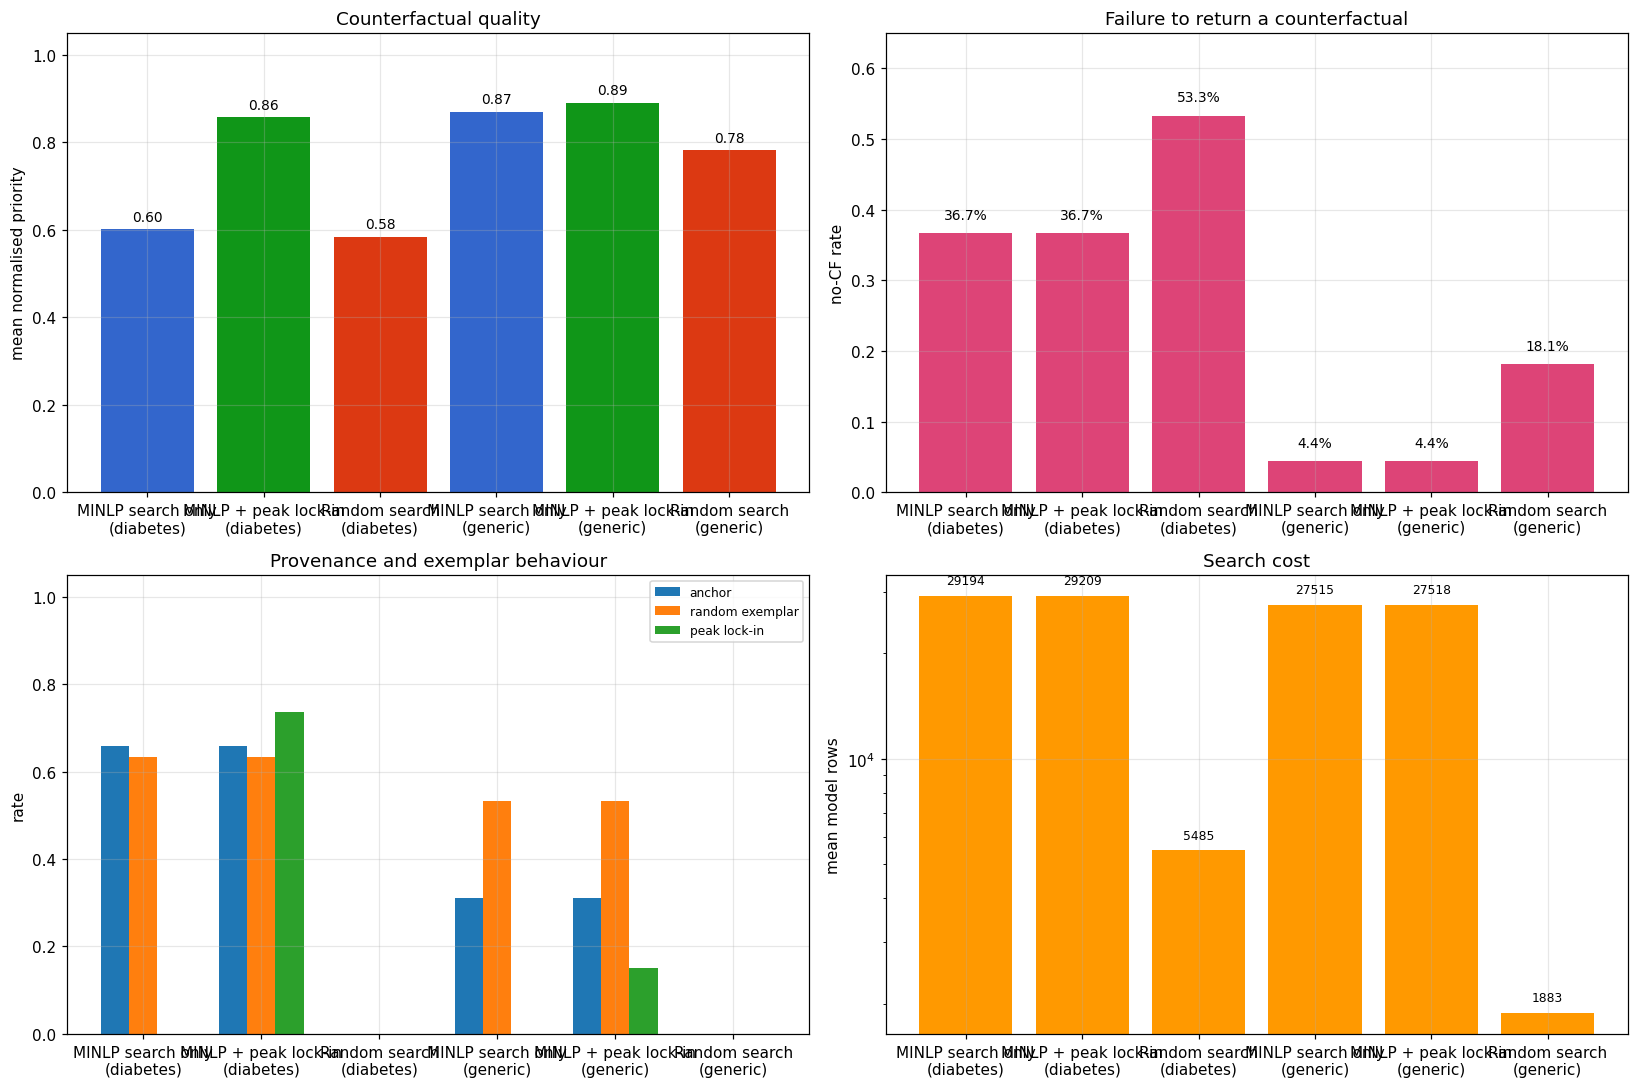

#### Interactive diagnosis browser

**Arm-level metric explorer**

Output()

**Dataset and priority-set explorer**

Output()

...

Output()

#### Warm-start fidelity and target-band mismatch

arm,median warm-start gap,warm-start gap > epsilon,validity rate,no-CF rate
MINLP search only (diabetes),0.158,89.5%,100.0%,36.7%
MINLP + peak lock-in (diabetes),0.158,89.5%,100.0%,36.7%
Random search (diabetes),nan,nan%,100.0%,53.3%
MINLP search only (generic),0.025,43.8%,98.8%,4.4%
MINLP + peak lock-in (generic),0.025,43.8%,98.8%,4.4%
Random search (generic),nan,nan%,100.0%,18.1%


#### Direct comparison against the random-search baseline

arm,reference,paired cases,arm mean priority,baseline mean priority,mean delta,arm wins,baseline wins,Wilcoxon p,Cliff's delta,effect size,delta CI low,delta CI high
MINLP search only (diabetes),random_search_baseline,23,0.635,0.578,0.057,12,11,0.329,0.078,negligible,-0.064,0.178
MINLP + peak lock-in (diabetes),random_search_baseline,23,0.905,0.578,0.327,23,0,0.000,1.000,large,0.290,0.363


In [32]:
from IPython.display import HTML

import matplotlib.ticker as mtick



def _diag_html(obj, index=False):

    if isinstance(obj, pd.DataFrame):

        html = obj.to_html(index=index, escape=False)

    else:

        html = obj.hide(axis="index").to_html()

    return HTML(

        "<div style='overflow-x:auto; max-width:100%;'>"

        + html

        + "</div>"

    )



def _diagnosis_group_breakdown(df, arm_name):

    subset = df[df["arm"] == arm_name].copy()

    rows = []

    for (dataset, priority_set), sub in subset.groupby(["dataset", "priority_set"], dropna=False):

        produced = sub[sub["cf_prediction"].notna()]

        valid = produced[produced["validity"] == True]

        sources = produced["cf_source"].dropna().astype(str) if "cf_source" in produced.columns else pd.Series(dtype=str)

        exemplars = produced["exemplar_source"].dropna().astype(str) if "exemplar_source" in produced.columns else pd.Series(dtype=str)

        rows.append({

            "dataset": dataset,

            "priority_set": priority_set,

            "n_rows": len(sub),

            "no_cf_rate": 1.0 - (len(produced) / len(sub) if len(sub) else 0.0),

            "validity_rate_among_produced": (len(valid) / len(produced)) if len(produced) else np.nan,

            "mean_priority_score_normalised": valid["priority_score_normalised"].mean() if len(valid) else np.nan,

            "mean_abs_pred_error": valid["abs_pred_error"].mean() if len(valid) else np.nan,

            "mean_model_rows": sub["model_rows"].mean() if "model_rows" in sub.columns else np.nan,

            "anchor_rate": sources.str.startswith("anchor").mean() if len(sources) else np.nan,

            "peak_lock_in_rate": sources.str.contains("peak_lock_in").mean() if len(sources) else np.nan,

            "exemplar_random_rate": (exemplars == "random_in_range").mean() if len(exemplars) else np.nan,

        })

    return pd.DataFrame(rows).sort_values(["dataset", "priority_set"]).reset_index(drop=True)



def _format_diag_table(df, percent_cols=None, float_cols=None, int_cols=None):

    percent_cols = percent_cols or []

    float_cols = float_cols or []

    int_cols = int_cols or []

    fmt = {}

    for col in percent_cols:

        if col in df.columns:

            fmt[col] = "{:.1%}"

    for col in float_cols:

        if col in df.columns:

            fmt[col] = "{:.3f}"

    for col in int_cols:

        if col in df.columns:

            fmt[col] = "{:.0f}"

    return df.style.format(fmt)



diagnosis_root = RESULTS_ROOT / "method_diagnosis"

diagnosis_analysis_dir = diagnosis_root / "analysis"

diagnosis_summary_df = pd.read_csv(diagnosis_analysis_dir / "summary.csv")

diagnosis_metrics_df = pd.read_csv(diagnosis_analysis_dir / "diagnostics.csv")

diagnosis_paired_df = pd.read_csv(diagnosis_analysis_dir / "paired.csv") if (diagnosis_analysis_dir / "paired.csv").exists() else pd.DataFrame()

diagnosis_cf_df = RunRegistry("method_diagnosis").load_counterfactuals(run_ids=current_run_ids("method_diagnosis"))



arm_order = [

    "minlp_search_only",

    "minlp_with_peak_lock_in",

    "random_search_baseline",

    "minlp_search_only_generic",

    "minlp_with_peak_lock_in_generic",

    "random_search_baseline_generic",

]

arm_labels = {

    "minlp_search_only": "MINLP search only\n(diabetes)",

    "minlp_with_peak_lock_in": "MINLP + peak lock-in\n(diabetes)",

    "random_search_baseline": "Random search\n(diabetes)",

    "minlp_search_only_generic": "MINLP search only\n(generic)",

    "minlp_with_peak_lock_in_generic": "MINLP + peak lock-in\n(generic)",

    "random_search_baseline_generic": "Random search\n(generic)",

}



summary = diagnosis_summary_df.copy()

summary = summary.merge(diagnosis_metrics_df, on="arm", how="left")

summary = summary.set_index("arm")

available_arms = [arm for arm in arm_order if arm in summary.index]

summary = summary.loc[available_arms].reset_index()

summary["label"] = summary["arm"].map(arm_labels)

summary["regime"] = np.where(summary["arm"].str.contains("generic"), "generic controlled regime", "diabetes stress case")



overview = summary[[

    "label",

    "regime",

    "n_samples",

    "n_cfs_produced",

    "validity_rate",

    "mean_priority_score_normalised",

    "no_cf_rate",

    "anchor_rate",

    "peak_lock_in_rate",

    "exemplar_random_rate",

    "median_warm_start_gap",

    "warm_start_gap_over_eps_rate",

    "mean_model_rows",

    "mean_time_seconds",

    "mean_l1",

]].copy()

overview.columns = [

    "arm",

    "regime",

    "study rows",

    "cfs produced",

    "validity rate",

    "normalised priority",

    "no-CF rate",

    "anchor rate",

    "peak-lock-in provenance",

    "random exemplar rate",

    "median warm-start gap",

    "warm-start gap > epsilon",

    "mean model rows",

    "mean time (s)",

    "mean l1",

]



breakdown_frames = []

for arm_name in ["minlp_search_only", "minlp_with_peak_lock_in", "minlp_search_only_generic", "minlp_with_peak_lock_in_generic"]:

    frame = _diagnosis_group_breakdown(diagnosis_cf_df, arm_name)

    if frame.empty:

        continue

    frame.insert(0, "arm", arm_name)

    frame.insert(1, "arm_label", arm_labels[arm_name].replace("\n", " "))

    frame.insert(2, "regime", "generic controlled regime" if "generic" in arm_name else "diabetes stress case")

    breakdown_frames.append(frame)

breakdown_df = pd.concat(breakdown_frames, ignore_index=True) if breakdown_frames else pd.DataFrame()



pct_cols = [

    "validity rate",

    "normalised priority",

    "no-CF rate",

    "anchor rate",

    "peak-lock-in provenance",

    "random exemplar rate",

    "warm-start gap > epsilon",

]



display(Markdown("### Diagnosis results"))

display(Markdown(

    "The diagnosis section now combines a fixed high-level summary with an interactive browser. "

    "Use the widgets below to choose which diagnosis metric to inspect, which regime or arm to focus on, and whether to look at arm-level summaries, dataset-priority breakdowns, or raw counterfactual rows."

))



display(Markdown("#### Arm-level overview"))

display(_diag_html(_format_diag_table(

    overview,

    percent_cols=pct_cols,

    float_cols=["median warm-start gap", "mean time (s)", "mean l1"],

    int_cols=["mean model rows"],

)))



fig, axes = plt.subplots(2, 2, figsize=(15, 10))

x = np.arange(len(summary))

labels = summary["label"]

colours = ["#3366cc", "#109618", "#dc3912", "#3366cc", "#109618", "#dc3912"]



axes[0, 0].bar(x, summary["mean_priority_score_normalised"], color=colours)

axes[0, 0].set_title("Counterfactual quality")

axes[0, 0].set_ylabel("mean normalised priority")

axes[0, 0].set_ylim(0, 1.05)

for xi, yi in zip(x, summary["mean_priority_score_normalised"]):

    axes[0, 0].text(xi, yi + 0.02, f"{yi:.2f}", ha="center", fontsize=9)



axes[0, 1].bar(x, summary["no_cf_rate"], color="#dd4477")

axes[0, 1].set_title("Failure to return a counterfactual")

axes[0, 1].set_ylabel("no-CF rate")

axes[0, 1].set_ylim(0, 0.65)

for xi, yi in zip(x, summary["no_cf_rate"]):

    axes[0, 1].text(xi, yi + 0.02, f"{yi:.1%}", ha="center", fontsize=9)



prov_cols = ["anchor_rate", "exemplar_random_rate", "peak_lock_in_rate"]

prov_labels = ["anchor", "random exemplar", "peak lock-in"]

width = 0.24

for idx, (col, label) in enumerate(zip(prov_cols, prov_labels)):

    axes[1, 0].bar(x + (idx - 1) * width, summary[col].fillna(0.0), width=width, label=label)

axes[1, 0].set_title("Provenance and exemplar behaviour")

axes[1, 0].set_ylabel("rate")

axes[1, 0].set_ylim(0, 1.05)

axes[1, 0].legend(loc="upper right", fontsize=8)



axes[1, 1].bar(x, summary["mean_model_rows"], color="#ff9900")

axes[1, 1].set_title("Search cost")

axes[1, 1].set_ylabel("mean model rows")

axes[1, 1].set_yscale("log")

for xi, yi in zip(x, summary["mean_model_rows"]):

    axes[1, 1].text(xi, yi * 1.08, f"{yi:.0f}", ha="center", fontsize=8)



for ax in axes.ravel():

    ax.set_xticks(x)

    ax.set_xticklabels(labels, rotation=0)



plt.tight_layout()

plt.show()



display(Markdown("#### Interactive diagnosis browser"))



summary_metric_options = {

    "Normalised priority": "mean_priority_score_normalised",

    "Validity rate": "validity_rate",

    "No-CF rate": "no_cf_rate",

    "Anchor rate": "anchor_rate",

    "Peak-lock-in provenance": "peak_lock_in_rate",

    "Random exemplar rate": "exemplar_random_rate",

    "Median warm-start gap": "median_warm_start_gap",

    "Warm-start gap > epsilon": "warm_start_gap_over_eps_rate",

    "Mean model rows": "mean_model_rows",

    "Mean time (s)": "mean_time_seconds",

    "Mean l1": "mean_l1",

}

breakdown_metric_options = {

    "Normalised priority": "mean_priority_score_normalised",

    "Validity among produced": "validity_rate_among_produced",

    "No-CF rate": "no_cf_rate",

    "Anchor rate": "anchor_rate",

    "Peak-lock-in provenance": "peak_lock_in_rate",

    "Random exemplar rate": "exemplar_random_rate",

    "Mean abs prediction error": "mean_abs_pred_error",

    "Mean model rows": "mean_model_rows",

}

percent_metric_columns = {

    "mean_priority_score_normalised",

    "validity_rate",

    "no_cf_rate",

    "anchor_rate",

    "peak_lock_in_rate",

    "exemplar_random_rate",

    "warm_start_gap_over_eps_rate",

    "validity_rate_among_produced",

}

log_metric_columns = {"mean_model_rows"}



overview_metric = widgets.Dropdown(

    options=list(summary_metric_options.keys()),

    value="Normalised priority",

    description="Metric:",

    layout=widgets.Layout(width="340px"),

    style={"description_width": "initial"},

)

overview_regime = widgets.Dropdown(

    options=[("All arms", "all"), ("Diabetes stress case", "diabetes stress case"), ("Generic controlled regime", "generic controlled regime")],

    value="all",

    description="Regime:",

    layout=widgets.Layout(width="340px"),

    style={"description_width": "initial"},

)

overview_sort = widgets.Checkbox(value=False, description="Sort descending")



breakdown_arm = widgets.Dropdown(

    options=[(arm_labels.get(arm, arm).replace("\n", " "), arm) for arm in breakdown_df["arm"].drop_duplicates()] if not breakdown_df.empty else [],

    description="Arm:",

    layout=widgets.Layout(width="360px"),

    style={"description_width": "initial"},

)

breakdown_metric = widgets.Dropdown(

    options=list(breakdown_metric_options.keys()),

    value="Normalised priority",

    description="Metric:",

    layout=widgets.Layout(width="360px"),

    style={"description_width": "initial"},

)

breakdown_view = widgets.Dropdown(

    options=[("Grouped bar plot", "bar"), ("Heatmap", "heatmap"), ("Table", "table")],

    value="bar",

    description="Display:",

    layout=widgets.Layout(width="280px"),

    style={"description_width": "initial"},

)



cf_arm = widgets.Dropdown(

    options=[("All arms", "all")] + [(arm_labels.get(arm, arm).replace("\n", " "), arm) for arm in sorted(diagnosis_cf_df["arm"].dropna().unique())],

    value="all",

    description="Arm:",

    layout=widgets.Layout(width="320px"),

    style={"description_width": "initial"},

)

cf_dataset = widgets.Dropdown(

    options=[("All datasets", "all")] + [(name, name) for name in sorted(diagnosis_cf_df["dataset"].dropna().unique())],

    value="all",

    description="Dataset:",

    layout=widgets.Layout(width="260px"),

    style={"description_width": "initial"},

)

cf_priority = widgets.Dropdown(

    options=[("All sets", "all")] + [(name, name) for name in sorted(diagnosis_cf_df["priority_set"].dropna().unique())],

    value="all",

    description="Priority set:",

    layout=widgets.Layout(width="260px"),

    style={"description_width": "initial"},

)

cf_rows = widgets.IntSlider(value=20, min=5, max=80, step=5, description="Rows:", layout=widgets.Layout(width="260px"), style={"description_width": "initial"})



overview_output = widgets.Output()

breakdown_output = widgets.Output()

cf_output = widgets.Output()



def _plot_summary_metric(metric_label, regime, sort_desc):

    metric_col = summary_metric_options[metric_label]

    frame = summary.copy()

    if regime != "all":

        frame = frame[frame["regime"] == regime].copy()

    if sort_desc:

        frame = frame.sort_values(metric_col, ascending=False, na_position="last")

    labels = frame["label"].tolist()

    values = frame[metric_col].tolist()



    with overview_output:

        clear_output(wait=True)

        if frame.empty:

            display(Markdown("No rows match the selected regime."))

            return

        fig, ax = plt.subplots(figsize=(11, 4.8))

        ax.bar(range(len(frame)), values, color="#3366cc")

        ax.set_xticks(range(len(frame)))

        ax.set_xticklabels(labels, rotation=0)

        ax.set_title(metric_label)

        if metric_col in percent_metric_columns:

            ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

            finite_vals = frame[metric_col].dropna()

            top = finite_vals.max() if not finite_vals.empty else 1.0

            ax.set_ylim(0, min(1.05, max(0.05, top * 1.18)))

        elif metric_col in log_metric_columns:

            ax.set_yscale("log")

        for idx, value in enumerate(values):

            if pd.isna(value):

                continue

            label = f"{value:.1%}" if metric_col in percent_metric_columns else f"{value:.3f}" if value < 1000 else f"{value:.0f}"

            if metric_col in log_metric_columns and value > 0:

                ypos = value * 1.03

            else:

                finite_vals = [v for v in values if not pd.isna(v)]

                pad = 0.02 if metric_col in percent_metric_columns else (max(finite_vals) * 0.02 if finite_vals else 0.02)

                ypos = value + pad

            ax.text(idx, ypos, label, ha="center", fontsize=8)

        plt.tight_layout()

        plt.show()



        table = frame[["label", "regime", metric_col, "validity_rate", "no_cf_rate", "mean_model_rows"]].copy()

        table.columns = ["arm", "regime", metric_label, "validity rate", "no-CF rate", "mean model rows"]

        display(_diag_html(_format_diag_table(

            table,

            percent_cols=[metric_label] if metric_col in percent_metric_columns else ["validity rate", "no-CF rate"],

            float_cols=[] if metric_col in percent_metric_columns else [metric_label],

            int_cols=["mean model rows"] if metric_col != "mean_model_rows" else [metric_label, "mean model rows"],

        )))



def _render_breakdown(arm_name, metric_label, display_mode):

    metric_col = breakdown_metric_options[metric_label]

    frame = breakdown_df[breakdown_df["arm"] == arm_name].copy()

    with breakdown_output:

        clear_output(wait=True)

        if frame.empty:

            display(Markdown("No breakdown rows are available for the selected arm."))

            return

        if display_mode == "table":

            table = frame[["dataset", "priority_set", metric_col, "no_cf_rate", "anchor_rate", "exemplar_random_rate", "mean_model_rows"]].copy()

            table.columns = ["dataset", "priority set", metric_label, "no-CF rate", "anchor rate", "random exemplar rate", "mean model rows"]

            display(_diag_html(_format_diag_table(

                table,

                percent_cols=[col for col in [metric_label, "no-CF rate", "anchor rate", "random exemplar rate"] if col in table.columns and (metric_col in percent_metric_columns or col != metric_label)],

                float_cols=[metric_label] if metric_col not in percent_metric_columns and metric_col != "mean_model_rows" else [],

                int_cols=["mean model rows"] if "mean model rows" in table.columns else [],

            )))

            return



        pivot = frame.pivot(index="dataset", columns="priority_set", values=metric_col)

        if display_mode == "heatmap":

            fig, ax = plt.subplots(figsize=(7.2, max(3.2, 1.3 * len(pivot.index))))

            image = ax.imshow(pivot.values, aspect="auto", cmap="Blues")

            ax.set_xticks(np.arange(len(pivot.columns)))

            ax.set_xticklabels(pivot.columns)

            ax.set_yticks(np.arange(len(pivot.index)))

            ax.set_yticklabels(pivot.index)

            ax.set_title(f"{metric_label} by dataset and priority set")

            for i in range(pivot.shape[0]):

                for j in range(pivot.shape[1]):

                    value = pivot.iloc[i, j]

                    if pd.isna(value):

                        continue

                    label = f"{value:.1%}" if metric_col in percent_metric_columns else f"{value:.2f}" if metric_col != "mean_model_rows" else f"{value:.0f}"

                    ax.text(j, i, label, ha="center", va="center", color="black", fontsize=8)

            fig.colorbar(image, ax=ax, shrink=0.85)

            plt.tight_layout()

            plt.show()

            return



        frame = frame.copy()

        frame["dataset_priority"] = frame["dataset"] + "\n" + frame["priority_set"]

        fig, ax = plt.subplots(figsize=(9.5, 4.8))

        ax.bar(frame["dataset_priority"], frame[metric_col], color="#109618")

        ax.set_title(f"{metric_label} for {arm_labels.get(arm_name, arm_name).replace(chr(10), ' ')}")

        if metric_col in percent_metric_columns:

            ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

            ax.set_ylim(0, min(1.05, max(0.05, float(frame[metric_col].max()) * 1.18)))

        elif metric_col in log_metric_columns:

            ax.set_yscale("log")

        plt.xticks(rotation=0)

        plt.tight_layout()

        plt.show()



def _render_cf_table(arm_name, dataset_name, priority_set, n_rows):

    frame = diagnosis_cf_df.copy()

    if arm_name != "all":

        frame = frame[frame["arm"] == arm_name]

    if dataset_name != "all":

        frame = frame[frame["dataset"] == dataset_name]

    if priority_set != "all":

        frame = frame[frame["priority_set"] == priority_set]

    preferred_cols = [

        "arm", "dataset", "priority_set", "sample_id", "seed", "validity",

        "priority_score_normalised", "abs_pred_error", "model_rows", "time_seconds",

        "cf_source", "exemplar_source", "cf_prediction", "target_value",

    ]

    cols = [col for col in preferred_cols if col in frame.columns]

    frame = frame[cols].copy().head(int(n_rows))

    with cf_output:

        clear_output(wait=True)

        if frame.empty:

            display(Markdown("No counterfactual rows match the selected filters."))

            return

        rename_map = {

            "priority_score_normalised": "normalised priority",

            "abs_pred_error": "abs prediction error",

            "model_rows": "model rows",

            "time_seconds": "time (s)",

            "cf_source": "CF source",

            "exemplar_source": "exemplar source",

            "cf_prediction": "CF prediction",

            "target_value": "target",

        }

        frame = frame.rename(columns=rename_map)

        display(_diag_html(_format_diag_table(

            frame,

            percent_cols=[col for col in ["validity", "normalised priority"] if col in frame.columns],

            float_cols=[col for col in ["abs prediction error", "time (s)", "CF prediction", "target"] if col in frame.columns],

            int_cols=[col for col in ["model rows", "sample_id", "seed"] if col in frame.columns],

        )))



overview_controls = widgets.HBox([overview_metric, overview_regime, overview_sort])

breakdown_controls = widgets.HBox([breakdown_arm, breakdown_metric, breakdown_view])

cf_controls = widgets.HBox([cf_arm, cf_dataset, cf_priority, cf_rows])



display(Markdown("**Arm-level metric explorer**"))

display(overview_controls)

display(overview_output)



display(Markdown("**Dataset and priority-set explorer**"))

display(breakdown_controls)

display(breakdown_output)



display(Markdown("**Raw counterfactual row browser**"))

display(cf_controls)

display(cf_output)



_diagnosis_overview_binding = widgets.interactive_output(

    _plot_summary_metric,

    {"metric_label": overview_metric, "regime": overview_regime, "sort_desc": overview_sort},

)

_diagnosis_breakdown_binding = widgets.interactive_output(

    _render_breakdown,

    {"arm_name": breakdown_arm, "metric_label": breakdown_metric, "display_mode": breakdown_view},

)

_diagnosis_cf_binding = widgets.interactive_output(

    _render_cf_table,

    {"arm_name": cf_arm, "dataset_name": cf_dataset, "priority_set": cf_priority, "n_rows": cf_rows},

)



_plot_summary_metric(overview_metric.value, overview_regime.value, overview_sort.value)

if breakdown_arm.options:

    _render_breakdown(breakdown_arm.value, breakdown_metric.value, breakdown_view.value)

_render_cf_table(cf_arm.value, cf_dataset.value, cf_priority.value, cf_rows.value)



display(Markdown("#### Warm-start fidelity and target-band mismatch"))

warm_start_view = summary[["label", "median_warm_start_gap", "warm_start_gap_over_eps_rate", "validity_rate", "no_cf_rate"]].copy()

warm_start_view.columns = ["arm", "median warm-start gap", "warm-start gap > epsilon", "validity rate", "no-CF rate"]

display(_diag_html(_format_diag_table(

    warm_start_view,

    percent_cols=["warm-start gap > epsilon", "validity rate", "no-CF rate"],

    float_cols=["median warm-start gap"],

)))



if not diagnosis_paired_df.empty:

    display(Markdown("#### Direct comparison against the random-search baseline"))

    paired_view = diagnosis_paired_df.copy()

    paired_view["arm"] = paired_view["arm"].map(arm_labels).fillna(paired_view["arm"])

    paired_view = paired_view[[

        "arm",

        "reference",

        "n_pairs",

        "mean_a",

        "mean_b",

        "mean_delta",

        "wins_a",

        "wins_b",

        "wilcoxon_p",

        "cliffs_delta",

        "cliffs_magnitude",

        "delta_ci_low",

        "delta_ci_high",

    ]]

    paired_view.columns = [

        "arm",

        "reference",

        "paired cases",

        "arm mean priority",

        "baseline mean priority",

        "mean delta",

        "arm wins",

        "baseline wins",

        "Wilcoxon p",

        "Cliff's delta",

        "effect size",

        "delta CI low",

        "delta CI high",

    ]

    display(_diag_html(_format_diag_table(

        paired_view,

        float_cols=["arm mean priority", "baseline mean priority", "mean delta", "Cliff's delta", "delta CI low", "delta CI high", "Wilcoxon p"],

        int_cols=["paired cases", "arm wins", "baseline wins"],

    )))


### Interpretation



The diagnosis results separate into two clearly different regimes.



In the generic controlled-priority regime, the MINLP pipeline is mostly functional. Both MINLP arms return a counterfactual in about 95.6% of cases, and about 98.8% of returned counterfactuals are valid. Peak lock-in improves the mean normalised priority from about 0.871 to 0.891 without materially changing failure rate or search cost, so in this regime Stage 7 is a genuine quality-improvement step rather than a rescue mechanism.



In the diabetes stress case, the method is much more fragile. Both MINLP arms fail to return any counterfactual in 36.7% of cases, about 65.8% of returned answers come directly from the anchor, about 63.3% of exemplars are obtained by random in-range sampling rather than by finding a suitable dataset row, and the median warm-start gap is about 0.158 with roughly 89.5% of warm starts already outside the target tolerance band. That pattern matches the method description above: the difficulty is not only the final optimiser, but the whole pipeline from exemplar availability through surrogate fidelity.



The comparison with random search is also regime-dependent. In the generic regime, MINLP with peak lock-in achieves much better priority quality than random search, about 0.891 versus 0.782, while also failing less often, about 4.4% versus 18.1%, but it does so at far higher model-evaluation cost. In the diabetes regime, plain MINLP search-only is only marginally better than random search in paired comparison, whereas adding peak lock-in produces a much larger gain, with a mean paired priority improvement of about 0.327 and a large effect size. So the diagnosis evidence suggests that, on hard priority geometries, much of the method's final advantage comes from post-processing after the main surrogate-guided loop rather than from the core search alone.



Overall, the diagnosis stage supports three claims that matter for the later studies. First, feasibility geometry is a dominant driver of behaviour: the generic strictness-controlled regime is tractable, while diabetes remains pathological. Second, anchor dependence and warm-start mismatch are real failure modes of the current MINLP implementation, not only edge cases. Third, peak lock-in is useful in both regimes, but it is especially important in the hard regime because it contributes a substantial share of the final quality gain.

### 5. Study I

Study I focuses on hyperparameter sensitivity, the cost of pushing the method harder, and a final verification of the tuned configuration on the diabetes stress case.

The section below starts with a fixed overview and then exposes widget-driven controls so the sweep family, dataset split, metric, and raw rows can be inspected directly.

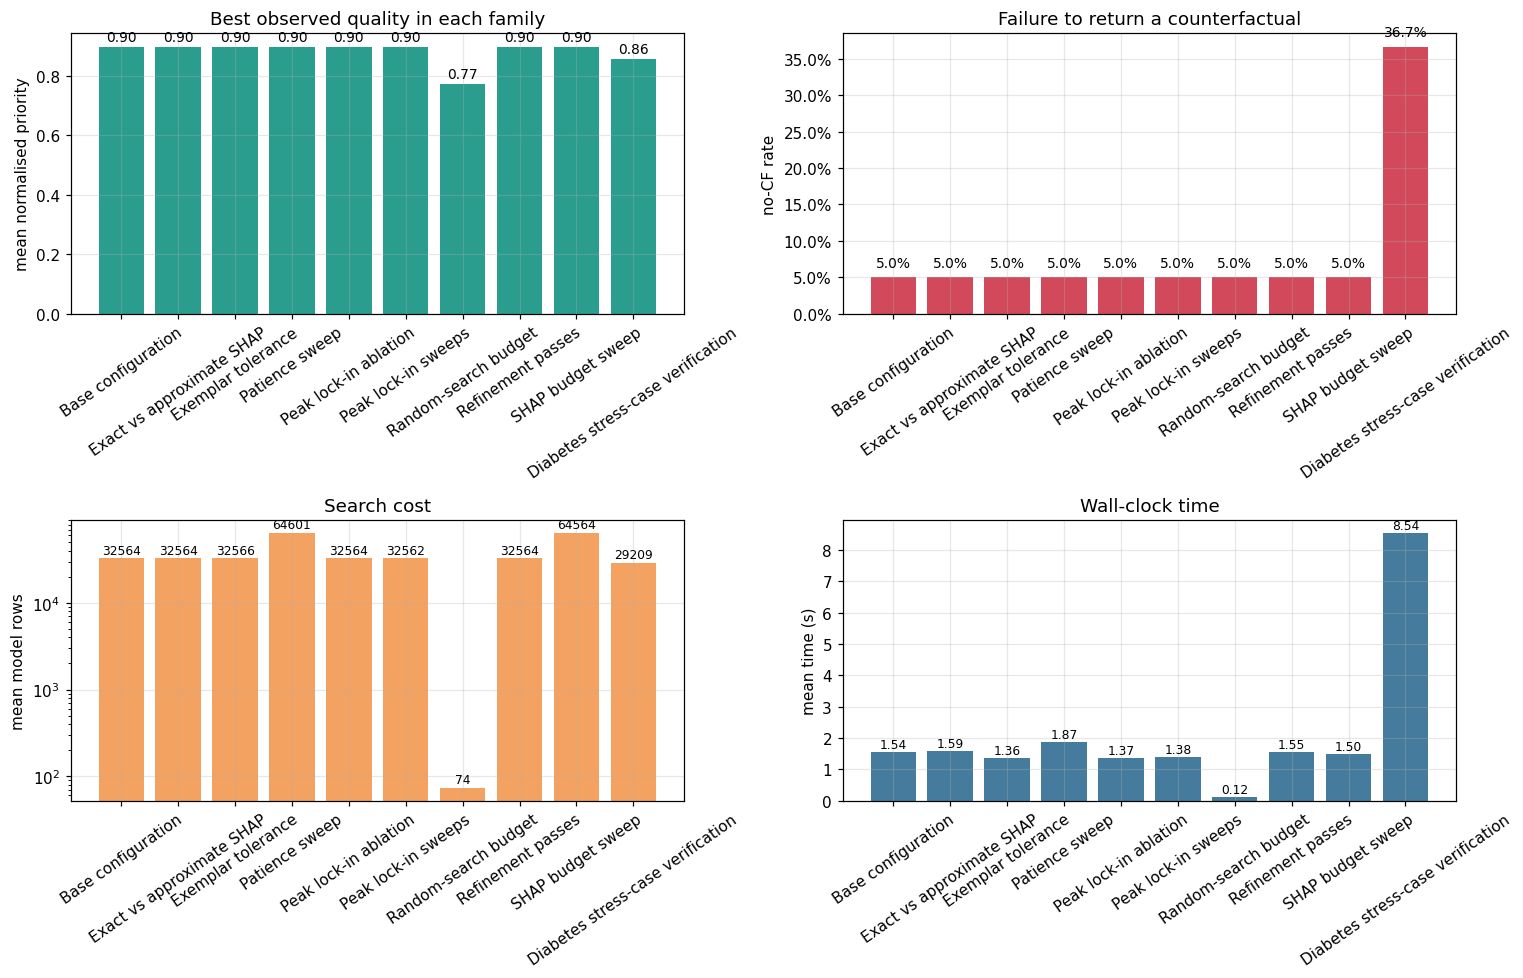

#### Family-level overview

family,study rows,cfs produced,validity rate,mean priority,normalised priority,no-CF rate,anchor rate,random exemplar rate,peak-lock-in provenance,mean model rows,mean time (s),mean l1
Base configuration,60,57,1.000000,5.834409,0.895534,0.050000,0.087719,0.800000,0.263158,32563.783333,1.537629,2.225573
Peak lock-in sweeps,60,171,1.000000,5.834409,0.895534,0.050000,0.087719,0.800000,0.263158,32563.305556,1.365367,2.225573
Patience sweep,60,228,1.000000,5.823410,0.893922,0.050000,0.131579,0.800000,0.271930,53590.108333,1.699823,2.283398
SHAP budget sweep,60,285,1.000000,5.816595,0.892990,0.050000,0.098246,0.800000,0.245614,50163.473333,1.542619,2.288838
Refinement passes,60,285,0.968421,5.823108,0.891760,0.050000,0.235088,0.800000,0.382456,25478.496667,1.351432,2.337360
Exemplar tolerance,60,231,0.935065,5.782999,0.890108,0.037500,0.069264,0.562500,0.229437,32936.537500,1.222847,2.155361
Exact vs approximate SHAP,60,114,1.000000,5.794960,0.889899,0.050000,0.096491,0.800000,0.254386,41844.158333,1.552061,2.268813
Peak lock-in ablation,60,114,1.000000,5.734609,0.881275,0.050000,0.087719,0.800000,0.131579,32561.150000,1.341425,2.385284
Diabetes stress-case verification,60,38,1.000000,5.252268,0.857641,0.366667,0.657895,0.633333,0.736842,29209.283333,8.537365,11.728977
Random-search budget,60,171,1.000000,4.995969,0.769696,0.050000,nan,nan,nan,290.200000,0.442400,3.404629


#### Best observed setting in each family

family,best cell,normalised priority,no-CF rate,mean model rows,mean time (s),mean l1
Base configuration,base,0.896604,0.050000,32563.783333,1.537629,2.199586
Exact vs approximate SHAP,shap_approx=True,0.896604,0.050000,32563.783333,1.594718,2.199586
Exemplar tolerance,target_exemplar_epsilon=0.05,0.897275,0.050000,32565.516667,1.355903,2.218413
Patience sweep,patience=10,0.896410,0.050000,64601.350000,1.874091,2.253513
Peak lock-in ablation,peak_lock_in=True,0.896604,0.050000,32563.783333,1.365680,2.199586
Peak lock-in sweeps,peak_lock_in_max_sweeps=1,0.896604,0.050000,32562.350000,1.379617,2.199586
Random-search budget,max_iterations=1000,0.772579,0.050000,73.533333,0.115790,3.378157
Refinement passes,max_iterations=10,0.896604,0.050000,32563.783333,1.554446,2.199586
SHAP budget sweep,shap_num_samples=400,0.898395,0.050000,64563.883333,1.498400,2.230446
Diabetes stress-case verification,verify_on_stress_case,0.857844,0.366667,29209.283333,8.537365,11.832363


#### Direct comparison against the base configuration

...

Output()

**Raw counterfactual row browser**

Output()

#### Interpretation

- The fixed summary shows that the base configuration already sits close to the top of the tuning curves, so most Study I sweeps are about cost control rather than unlocking a qualitatively different regime.
- SHAP samples can rise from 50 to 800 with only a 0.7% spread in mean normalised priority.
- The one-pass setting reaches 88.9% normalised priority versus 89.7% for the base configuration, while cutting model rows by about 88.5%.
- Random search never matches the base quality here: its best observed mean normalised priority is 77.3%, still below the MINLP base at 89.7%.
- The diabetes verification cell stays usable but harder: mean normalised priority is 85.8% with a mean no-CF rate of 36.7%.
- The widgets matter here because the curves are not uniform across datasets: `auto_mpg`, `carseats`, and the diabetes verification cells respond differently, so the family-average view is only the entry point, not the full story.

In [ ]:
from IPython.display import HTML
from matplotlib.ticker import PercentFormatter
from explainit.experiments.paper import analyse_study as paper_analyse

study1_root = RESULTS_ROOT / "study1_hyperparams"
study1_analysis_dir = study1_root / "analysis"
study1_analysis_dir.mkdir(parents=True, exist_ok=True)

study1_index = pd.read_csv(study1_root / "index.csv")
study1_cf = study("study1_hyperparams").copy()

study1_arm_summary = paper_analyse.summarise(study1_cf, "arm", "priority_score_normalised")
study1_arm_diag = paper_analyse.diagnostics(study1_cf, "arm")
study1_best_arm = stats.best_per_sample(
    study1_cf, value_col="priority_score_normalised", by="arm")
study1_arm_paired = paper_analyse.paired_table(
    study1_best_arm, "arm", "base", "priority_score_normalised", seed=0)

study1_arm_summary.to_csv(study1_analysis_dir / "summary.csv", index=False)
study1_arm_diag.to_csv(study1_analysis_dir / "diagnostics.csv", index=False)
study1_arm_paired.to_csv(study1_analysis_dir / "paired.csv", index=False)


def _study1_html(obj, index=False):
    if isinstance(obj, pd.io.formats.style.Styler):
        html = obj.to_html()
    else:
        html = obj.to_html(index=index)
    return HTML(f"<div style='overflow-x:auto; max-width:100%;'>{html}</div>")


def _study1_parse_cell_label(cell_label):
    text = str(cell_label)
    if text == "base":
        return pd.Series({
            "param_name": "base",
            "param_value": "base",
            "param_numeric": 0.0,
            "param_display": "base",
        })
    if "=" in text:
        name, value = text.split("=", 1)
    else:
        name, value = "setting", text
    value_lower = value.lower()
    if value_lower == "true":
        numeric = 1.0
        display_value = "on"
    elif value_lower == "false":
        numeric = 0.0
        display_value = "off"
    else:
        try:
            numeric = float(value)
        except ValueError:
            numeric = np.nan
        display_value = value
    return pd.Series({
        "param_name": name,
        "param_value": value,
        "param_numeric": numeric,
        "param_display": display_value,
    })


def _study1_group_metrics(df, group_cols):
    rows = []
    for keys, sub in df.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        produced = sub[sub["cf_prediction"].notna()]
        valid = produced[produced["validity"] == True]
        row.update({
            "n_rows": len(sub),
            "n_produced": len(produced),
            "n_valid": len(valid),
            "validity_rate": (len(valid) / len(produced)) if len(produced) else np.nan,
            "mean_priority_score": valid["priority_score"].mean() if len(valid) else np.nan,
            "mean_priority_score_normalised": (
                valid["priority_score_normalised"].mean() if len(valid) else np.nan),
            "no_cf_rate": 1.0 - (len(produced) / len(sub) if len(sub) else 0.0),
            "mean_model_rows": sub["model_rows"].mean(),
            "mean_time_seconds": sub["time_seconds"].mean(),
            "mean_l1": valid["l1"].mean() if len(valid) else np.nan,
        })
        rows.append(row)
    return pd.DataFrame(rows)


def _study1_format_table(df):
    percent_cols = [
        col for col in [
            "validity_rate", "mean_priority_score_normalised", "no_cf_rate",
            "anchor_fraction", "exemplar_random_rate", "peak_lock_in_rate",
            "delta_vs_base",
        ] if col in df.columns
    ]
    float_cols = [
        col for col in [
            "mean_priority_score", "mean_time_seconds", "mean_l1",
            "mean_model_rows", "median_warm_start_gap", "mean_delta",
            "wilcoxon_p", "cliffs_delta", "delta_ci_low", "delta_ci_high",
        ] if col in df.columns
    ]
    int_cols = [
        col for col in ["n_samples", "n_cfs_produced", "n_cfs_valid", "n_rows", "n_produced", "n_valid", "n_pairs"]
        if col in df.columns
    ]
    style = df.style
    if percent_cols:
        style = style.format({col: "{:.1%}" for col in percent_cols}, na_rep="-")
    if float_cols:
        style = style.format({col: "{:.3f}" for col in float_cols}, na_rep="-")
    if int_cols:
        style = style.format({col: "{:,.0f}" for col in int_cols}, na_rep="-")
    return style


study1_curve_df = _study1_group_metrics(
    study1_cf, ["arm", "cell", "dataset", "priority_set"])
study1_curve_df = pd.concat(
    [study1_curve_df, study1_curve_df["cell"].apply(_study1_parse_cell_label)], axis=1)

study1_cell_overview = (
    study1_curve_df
    .groupby(["arm", "cell", "param_name", "param_display", "param_numeric"], dropna=False, as_index=False)
    [[
        "validity_rate", "mean_priority_score", "mean_priority_score_normalised",
        "no_cf_rate", "mean_model_rows", "mean_time_seconds", "mean_l1",
    ]]
    .mean()
)

base_quality = float(
    study1_cell_overview.loc[study1_cell_overview["cell"] == "base", "mean_priority_score_normalised"].mean())
study1_cell_overview["delta_vs_base"] = (
    study1_cell_overview["mean_priority_score_normalised"] - base_quality)

study1_best_cell_by_arm = (
    study1_cell_overview
    .sort_values(["arm", "mean_priority_score_normalised", "no_cf_rate"], ascending=[True, False, True])
    .groupby("arm", as_index=False)
    .first()
)

study1_label_map = {
    "base": "Base configuration",
    "shap_budget": "SHAP budget sweep",
    "refinement_passes": "Refinement passes",
    "patience": "Patience sweep",
    "exemplar_tolerance": "Exemplar tolerance",
    "exact_vs_approx_shapley": "Exact vs approximate SHAP",
    "peak_lock_in_ablation": "Peak lock-in ablation",
    "peak_lock_in_sweeps": "Peak lock-in sweeps",
    "random_search_budget": "Random-search budget",
    "verify_on_stress_case": "Diabetes stress-case verification",
}

study1_arm_overview = (
    study1_arm_summary
    .merge(study1_arm_diag, on="arm", how="left")
    .assign(arm_label=lambda frame: frame["arm"].map(study1_label_map).fillna(frame["arm"]))
)
study1_best_cell_by_arm["arm_label"] = study1_best_cell_by_arm["arm"].map(study1_label_map).fillna(study1_best_cell_by_arm["arm"])

best_display = study1_best_cell_by_arm[[
    "arm_label", "cell", "mean_priority_score_normalised", "no_cf_rate",
    "mean_model_rows", "mean_time_seconds", "mean_l1",
]].rename(columns={
    "arm_label": "family",
    "cell": "best cell",
    "mean_priority_score_normalised": "normalised priority",
    "no_cf_rate": "no-CF rate",
    "mean_model_rows": "mean model rows",
    "mean_time_seconds": "mean time (s)",
    "mean_l1": "mean l1",
})

arm_display = study1_arm_overview[[
    "arm_label", "n_samples", "n_cfs_produced", "validity_rate",
    "mean_priority_score", "mean_priority_score_normalised", "no_cf_rate",
    "anchor_fraction", "exemplar_random_rate", "peak_lock_in_rate",
    "mean_model_rows", "mean_time_seconds", "mean_l1",
]].rename(columns={
    "arm_label": "family",
    "n_samples": "study rows",
    "n_cfs_produced": "cfs produced",
    "validity_rate": "validity rate",
    "mean_priority_score": "mean priority",
    "mean_priority_score_normalised": "normalised priority",
    "no_cf_rate": "no-CF rate",
    "anchor_fraction": "anchor rate",
    "exemplar_random_rate": "random exemplar rate",
    "peak_lock_in_rate": "peak-lock-in provenance",
    "mean_model_rows": "mean model rows",
    "mean_time_seconds": "mean time (s)",
    "mean_l1": "mean l1",
})

paired_display = study1_arm_paired[[
    "arm", "reference", "n_pairs", "mean_a", "mean_b", "mean_delta",
    "wins_a", "wins_b", "wilcoxon_p", "cliffs_delta", "cliffs_magnitude",
    "delta_ci_low", "delta_ci_high",
]].rename(columns={
    "arm": "family",
    "n_pairs": "paired cases",
    "mean_a": "family mean priority",
    "mean_b": "base mean priority",
    "mean_delta": "mean delta",
    "wins_a": "family wins",
    "wins_b": "base wins",
    "wilcoxon_p": "Wilcoxon p",
    "cliffs_delta": "Cliff's delta",
    "cliffs_magnitude": "effect size",
    "delta_ci_low": "delta CI low",
    "delta_ci_high": "delta CI high",
})
paired_display["family"] = paired_display["family"].map(study1_label_map).fillna(paired_display["family"])

verify_display = study1_curve_df.loc[
    study1_curve_df["arm"] == "verify_on_stress_case",
    ["dataset", "priority_set", "mean_priority_score_normalised", "no_cf_rate", "mean_model_rows", "mean_time_seconds", "mean_l1"]
].rename(columns={
    "dataset": "dataset",
    "priority_set": "priority set",
    "mean_priority_score_normalised": "normalised priority",
    "no_cf_rate": "no-CF rate",
    "mean_model_rows": "mean model rows",
    "mean_time_seconds": "mean time (s)",
    "mean_l1": "mean l1",
})


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
overview = study1_best_cell_by_arm.copy()
labels = overview["arm_label"]

axes[0, 0].bar(labels, overview["mean_priority_score_normalised"], color="#2a9d8f")
axes[0, 0].set_title("Best observed quality in each family")
axes[0, 0].set_ylabel("mean normalised priority")
axes[0, 0].tick_params(axis="x", rotation=35)
for idx, value in enumerate(overview["mean_priority_score_normalised"]):
    axes[0, 0].text(idx, value + 0.01, f"{value:.2f}", ha="center", va="bottom", fontsize=9)

axes[0, 1].bar(labels, overview["no_cf_rate"], color="#d1495b")
axes[0, 1].set_title("Failure to return a counterfactual")
axes[0, 1].set_ylabel("no-CF rate")
axes[0, 1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0, 1].tick_params(axis="x", rotation=35)
for idx, value in enumerate(overview["no_cf_rate"]):
    axes[0, 1].text(idx, value + 0.01, f"{value:.1%}", ha="center", va="bottom", fontsize=9)

axes[1, 0].bar(labels, overview["mean_model_rows"], color="#f4a261")
axes[1, 0].set_title("Search cost")
axes[1, 0].set_ylabel("mean model rows")
axes[1, 0].set_yscale("log")
axes[1, 0].tick_params(axis="x", rotation=35)
for idx, value in enumerate(overview["mean_model_rows"]):
    axes[1, 0].text(idx, value * 1.05, f"{value:.0f}", ha="center", va="bottom", fontsize=8)

axes[1, 1].bar(labels, overview["mean_time_seconds"], color="#457b9d")
axes[1, 1].set_title("Wall-clock time")
axes[1, 1].set_ylabel("mean time (s)")
axes[1, 1].tick_params(axis="x", rotation=35)
for idx, value in enumerate(overview["mean_time_seconds"]):
    axes[1, 1].text(idx, value + 0.03, f"{value:.2f}", ha="center", va="bottom", fontsize=8)

plt.show()

shap_cells = study1_cell_overview.loc[study1_cell_overview["arm"] == "shap_budget"].sort_values("param_numeric")
refinement_cells = study1_cell_overview.loc[study1_cell_overview["arm"] == "refinement_passes"].sort_values("param_numeric")
random_cells = study1_cell_overview.loc[study1_cell_overview["arm"] == "random_search_budget"].sort_values("param_numeric")
verify_quality = verify_display["normalised priority"].mean()
verify_no_cf = verify_display["no-CF rate"].mean()

shap_tradeoff = (
    f"SHAP samples can rise from {int(shap_cells['param_numeric'].min())} to {int(shap_cells['param_numeric'].max())} "
    f"with only a {shap_cells['mean_priority_score_normalised'].max() - shap_cells['mean_priority_score_normalised'].min():.1%} "
    "spread in mean normalised priority."
)
refinement_tradeoff = (
    f"The one-pass setting reaches {refinement_cells.iloc[0]['mean_priority_score_normalised']:.1%} "
    f"normalised priority versus {base_quality:.1%} for the base configuration, "
    f"while cutting model rows by about {1 - refinement_cells.iloc[0]['mean_model_rows'] / study1_cell_overview.loc[study1_cell_overview['cell'] == 'base', 'mean_model_rows'].mean():.1%}."
)
random_gap = (
    f"Random search never matches the base quality here: its best observed mean normalised priority is "
    f"{random_cells['mean_priority_score_normalised'].max():.1%}, still below the MINLP base at {base_quality:.1%}."
)
stress_case = (
    f"The diabetes verification cell stays usable but harder: mean normalised priority is {verify_quality:.1%} "
    f"with a mean no-CF rate of {verify_no_cf:.1%}."
)


display(Markdown("#### Family-level overview"))
display(_study1_html(_study1_format_table(arm_display).hide(axis="index")))

display(Markdown("#### Best observed setting in each family"))
display(_study1_html(_study1_format_table(best_display).hide(axis="index")))

display(Markdown("#### Direct comparison against the base configuration"))
display(_study1_html(_study1_format_table(paired_display).hide(axis="index")))

display(Markdown("#### Diabetes stress-case verification"))
display(_study1_html(_study1_format_table(verify_display).hide(axis="index")))

display(Markdown("#### Interactive Study I browser"))

study1_metric_map = {
    "Normalised priority": "mean_priority_score_normalised",
    "Priority score": "mean_priority_score",
    "No-CF rate": "no_cf_rate",
    "Validity rate": "validity_rate",
    "Mean model rows": "mean_model_rows",
    "Mean time (s)": "mean_time_seconds",
    "Mean l1": "mean_l1",
    "Delta vs base": "delta_vs_base",
}

study1_family_dropdown = widgets.Dropdown(
    options=[(study1_label_map.get(arm, arm), arm) for arm in study1_cell_overview["arm"].drop_duplicates()],
    value="shap_budget",
    description="Family:",
    layout=widgets.Layout(width="360px"),
)
study1_metric_dropdown = widgets.Dropdown(
    options=list(study1_metric_map.keys()),
    value="Normalised priority",
    description="Metric:",
    layout=widgets.Layout(width="280px"),
)
study1_dataset_dropdown = widgets.Dropdown(
    options=[("All datasets", "all")] + [(name, name) for name in sorted(study1_curve_df["dataset"].dropna().unique())],
    value="all",
    description="Dataset:",
    layout=widgets.Layout(width="260px"),
)
study1_display_dropdown = widgets.Dropdown(
    options=["bar", "line", "table"],
    value="bar",
    description="Display:",
    layout=widgets.Layout(width="220px"),
)
study1_split_checkbox = widgets.Checkbox(value=True, description="split by priority set")
study1_sweep_output = widgets.Output()


def _study1_render_sweep(arm, metric_label, dataset, display_mode, split_priority):
    metric = study1_metric_map[metric_label]
    subset = study1_curve_df.loc[study1_curve_df["arm"] == arm].copy()
    if dataset != "all":
        subset = subset.loc[subset["dataset"] == dataset]
    group_cols = ["cell", "param_display", "param_numeric"]
    if split_priority:
        group_cols.append("priority_set")
    summary = (
        subset.groupby(group_cols, dropna=False, as_index=False)[metric]
        .mean()
        .sort_values(["param_numeric", "cell"], na_position="last")
    )
    with study1_sweep_output:
        clear_output(wait=True)
        if summary.empty:
            display(Markdown("No rows match the selected filters."))
            return
        if display_mode == "table":
            display(_study1_html(_study1_format_table(summary).hide(axis="index")))
            return
        fig, ax = plt.subplots(figsize=(9, 4.5))
        labels = summary["param_display"].astype(str)
        if split_priority and "priority_set" in summary.columns and summary["priority_set"].nunique() > 1:
            pivot = summary.pivot(index="param_display", columns="priority_set", values=metric)
            pivot = pivot.reindex(labels.drop_duplicates())
            if display_mode == "line":
                for priority_set in pivot.columns:
                    ax.plot(pivot.index.astype(str), pivot[priority_set], marker="o", label=str(priority_set))
            else:
                pivot.plot(kind="bar", ax=ax)
        else:
            values = summary[metric].to_numpy()
            if display_mode == "line":
                ax.plot(labels, values, marker="o", color="#2a9d8f")
            else:
                ax.bar(labels, values, color="#2a9d8f")
            for idx, value in enumerate(values):
                text = f"{value:.1%}" if "rate" in metric or "normalised" in metric or metric == "delta_vs_base" else f"{value:.2f}"
                ax.text(idx, value, text, ha="center", va="bottom", fontsize=8)
        ax.set_title(f"{study1_label_map.get(arm, arm)}: {metric_label}")
        ax.set_xlabel("cell")
        ax.set_ylabel(metric_label)
        if "rate" in metric or "normalised" in metric or metric == "delta_vs_base":
            ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.tick_params(axis="x", rotation=30)
        if split_priority and "priority_set" in summary.columns and summary["priority_set"].nunique() > 1:
            ax.legend(title="priority set")
        plt.show()


study1_sweep_controls = widgets.HBox([
    study1_family_dropdown,
    study1_metric_dropdown,
    study1_dataset_dropdown,
    study1_display_dropdown,
    study1_split_checkbox,
])
display(study1_sweep_controls)
study1_sweep_binding = widgets.interactive_output(
    _study1_render_sweep,
    {
        "arm": study1_family_dropdown,
        "metric_label": study1_metric_dropdown,
        "dataset": study1_dataset_dropdown,
        "display_mode": study1_display_dropdown,
        "split_priority": study1_split_checkbox,
    },
)
display(study1_sweep_output)


display(Markdown("**Seed-level run summary**"))
study1_run_arm = widgets.Dropdown(
    options=[("All families", "all")] + [(study1_label_map.get(arm, arm), arm) for arm in study1_index["arm"].drop_duplicates()],
    value="all",
    description="Family:",
    layout=widgets.Layout(width="360px"),
)
study1_run_dataset = widgets.Dropdown(
    options=[("All datasets", "all")] + [(name, name) for name in sorted(study1_index["dataset"].dropna().unique())],
    value="all",
    description="Dataset:",
    layout=widgets.Layout(width="260px"),
)
study1_run_cell = widgets.Dropdown(
    options=[("All cells", "all")] + [(name, name) for name in study1_index["cell"].drop_duplicates()],
    value="all",
    description="Cell:",
    layout=widgets.Layout(width="320px"),
)
study1_run_output = widgets.Output()


def _study1_render_runs(arm, dataset, cell):
    subset = study1_index.copy()
    if arm != "all":
        subset = subset.loc[subset["arm"] == arm]
    if dataset != "all":
        subset = subset.loc[subset["dataset"] == dataset]
    if cell != "all":
        subset = subset.loc[subset["cell"] == cell]
    subset = subset[[
        "arm", "cell", "dataset", "priority_set", "seed", "avg_priority_score_normalised",
        "n_cfs_valid", "avg_model_rows", "avg_time_seconds",
    ]].rename(columns={
        "arm": "family",
        "priority_set": "priority set",
        "avg_priority_score_normalised": "normalised priority",
        "n_cfs_valid": "valid cfs",
        "avg_model_rows": "mean model rows",
        "avg_time_seconds": "mean time (s)",
    })
    subset["family"] = subset["family"].map(study1_label_map).fillna(subset["family"])
    with study1_run_output:
        clear_output(wait=True)
        if subset.empty:
            display(Markdown("No runs match the selected filters."))
            return
        display(_study1_html(_study1_format_table(subset).hide(axis="index")))


study1_run_controls = widgets.HBox([study1_run_arm, study1_run_dataset, study1_run_cell])
display(study1_run_controls)
study1_run_binding = widgets.interactive_output(
    _study1_render_runs,
    {"arm": study1_run_arm, "dataset": study1_run_dataset, "cell": study1_run_cell},
)
display(study1_run_output)


display(Markdown("**Raw counterfactual row browser**"))
study1_cf_arm = widgets.Dropdown(
    options=[("All families", "all")] + [(study1_label_map.get(arm, arm), arm) for arm in study1_cf["arm"].drop_duplicates()],
    value="all",
    description="Family:",
    layout=widgets.Layout(width="360px"),
)
study1_cf_dataset = widgets.Dropdown(
    options=[("All datasets", "all")] + [(name, name) for name in sorted(study1_cf["dataset"].dropna().unique())],
    value="all",
    description="Dataset:",
    layout=widgets.Layout(width="260px"),
)
study1_cf_cell = widgets.Dropdown(
    options=[("All cells", "all")] + [(name, name) for name in study1_cf["cell"].drop_duplicates()],
    value="all",
    description="Cell:",
    layout=widgets.Layout(width="320px"),
)
study1_cf_limit = widgets.IntSlider(value=12, min=5, max=30, step=1, description="Rows:", layout=widgets.Layout(width="260px"))
study1_cf_output = widgets.Output()


def _study1_render_cf_rows(arm, dataset, cell, limit):
    subset = study1_cf.copy()
    if arm != "all":
        subset = subset.loc[subset["arm"] == arm]
    if dataset != "all":
        subset = subset.loc[subset["dataset"] == dataset]
    if cell != "all":
        subset = subset.loc[subset["cell"] == cell]
    columns = [
        "arm", "cell", "dataset", "priority_set", "sample_id", "seed", "validity",
        "priority_score_normalised", "l1", "cf_source", "exemplar_source", "stop_reason",
        "model_rows", "time_seconds",
    ]
    subset = subset[[col for col in columns if col in subset.columns]].head(limit).rename(columns={
        "arm": "family",
        "priority_set": "priority set",
        "priority_score_normalised": "normalised priority",
        "cf_source": "cf source",
        "exemplar_source": "exemplar source",
        "stop_reason": "stop reason",
        "model_rows": "model rows",
        "time_seconds": "time (s)",
    })
    subset["family"] = subset["family"].map(study1_label_map).fillna(subset["family"])
    with study1_cf_output:
        clear_output(wait=True)
        if subset.empty:
            display(Markdown("No counterfactual rows match the selected filters."))
            return
        display(_study1_html(_study1_format_table(subset).hide(axis="index")))


study1_cf_controls = widgets.HBox([study1_cf_arm, study1_cf_dataset, study1_cf_cell, study1_cf_limit])
display(study1_cf_controls)
study1_cf_binding = widgets.interactive_output(
    _study1_render_cf_rows,
    {"arm": study1_cf_arm, "dataset": study1_cf_dataset, "cell": study1_cf_cell, "limit": study1_cf_limit},
)
display(study1_cf_output)


display(Markdown("#### Interpretation"))
display(Markdown(
    "\n".join([
        "- The fixed summary shows that the base configuration already sits close to the top of the tuning curves, so most Study I sweeps are about cost control rather than unlocking a qualitatively different regime.",
        f"- {shap_tradeoff}",
        f"- {refinement_tradeoff}",
        f"- {random_gap}",
        f"- {stress_case}",
        "- The widgets matter here because the curves are not uniform across datasets: `auto_mpg`, `carseats`, and the diabetes verification cells respond differently, so the family-average view is only the entry point, not the full story.",
    ])))

### 6. Study II

Study II holds the method configuration fixed and changes the data or preference regime one factor at a time. The results below rebuild the paired factor analysis from the raw runs, including the strictness arm that is not encoded in the dataset name and therefore needs notebook-side handling.

The section starts with family-level summaries and then exposes detailed widgets for factor-level paired effects, run-level summaries, and raw counterfactual rows.

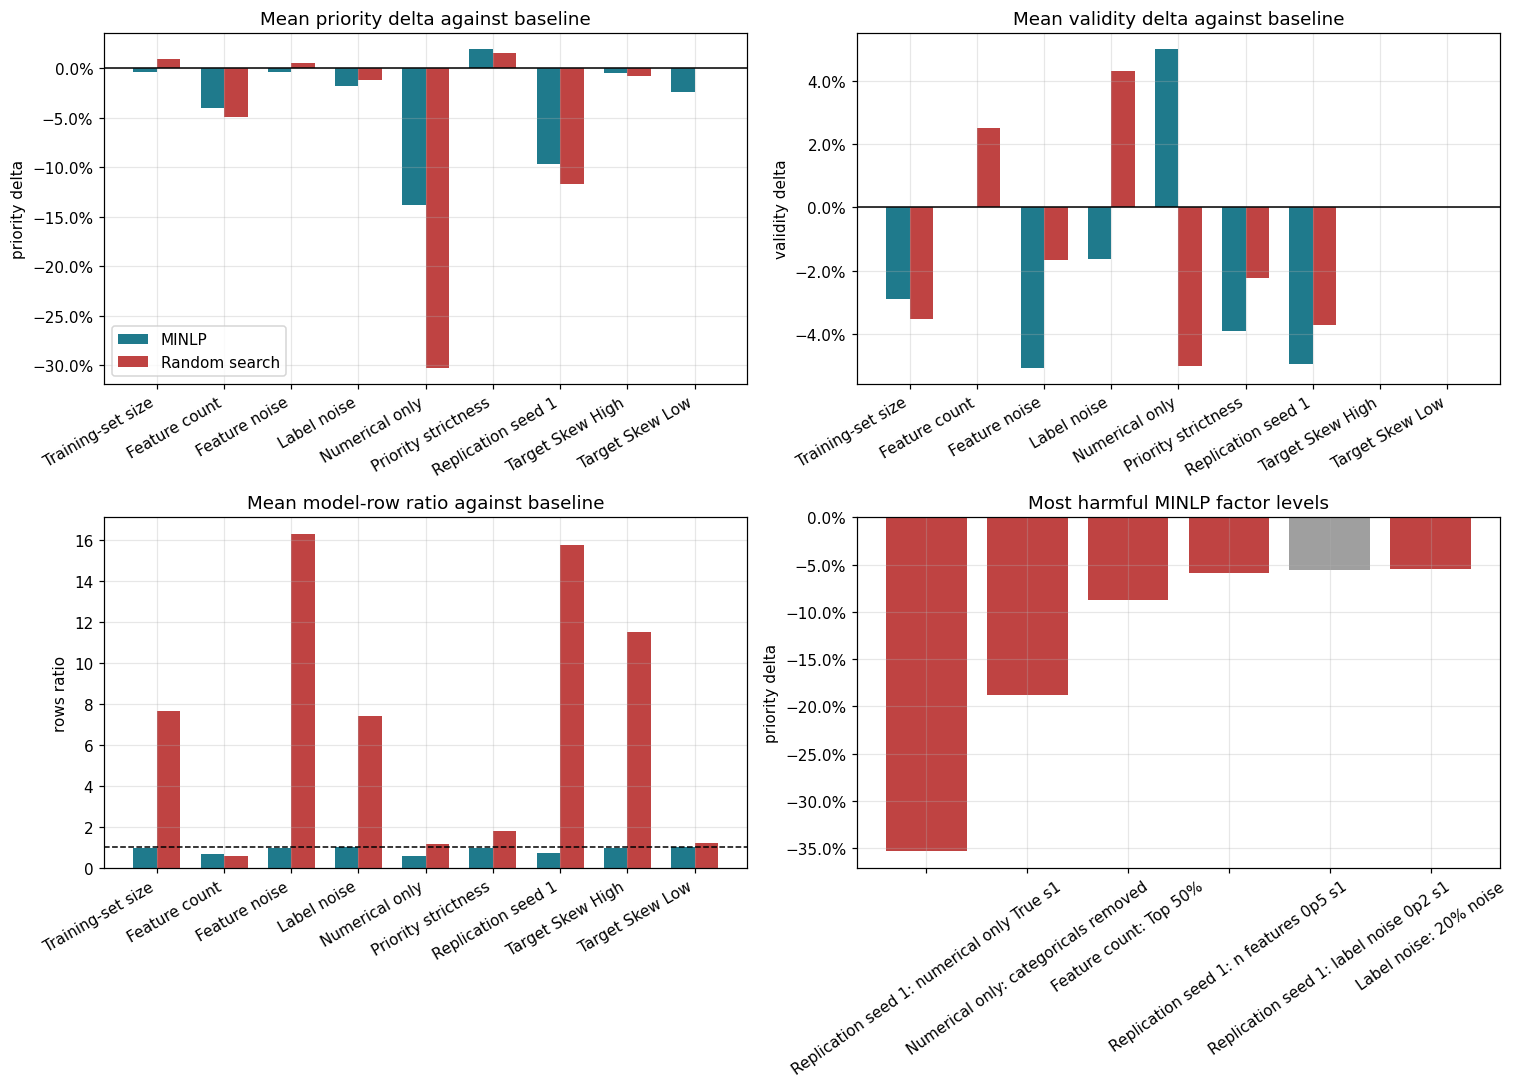

#### Family-level overview

factor family,levels,priority delta (MINLP),priority delta (random search),valid delta (MINLP),valid delta (random search),model rows ratio (MINLP),model rows ratio (random search),priority sig hits (MINLP),priority sig hits (random search)
Feature noise,3,-0.003227,0.005376,-0.050617,-0.016667,0.987141,16.275494,0,0
Label noise,3,-0.018029,-0.012141,-0.016204,0.043056,1.022519,7.424005,1,0
Feature count,2,-0.039757,-0.049162,0.000000,0.025000,0.658865,0.584841,1,2
Numerical only,1,-0.137735,-0.302320,0.050000,-0.050000,0.602680,1.155780,2,2
Replication seed 1,3,-0.096537,-0.117108,-0.049383,-0.037037,0.712097,15.759788,3,4
Priority strictness,2,0.019559,0.016014,-0.038889,-0.022222,0.984214,1.816313,3,4
Target Skew High,1,-0.005000,-0.007350,0.000000,0.000000,0.986699,11.495890,0,0
Target Skew Low,1,-0.024036,0.000863,0.000000,0.000000,1.005001,1.235554,1,0
Training-set size,3,-0.003123,0.009551,-0.029012,-0.035185,0.971204,7.629322,1,0


#### Most harmful MINLP factor levels

base dataset,factor family,level,prio delta,valid delta,model rows ratio,prio p,prio effect
carseats,Replication seed 1,numerical only True s1,-0.353482,0.100000,0.563,0.000,-1.000
carseats,Numerical only,categoricals removed,-0.187606,0.100000,0.630,0.000,-0.753
auto_mpg,Replication seed 1,numerical only True s1,-0.093913,0.000000,0.577,0.018,-0.388
auto_mpg,Numerical only,categoricals removed,-0.087863,0.000000,0.575,0.000,-0.350
carseats,Feature count,Top 50%,-0.087724,0.000000,0.508,0.000,-0.377
carseats,Replication seed 1,n features 0p5 s1,-0.059331,0.000000,0.508,0.016,-0.317
auto_mpg,Replication seed 1,label noise 0p2 s1,-0.055248,-0.074074,0.989,0.211,-0.180
carseats,Label noise,20% noise,-0.054374,0.125000,1.067,0.002,-0.583
carseats,Replication seed 1,label noise 0p2 s1,-0.044042,-0.100000,1.039,0.117,-0.364
carseats,Feature count,Top 75%,-0.035391,0.000000,0.827,0.091,-0.374


#### Where MINLP degrades less or more than the random-search control

...

Output()

**Raw counterfactual row browser**

Output()

#### Interpretation

- Study II is about paired deltas, not raw scores in isolation: every factor level is matched against the baseline on the same source cases, so the sign of each delta is directly interpretable as help or harm relative to the unmodified problem setting.
- The strongest priority hit for MINLP-Search is **Replication seed 1 / numerical only True s1 on carseats**, with a mean priority delta of -35.3% and Holm-corrected $p = 4.47e-08$.
- The strongest hit for the random-search control is **Numerical only / categoricals removed on carseats**, with a mean priority delta of -40.8%. When both methods deteriorate on the same factor, that points to a genuinely harder task; when only MINLP-Search deteriorates strongly, that points to method-specific brittleness.
- The steepest validity loss for MINLP-Search appears at **Label noise / 20% noise on auto_mpg**, where validity moves by -22.2%. That matters because a factor can look harmless on quality if it simply removes the hardest failed cases from the average unless validity is tracked separately.
- The cheapest MINLP regime relative to its own baseline is **Feature count / Top 50% on carseats**, with a model-row ratio of 0.51. Study II therefore distinguishes two different phenomena: some factors damage quality while also cutting search cost, whereas others damage quality and make the search harder at the same time.
- The strictness arm had to be rebuilt inside this notebook because the original factor-analysis script only decodes factors from dataset names. Strictness changes the `priority_set` on the same dataset, so it is scientifically part of Study II but structurally invisible to the old CSV unless the pairing logic is extended.
- The replication arm is especially useful as a robustness check: the worst replicated effect here is **numerical only True s1 on carseats**, with a mean priority delta of -37.5%. If a main-factor result and its `_s1` replica point in the same direction, the claim is much harder to dismiss as a construction-seed artefact.
- The widget views are necessary here because the family averages compress several qualitatively different cases together. `train_size`, `strictness`, and `target_skew` do not behave uniformly across `auto_mpg`, `carseats`, and `bike_sharing_hourly`, so the fixed summary should be treated as orientation rather than as the final reading.

In [ ]:
from IPython.display import HTML
from matplotlib.ticker import PercentFormatter
from scipy import stats as scipy_stats

study2_root = RESULTS_ROOT / "study2_factors"
study2_analysis_dir = study2_root / "analysis"
study2_analysis_dir.mkdir(parents=True, exist_ok=True)

study2_index = pd.read_csv(study2_root / "index.csv")
study2_cf = study("study2_factors").copy()


def _study2_html(obj, index=False):
    if isinstance(obj, pd.DataFrame):
        html = obj.to_html(index=index)
    else:
        html = obj.to_html()
    return HTML(f"<div style='overflow-x:auto; max-width:100%;'>{html}</div>")


def _study2_format_table(df):
    percent_cols = [
        col for col in [
            "prio delta", "valid delta", "variant validity", "baseline validity",
            "variant priority", "baseline priority", "rows ratio - 1",
            "mean priority delta", "worst priority delta", "mean validity delta",
            "worst validity delta", "priority delta (MINLP)", "priority delta (random search)",
            "delta gap (MINLP - RS)", "normalised priority", "mean validity rate",
            "no-CF rate", "validity", "priority delta vs baseline",
        ] if col in df.columns
    ]
    float_cols = [
        col for col in [
            "model rows ratio", "mean rows ratio", "mean rows delta", "worst rows delta",
            "prio p", "valid p", "rows p", "prio effect", "valid effect", "rows effect",
            "mean model rows", "mean time (s)", "mean l1", "rows delta", "priority p-value",
            "validity p-value", "rows p-value", "time (s)", "l1", "model rows",
        ] if col in df.columns
    ]
    int_cols = [
        col for col in [
            "paired rows", "priority sig hits", "validity sig hits", "rows sig hits",
            "levels", "seed", "valid cfs", "sample_id",
        ] if col in df.columns
    ]
    style = df.style
    if percent_cols:
        style = style.format({col: "{:.1%}" for col in percent_cols}, na_rep="-")
    if float_cols:
        style = style.format({col: "{:.3f}" for col in float_cols}, na_rep="-")
    if int_cols:
        style = style.format({col: "{:,.0f}" for col in int_cols}, na_rep="-")
    return style


def _study2_split_variant(row):
    arm = str(row["arm"])
    dataset = str(row["dataset"])
    method = str(row["method"])
    priority_set = str(row.get("priority_set", ""))
    baseline_arm = "baseline_rs" if method == "random_search" else "baseline"
    if arm in {"baseline", "baseline_rs"}:
        return pd.Series({
            "base_dataset": dataset,
            "factor": "baseline",
            "level": "base",
            "baseline_arm": baseline_arm,
        })
    if arm in {"strictness", "strictness_rs"}:
        return pd.Series({
            "base_dataset": dataset,
            "factor": "strictness",
            "level": priority_set,
            "baseline_arm": baseline_arm,
        })
    if "__" in dataset:
        base_dataset, rest = dataset.split("__", 1)
    else:
        base_dataset, rest = dataset, dataset
    if arm in {"replicate_seed1", "replicate_seed1_rs"}:
        factor = "replicate_seed1"
        level = rest
    else:
        factor, _, level = rest.rpartition("_")
        if not factor:
            factor = arm
            level = rest
    return pd.Series({
        "base_dataset": base_dataset,
        "factor": factor,
        "level": level,
        "baseline_arm": baseline_arm,
    })


def _study2_annotate(frame):
    frame = frame.copy()
    annotations = frame.apply(_study2_split_variant, axis=1)
    for column in annotations.columns:
        frame[column] = annotations[column]
    return frame


def _study2_paired(sub_variant, sub_base, value_col, seed=0, keys=None):
    keys = keys or [k for k in ["sample_id", "seed", "priority_set"] if k in sub_variant.columns and k in sub_base.columns]
    variant = sub_variant[keys + [value_col]].rename(columns={value_col: "value_variant"})
    base = sub_base[keys + [value_col]].rename(columns={value_col: "value_base"})
    merged = variant.merge(base, on=keys, how="inner").dropna(subset=["value_variant", "value_base"])
    if merged.empty:
        return {"n_pairs": 0}
    values_variant = merged["value_variant"].to_numpy(dtype=float)
    values_base = merged["value_base"].to_numpy(dtype=float)
    delta = values_variant - values_base
    better = int(np.sum(delta > 1e-9))
    worse = int(np.sum(delta < -1e-9))
    wilcoxon_p = np.nan
    if delta.size >= 3 and np.any(np.abs(delta) > 1e-9):
        try:
            wilcoxon_p = float(scipy_stats.wilcoxon(values_variant, values_base).pvalue)
        except ValueError:
            wilcoxon_p = np.nan
    sign_p = np.nan
    if better + worse:
        sign_p = float(scipy_stats.binomtest(better, better + worse, 0.5).pvalue)
    ci_low, ci_high = stats.bootstrap_ci(delta, seed=seed)
    return {
        "n_pairs": int(delta.size),
        "variant_mean": float(np.mean(values_variant)),
        "base_mean": float(np.mean(values_base)),
        "delta": float(np.mean(delta)),
        "worse": worse,
        "better": better,
        "wilcoxon_p": wilcoxon_p,
        "sign_test_p": sign_p,
        "cliffs_delta": stats.cliffs_delta(values_variant, values_base),
        "ci_low": ci_low,
        "ci_high": ci_high,
    }


def _study2_factor_table(df, *, method, seed=0):
    annotated = _study2_annotate(df)
    annotated = annotated.loc[annotated["method"] == method].copy()
    annotated["validity_num"] = annotated["validity"].astype(float)
    baseline = annotated.loc[annotated["factor"] == "baseline"].copy()
    rows = []
    for (base_dataset, factor, level), variant in (
        annotated.loc[annotated["factor"] != "baseline"]
        .groupby(["base_dataset", "factor", "level"], dropna=False)
    ):
        base = baseline.loc[baseline["base_dataset"] == base_dataset]
        if base.empty:
            continue
        pairing_keys = ["sample_id", "seed"] if factor == "strictness" else [
            key for key in ["sample_id", "seed", "priority_set"]
            if key in variant.columns and key in base.columns
        ]
        row = {
            "base_dataset": base_dataset,
            "factor": factor,
            "level": level,
            "method": method,
        }
        for prefix, value_col in [
            ("prio", "priority_score_normalised"),
            ("valid", "validity_num"),
            ("rows", "model_rows"),
        ]:
            paired = _study2_paired(variant, base, value_col, seed=seed, keys=pairing_keys)
            for key, value in paired.items():
                row[f"{prefix}_{key}"] = value
        rows.append(row)
    frame = pd.DataFrame(rows)
    if frame.empty:
        return frame
    for prefix in ["prio", "valid", "rows"]:
        holm_col = f"{prefix}_wilcoxon_p_holm"
        frame[holm_col] = np.nan
        for _, idx in frame.groupby(["base_dataset", "factor"]).groups.items():
            pvals = list(frame.loc[idx, f"{prefix}_wilcoxon_p"])
            frame.loc[idx, holm_col] = stats.holm_correction(pvals)
    frame["rows_ratio"] = frame["rows_variant_mean"] / frame["rows_base_mean"]
    return frame.sort_values(["method", "base_dataset", "factor", "level"]).reset_index(drop=True)


def _study2_factor_label(factor):
    labels = {
        "train_size": "Training-set size",
        "n_features": "Feature count",
        "feature_noise": "Feature noise",
        "label_noise": "Label noise",
        "target_skew": "Target skew",
        "numerical_only": "Numerical only",
        "strictness": "Priority strictness",
        "replicate_seed1": "Replication seed 1",
    }
    return labels.get(factor, str(factor).replace("_", " ").title())


def _study2_level_label(factor, level):
    text = str(level)
    if factor == "train_size":
        return {"0p5": "50% rows", "0p25": "25% rows", "0p1": "10% rows"}.get(text, text)
    if factor == "n_features":
        return {"0p75": "Top 75%", "0p5": "Top 50%"}.get(text, text)
    if factor == "feature_noise":
        return {"0p1": "10% noise", "0p25": "25% noise", "0p5": "50% noise"}.get(text, text)
    if factor == "label_noise":
        return {"0p05": "5% noise", "0p1": "10% noise", "0p2": "20% noise"}.get(text, text)
    if factor == "target_skew":
        return text.replace("_", " ")
    if factor == "numerical_only":
        return "categoricals removed"
    if factor == "strictness":
        return text
    if factor == "replicate_seed1":
        return text.replace("_", " ")
    return text


study2_effects = pd.concat([
    _study2_factor_table(study2_cf, method="minlp", seed=0),
    _study2_factor_table(study2_cf, method="random_search", seed=0),
], ignore_index=True)
study2_effects.to_csv(study2_analysis_dir / "factor_effects.csv", index=False)

study2_effects["factor_label"] = study2_effects["factor"].map(_study2_factor_label)
study2_effects["level_label"] = study2_effects.apply(
    lambda row: _study2_level_label(row["factor"], row["level"]), axis=1)
study2_effects["case_label"] = study2_effects["factor_label"] + ": " + study2_effects["level_label"]
study2_effects["method_label"] = study2_effects["method"].map({
    "minlp": "MINLP-Search",
    "random_search": "Random search",
})
study2_effects["prio_sig"] = study2_effects["prio_wilcoxon_p_holm"].fillna(1.0) < 0.05
study2_effects["valid_sig"] = study2_effects["valid_wilcoxon_p_holm"].fillna(1.0) < 0.05
study2_effects["rows_sig"] = study2_effects["rows_wilcoxon_p_holm"].fillna(1.0) < 0.05

study2_index_annotated = _study2_annotate(study2_index)
study2_index_annotated["factor_label"] = study2_index_annotated["factor"].map(_study2_factor_label)
study2_index_annotated["level_label"] = study2_index_annotated.apply(
    lambda row: _study2_level_label(row["factor"], row["level"]), axis=1)
study2_index_annotated["case_label"] = (
    study2_index_annotated["factor_label"] + ": " + study2_index_annotated["level_label"])

study2_cf_annotated = _study2_annotate(study2_cf)
study2_cf_annotated["factor_label"] = study2_cf_annotated["factor"].map(_study2_factor_label)
study2_cf_annotated["level_label"] = study2_cf_annotated.apply(
    lambda row: _study2_level_label(row["factor"], row["level"]), axis=1)
study2_cf_annotated["case_label"] = (
    study2_cf_annotated["factor_label"] + ": " + study2_cf_annotated["level_label"])

factor_order = [
    "train_size", "n_features", "feature_noise", "label_noise",
    "target_skew", "numerical_only", "strictness", "replicate_seed1",
]

family_summary = (
    study2_effects.groupby(["method", "factor", "factor_label"], dropna=False, as_index=False)
    .agg(
        levels=("level", "nunique"),
        mean_prio_delta=("prio_delta", "mean"),
        worst_prio_delta=("prio_delta", "min"),
        mean_valid_delta=("valid_delta", "mean"),
        worst_valid_delta=("valid_delta", "min"),
        mean_rows_ratio=("rows_ratio", "mean"),
        prio_sig_hits=("prio_sig", "sum"),
        valid_sig_hits=("valid_sig", "sum"),
        rows_sig_hits=("rows_sig", "sum"),
    )
)
family_summary["factor_order"] = family_summary["factor"].map({name: idx for idx, name in enumerate(factor_order)})
family_summary = family_summary.sort_values(["method", "factor_order", "factor_label"])

family_minlp = family_summary.loc[family_summary["method"] == "minlp"].copy()
family_rs = family_summary.loc[family_summary["method"] == "random_search"].copy()
family_rs = family_rs.set_index("factor").reindex(family_minlp["factor"]).reset_index()
family_compare = family_minlp.merge(
    family_rs,
    on=["factor", "factor_label"],
    how="outer",
    suffixes=("_minlp", "_rs"),
)
family_compare["delta_gap"] = (
    family_compare["mean_prio_delta_minlp"] - family_compare["mean_prio_delta_rs"])

family_display = family_compare[[
    "factor_label", "levels_minlp", "mean_prio_delta_minlp", "mean_prio_delta_rs",
    "mean_valid_delta_minlp", "mean_valid_delta_rs", "mean_rows_ratio_minlp",
    "mean_rows_ratio_rs", "prio_sig_hits_minlp", "prio_sig_hits_rs",
]].rename(columns={
    "factor_label": "factor family",
    "levels_minlp": "levels",
    "mean_prio_delta_minlp": "priority delta (MINLP)",
    "mean_prio_delta_rs": "priority delta (random search)",
    "mean_valid_delta_minlp": "valid delta (MINLP)",
    "mean_valid_delta_rs": "valid delta (random search)",
    "mean_rows_ratio_minlp": "model rows ratio (MINLP)",
    "mean_rows_ratio_rs": "model rows ratio (random search)",
    "prio_sig_hits_minlp": "priority sig hits (MINLP)",
    "prio_sig_hits_rs": "priority sig hits (random search)",
})

harmful_display = (
    study2_effects.loc[study2_effects["method"] == "minlp"]
    .sort_values(["prio_delta", "valid_delta"])
    [[
        "base_dataset", "factor_label", "level_label", "prio_delta", "valid_delta",
        "rows_ratio", "prio_wilcoxon_p_holm", "prio_cliffs_delta",
    ]]
    .head(10)
    .rename(columns={
        "base_dataset": "base dataset",
        "factor_label": "factor family",
        "level_label": "level",
        "prio_delta": "prio delta",
        "valid_delta": "valid delta",
        "rows_ratio": "model rows ratio",
        "prio_wilcoxon_p_holm": "prio p",
        "prio_cliffs_delta": "prio effect",
    })
)

contrast_display = (
    study2_effects.loc[:, [
        "base_dataset", "factor", "factor_label", "level", "level_label", "method", "prio_delta"
    ]]
    .pivot_table(index=["base_dataset", "factor", "factor_label", "level", "level_label"], columns="method", values="prio_delta")
    .reset_index()
)
contrast_display["delta_gap"] = contrast_display["minlp"] - contrast_display["random_search"]
contrast_display = contrast_display.sort_values("delta_gap", ascending=False)[[
    "base_dataset", "factor_label", "level_label", "minlp", "random_search", "delta_gap"
]].rename(columns={
    "base_dataset": "base dataset",
    "factor_label": "factor family",
    "level_label": "level",
    "minlp": "priority delta (MINLP)",
    "random_search": "priority delta (random search)",
    "delta_gap": "delta gap (MINLP - RS)",
})

strictness_display = (
    study2_effects.loc[study2_effects["factor"] == "strictness", [
        "method_label", "base_dataset", "level_label", "prio_delta", "valid_delta",
        "rows_ratio", "prio_wilcoxon_p_holm",
    ]]
    .sort_values(["method_label", "base_dataset", "level_label"])
    .rename(columns={
        "method_label": "method",
        "base_dataset": "base dataset",
        "level_label": "strictness",
        "prio_delta": "prio delta",
        "valid_delta": "valid delta",
        "rows_ratio": "model rows ratio",
        "prio_wilcoxon_p_holm": "prio p",
    })
)

labels = family_minlp["factor_label"].tolist()
x = np.arange(len(labels))
width = 0.35
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(x - width / 2, family_minlp["mean_prio_delta"], width=width, color="#1f7a8c", label="MINLP")
axes[0, 0].bar(x + width / 2, family_rs["mean_prio_delta"], width=width, color="#bf4342", label="Random search")
axes[0, 0].axhline(0.0, color="black", linewidth=1)
axes[0, 0].set_title("Mean priority delta against baseline")
axes[0, 0].set_ylabel("priority delta")
axes[0, 0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(labels, rotation=30, ha="right")
axes[0, 0].legend()

axes[0, 1].bar(x - width / 2, family_minlp["mean_valid_delta"], width=width, color="#1f7a8c", label="MINLP")
axes[0, 1].bar(x + width / 2, family_rs["mean_valid_delta"], width=width, color="#bf4342", label="Random search")
axes[0, 1].axhline(0.0, color="black", linewidth=1)
axes[0, 1].set_title("Mean validity delta against baseline")
axes[0, 1].set_ylabel("validity delta")
axes[0, 1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(labels, rotation=30, ha="right")

axes[1, 0].bar(x - width / 2, family_minlp["mean_rows_ratio"], width=width, color="#1f7a8c", label="MINLP")
axes[1, 0].bar(x + width / 2, family_rs["mean_rows_ratio"], width=width, color="#bf4342", label="Random search")
axes[1, 0].axhline(1.0, color="black", linewidth=1, linestyle="--")
axes[1, 0].set_title("Mean model-row ratio against baseline")
axes[1, 0].set_ylabel("rows ratio")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(labels, rotation=30, ha="right")

worst_levels = (
    study2_effects.loc[study2_effects["method"] == "minlp"]
    .sort_values("prio_delta")
    .head(8)
)
axes[1, 1].bar(
    worst_levels["case_label"],
    worst_levels["prio_delta"],
    color=np.where(worst_levels["prio_sig"], "#bf4342", "#9f9f9f"),
)
axes[1, 1].axhline(0.0, color="black", linewidth=1)
axes[1, 1].set_title("Most harmful MINLP factor levels")
axes[1, 1].set_ylabel("priority delta")
axes[1, 1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1, 1].tick_params(axis="x", rotation=35)

plt.show()

worst_minlp = study2_effects.loc[study2_effects["method"] == "minlp"].sort_values("prio_delta").iloc[0]
worst_rs = study2_effects.loc[study2_effects["method"] == "random_search"].sort_values("prio_delta").iloc[0]
worst_valid = study2_effects.loc[study2_effects["method"] == "minlp"].sort_values("valid_delta").iloc[0]
best_saver = study2_effects.loc[study2_effects["method"] == "minlp"].sort_values("rows_ratio").iloc[0]
replication_view = study2_effects.loc[study2_effects["factor"] == "replicate_seed1"].copy()
replication_hit = replication_view.sort_values("prio_delta").iloc[0]


display(Markdown("#### Family-level overview"))
display(_study2_html(_study2_format_table(family_display).hide(axis="index")))

display(Markdown("#### Most harmful MINLP factor levels"))
display(_study2_html(_study2_format_table(harmful_display).hide(axis="index")))

display(Markdown("#### Where MINLP degrades less or more than the random-search control"))
display(_study2_html(_study2_format_table(contrast_display.head(12)).hide(axis="index")))

display(Markdown("#### Strictness effects recovered notebook-side"))
display(_study2_html(_study2_format_table(strictness_display).hide(axis="index")))

display(Markdown("#### Interactive Study II browser"))

study2_metric_map = {
    "Priority delta vs baseline": "prio_delta",
    "Validity delta vs baseline": "valid_delta",
    "Model rows ratio": "rows_ratio",
    "Priority p-value": "prio_wilcoxon_p_holm",
    "Priority effect size": "prio_cliffs_delta",
}
study2_method_labels = {"minlp": "MINLP-Search", "random_search": "Random search"}

study2_method_dropdown = widgets.Dropdown(
    options=[("MINLP-Search", "minlp"), ("Random search", "random_search")],
    value="minlp",
    description="Method:",
    layout=widgets.Layout(width="250px"),
)
study2_dataset_dropdown = widgets.Dropdown(
    options=[("All base datasets", "all")] + [(name, name) for name in sorted(study2_effects["base_dataset"].unique())],
    value="all",
    description="Dataset:",
    layout=widgets.Layout(width="270px"),
)
study2_factor_dropdown = widgets.Dropdown(
    options=[("All factors", "all")] + [(_study2_factor_label(name), name) for name in factor_order if name in set(study2_effects["factor"])],
    value="all",
    description="Factor:",
    layout=widgets.Layout(width="260px"),
)
study2_metric_dropdown = widgets.Dropdown(
    options=list(study2_metric_map.keys()),
    value="Priority delta vs baseline",
    description="Metric:",
    layout=widgets.Layout(width="300px"),
)
study2_display_dropdown = widgets.Dropdown(
    options=["bar", "heatmap", "table"],
    value="bar",
    description="Display:",
    layout=widgets.Layout(width="220px"),
)
study2_sig_checkbox = widgets.Checkbox(value=False, description="only significant")
study2_effect_output = widgets.Output()


def _study2_render_effects(method, dataset, factor, metric_label, display_mode, only_significant):
    metric = study2_metric_map[metric_label]
    subset = study2_effects.loc[study2_effects["method"] == method].copy()
    if dataset != "all":
        subset = subset.loc[subset["base_dataset"] == dataset]
    if factor != "all":
        subset = subset.loc[subset["factor"] == factor]
    if only_significant and metric == "prio_delta":
        subset = subset.loc[subset["prio_sig"]]
    if only_significant and metric == "valid_delta":
        subset = subset.loc[subset["valid_sig"]]
    if only_significant and metric == "rows_ratio":
        subset = subset.loc[subset["rows_sig"]]
    subset = subset.sort_values(metric, ascending=(metric != "rows_ratio"))
    with study2_effect_output:
        clear_output(wait=True)
        if subset.empty:
            display(Markdown("No factor rows match the current filters."))
            return
        if display_mode == "table":
            table = subset[[
                "base_dataset", "factor_label", "level_label", "prio_delta", "valid_delta",
                "rows_ratio", "prio_wilcoxon_p_holm", "prio_cliffs_delta",
            ]].rename(columns={
                "base_dataset": "base dataset",
                "factor_label": "factor family",
                "level_label": "level",
                "prio_delta": "prio delta",
                "valid_delta": "valid delta",
                "rows_ratio": "model rows ratio",
                "prio_wilcoxon_p_holm": "priority p-value",
                "prio_cliffs_delta": "priority effect size",
            })
            display(_study2_html(_study2_format_table(table).hide(axis="index")))
            return
        if display_mode == "heatmap":
            heatmap = subset.pivot(index="base_dataset", columns="case_label", values=metric)
            fig, ax = plt.subplots(figsize=(max(8, 0.55 * len(heatmap.columns)), 2.5 + 0.7 * len(heatmap.index)))
            image = ax.imshow(heatmap.to_numpy(dtype=float), aspect="auto", cmap="RdYlBu", interpolation="nearest")
            ax.set_xticks(np.arange(len(heatmap.columns)))
            ax.set_xticklabels(heatmap.columns, rotation=45, ha="right")
            ax.set_yticks(np.arange(len(heatmap.index)))
            ax.set_yticklabels(heatmap.index)
            ax.set_title(f"{study2_method_labels[method]}: {metric_label}")
            fig.colorbar(image, ax=ax, shrink=0.8)
            plt.show()
            return
        fig, ax = plt.subplots(figsize=(10, 4.8))
        values = subset[metric].to_numpy(dtype=float)
        colors = np.where(values >= 0, "#2a9d8f", "#bf4342")
        ax.bar(subset["case_label"], values, color=colors)
        ax.axhline(0.0 if metric != "rows_ratio" else 1.0, color="black", linewidth=1, linestyle="--")
        ax.set_title(f"{study2_method_labels[method]}: {metric_label}")
        ax.set_ylabel(metric_label)
        if metric in {"prio_delta", "valid_delta"}:
            ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.tick_params(axis="x", rotation=35)
        plt.show()


study2_effect_controls = widgets.HBox([
    study2_method_dropdown,
    study2_dataset_dropdown,
    study2_factor_dropdown,
    study2_metric_dropdown,
    study2_display_dropdown,
    study2_sig_checkbox,
])
display(study2_effect_controls)
study2_effect_binding = widgets.interactive_output(
    _study2_render_effects,
    {
        "method": study2_method_dropdown,
        "dataset": study2_dataset_dropdown,
        "factor": study2_factor_dropdown,
        "metric_label": study2_metric_dropdown,
        "display_mode": study2_display_dropdown,
        "only_significant": study2_sig_checkbox,
    },
)
display(study2_effect_output)


display(Markdown("**Run-level summary browser**"))
study2_run_method = widgets.Dropdown(
    options=[("All methods", "all"), ("MINLP-Search", "minlp"), ("Random search", "random_search")],
    value="all",
    description="Method:",
    layout=widgets.Layout(width="240px"),
)
study2_run_factor = widgets.Dropdown(
    options=[("All factors", "all")] + [(_study2_factor_label(name), name) for name in ["baseline"] + factor_order if name in set(study2_index_annotated["factor"])],
    value="all",
    description="Factor:",
    layout=widgets.Layout(width="260px"),
)
study2_run_dataset = widgets.Dropdown(
    options=[("All datasets", "all")] + [(name, name) for name in sorted(study2_index_annotated["dataset"].unique())],
    value="all",
    description="Dataset:",
    layout=widgets.Layout(width="300px"),
)
study2_run_priority = widgets.Dropdown(
    options=[("All priority sets", "all")] + [(name, name) for name in sorted(study2_index_annotated["priority_set"].unique())],
    value="all",
    description="Priority:",
    layout=widgets.Layout(width="250px"),
)
study2_run_output = widgets.Output()


def _study2_render_runs(method, factor, dataset, priority_set):
    subset = study2_index_annotated.copy()
    if method != "all":
        subset = subset.loc[subset["method"] == method]
    if factor != "all":
        subset = subset.loc[subset["factor"] == factor]
    if dataset != "all":
        subset = subset.loc[subset["dataset"] == dataset]
    if priority_set != "all":
        subset = subset.loc[subset["priority_set"] == priority_set]
    subset = subset[[
        "method", "base_dataset", "factor_label", "level_label", "dataset", "priority_set", "seed",
        "avg_priority_score_normalised", "n_cfs_valid", "avg_model_rows", "avg_time_seconds",
    ]].rename(columns={
        "method": "method",
        "base_dataset": "base dataset",
        "factor_label": "factor family",
        "level_label": "level",
        "dataset": "dataset",
        "priority_set": "priority set",
        "avg_priority_score_normalised": "normalised priority",
        "n_cfs_valid": "valid cfs",
        "avg_model_rows": "mean model rows",
        "avg_time_seconds": "mean time (s)",
    })
    subset["method"] = subset["method"].map(study2_method_labels).fillna(subset["method"])
    with study2_run_output:
        clear_output(wait=True)
        if subset.empty:
            display(Markdown("No runs match the selected filters."))
            return
        display(_study2_html(_study2_format_table(subset).hide(axis="index")))


study2_run_controls = widgets.HBox([
    study2_run_method,
    study2_run_factor,
    study2_run_dataset,
    study2_run_priority,
])
display(study2_run_controls)
study2_run_binding = widgets.interactive_output(
    _study2_render_runs,
    {
        "method": study2_run_method,
        "factor": study2_run_factor,
        "dataset": study2_run_dataset,
        "priority_set": study2_run_priority,
    },
)
display(study2_run_output)


display(Markdown("**Raw counterfactual row browser**"))
study2_cf_method = widgets.Dropdown(
    options=[("All methods", "all"), ("MINLP-Search", "minlp"), ("Random search", "random_search")],
    value="all",
    description="Method:",
    layout=widgets.Layout(width="240px"),
)
study2_cf_factor = widgets.Dropdown(
    options=[("All factors", "all")] + [(_study2_factor_label(name), name) for name in ["baseline"] + factor_order if name in set(study2_cf_annotated["factor"])],
    value="all",
    description="Factor:",
    layout=widgets.Layout(width="260px"),
)
study2_cf_dataset = widgets.Dropdown(
    options=[("All datasets", "all")] + [(name, name) for name in sorted(study2_cf_annotated["dataset"].unique())],
    value="all",
    description="Dataset:",
    layout=widgets.Layout(width="300px"),
)
study2_cf_priority = widgets.Dropdown(
    options=[("All priority sets", "all")] + [(name, name) for name in sorted(study2_cf_annotated["priority_set"].unique())],
    value="all",
    description="Priority:",
    layout=widgets.Layout(width="250px"),
)
study2_cf_limit = widgets.IntSlider(value=12, min=5, max=30, step=1, description="Rows:", layout=widgets.Layout(width="240px"))
study2_cf_output = widgets.Output()


def _study2_render_cf_rows(method, factor, dataset, priority_set, limit):
    subset = study2_cf_annotated.copy()
    if method != "all":
        subset = subset.loc[subset["method"] == method]
    if factor != "all":
        subset = subset.loc[subset["factor"] == factor]
    if dataset != "all":
        subset = subset.loc[subset["dataset"] == dataset]
    if priority_set != "all":
        subset = subset.loc[subset["priority_set"] == priority_set]
    subset = subset[[
        "method", "base_dataset", "factor_label", "level_label", "dataset", "priority_set", "sample_id",
        "seed", "validity", "priority_score_normalised", "l1", "cf_source", "stop_reason",
        "model_rows", "time_seconds",
    ]].head(limit).rename(columns={
        "method": "method",
        "base_dataset": "base dataset",
        "factor_label": "factor family",
        "level_label": "level",
        "dataset": "dataset",
        "priority_set": "priority set",
        "priority_score_normalised": "normalised priority",
        "cf_source": "cf source",
        "stop_reason": "stop reason",
        "model_rows": "model rows",
        "time_seconds": "time (s)",
    })
    subset["method"] = subset["method"].map(study2_method_labels).fillna(subset["method"])
    with study2_cf_output:
        clear_output(wait=True)
        if subset.empty:
            display(Markdown("No counterfactual rows match the selected filters."))
            return
        display(_study2_html(_study2_format_table(subset).hide(axis="index")))


study2_cf_controls = widgets.HBox([
    study2_cf_method,
    study2_cf_factor,
    study2_cf_dataset,
    study2_cf_priority,
    study2_cf_limit,
])
display(study2_cf_controls)
study2_cf_binding = widgets.interactive_output(
    _study2_render_cf_rows,
    {
        "method": study2_cf_method,
        "factor": study2_cf_factor,
        "dataset": study2_cf_dataset,
        "priority_set": study2_cf_priority,
        "limit": study2_cf_limit,
    },
)
display(study2_cf_output)


display(Markdown("#### Interpretation"))
display(Markdown(
    "\n".join([
        "- Study II is about paired deltas, not raw scores in isolation: every factor level is matched against the baseline on the same source cases, so the sign of each delta is directly interpretable as help or harm relative to the unmodified problem setting.",
        f"- The strongest priority hit for MINLP-Search is **{worst_minlp['factor_label']} / {worst_minlp['level_label']} on {worst_minlp['base_dataset']}**, with a mean priority delta of {worst_minlp['prio_delta']:.1%} and Holm-corrected $p = {worst_minlp['prio_wilcoxon_p_holm']:.3g}$.",
        f"- The strongest hit for the random-search control is **{worst_rs['factor_label']} / {worst_rs['level_label']} on {worst_rs['base_dataset']}**, with a mean priority delta of {worst_rs['prio_delta']:.1%}. When both methods deteriorate on the same factor, that points to a genuinely harder task; when only MINLP-Search deteriorates strongly, that points to method-specific brittleness.",
        f"- The steepest validity loss for MINLP-Search appears at **{worst_valid['factor_label']} / {worst_valid['level_label']} on {worst_valid['base_dataset']}**, where validity moves by {worst_valid['valid_delta']:.1%}. That matters because a factor can look harmless on quality if it simply removes the hardest failed cases from the average unless validity is tracked separately.",
        f"- The cheapest MINLP regime relative to its own baseline is **{best_saver['factor_label']} / {best_saver['level_label']} on {best_saver['base_dataset']}**, with a model-row ratio of {best_saver['rows_ratio']:.2f}. Study II therefore distinguishes two different phenomena: some factors damage quality while also cutting search cost, whereas others damage quality and make the search harder at the same time.",
        "- The strictness arm had to be rebuilt inside this notebook because the original factor-analysis script only decodes factors from dataset names. Strictness changes the `priority_set` on the same dataset, so it is scientifically part of Study II but structurally invisible to the old CSV unless the pairing logic is extended.",
        f"- The replication arm is especially useful as a robustness check: the worst replicated effect here is **{replication_hit['level_label']} on {replication_hit['base_dataset']}**, with a mean priority delta of {replication_hit['prio_delta']:.1%}. If a main-factor result and its `_s1` replica point in the same direction, the claim is much harder to dismiss as a construction-seed artefact.",
        "- The widget views are necessary here because the family averages compress several qualitatively different cases together. `train_size`, `strictness`, and `target_skew` do not behave uniformly across `auto_mpg`, `carseats`, and `bike_sharing_hourly`, so the fixed summary should be treated as orientation rather than as the final reading.",
    ])))

#### Expanded interpretation: baseline, comparison logic, and factor meaning

This study should be read as a **paired perturbation analysis**. The question is not "which dataset is best overall?" but rather **"what changes when I alter one factor while holding the source case fixed?"**

**What is the baseline?**

- For each base dataset and method, the baseline is the **unmodified Study II setting**: original training set size, original feature set, no injected feature noise, no injected label noise, original target distribution, original mixed numerical/categorical representation, and the default priority configuration used by the paper harness.
- For `MINLP-Search`, that reference arm is the `baseline` arm.
- For `random_search`, the reference is the matching `baseline_rs` arm.
- Every reported factor level is therefore compared against the **same method on the same base dataset**, not against the other method and not against a different dataset.

**How are the comparisons made?**

- Each factor variant is matched back to its own baseline on the same `sample_id` and `seed`. This means the variant and the baseline are evaluated on the **same underlying source case**, so the delta isolates the effect of the factor rather than differences in case difficulty.
- The main quantity is the paired delta: `variant - baseline`. A negative priority delta means the factor made the resulting counterfactuals worse relative to the baseline. A negative validity delta means fewer source cases produced a valid counterfactual. A model-row ratio below `1.0` means the search became cheaper than the baseline; above `1.0` means it became more expensive.
- This is why Study II is stronger than a simple table of raw averages: it does not ask whether one dataset is hard in general, it asks whether a **specific perturbation** systematically helps or hurts the same cases.
- `Strictness` is the one special case. There the dataset name does not change; only the `priority_set` changes. The notebook therefore pairs strictness variants back to the baseline on the same dataset and cases using `sample_id` and `seed`, so the effect is interpreted as a change in the **priority regime**, not a change in data construction.

**What does it mean for a factor to "influence prediction" here?**

In this notebook, a factor can influence results through two different routes:

1. It can change the **predictive model and its landscape**. Factors such as training-set size, feature count, feature noise, label noise, target skew, and numerical-only preprocessing alter the data that the predictive model is trained on or the information available to it. That changes the model's predictions and therefore changes what the counterfactual search sees as feasible or optimal.
2. It can change the **counterfactual objective without changing the predictive model itself**. `Strictness` does this: it changes how hard the priority constraints are enforced, which changes which candidates are accepted or preferred even when the underlying predictor is the same.

So "influence on prediction" should be read broadly here as **influence on the prediction-and-search system** that produces the final counterfactual outcomes.

**Factor-by-factor interpretation**

- **Training-set size** reduces the amount of data available to fit the model. Smaller training sets usually increase estimator variance and can make the predictive surface less reliable, especially in local regions that matter for counterfactual search. In these runs the average priority effect is small for `MINLP-Search` and slightly positive for the random-search control, but validity drops on average and the direction is not uniform across datasets. The practical reading is that reducing training size does not create one universal failure mode; it creates dataset-specific instability.
- **Feature count** removes part of the feature space before the explainer is run. This changes prediction because the trained model has access to fewer predictors, and it changes search because the optimisation problem becomes smaller. That trade-off is visible in the results: feature reduction is one of the clearest ways to make the search cheaper, but it usually costs priority quality. So this factor behaves like a classic simplification trade-off: easier optimisation, weaker solution quality.
- **Feature noise** perturbs the predictor inputs. Its main effect is to blur useful structure in the covariates without directly redefining the target. In this study it looks more damaging to reliability and validity than to the average priority score itself. That suggests the method can sometimes keep roughly similar average quality on successful cases while still failing more often or producing less stable behaviour overall.
- **Label noise** corrupts the target used for supervision, so it changes what the model learns to predict. This is a more structural disturbance than feature noise because the optimisation is then solving counterfactuals against a predictor that is itself trained on a partially inconsistent signal. In the current results label noise is one of the clearer sources of validity loss and priority deterioration, which is exactly what we would expect when the learned response surface becomes less trustworthy.
- **Target skew** changes the distribution of the response variable. That matters because the availability and geometry of desirable counterfactual regions depend on how the target mass is distributed. The important point here is that the effect is not monotone: the "high" and "low" skew settings do not behave like a single ordered hardness scale across all datasets. This is one of the reasons the widget views matter: target-skew effects are conditional on the dataset rather than globally uniform.
- **Numerical only** removes categorical variables. This is the strongest substantive stress test in Study II because it changes both the predictive information available to the model and the action space available to the explainer. If the categorical fields carry important signal or provide easy "switch-like" moves for counterfactual construction, removing them can simultaneously hurt prediction quality and change the feasible search geometry. That is exactly what the tables show: this factor produces some of the largest priority losses, especially on `carseats`, and it is also harmful for the random-search control, which indicates a genuinely harder problem rather than a MINLP-only pathology.
- **Priority strictness** does not primarily alter the predictor. Instead it changes how demanding the priority regime is when judging candidate counterfactuals. A stricter regime can improve alignment with the priority objective on the cases that remain successful, but it can also reject more candidates and therefore reduce validity. That is the right way to read the strictness rows: not as a data-shift effect, but as a policy or acceptance-threshold effect.
- **Replication seed 1** is not a scientific factor in the same sense as the others. It is a robustness check. The purpose is to ask whether a previously observed factor effect survives when the stochastic construction is rerun under a different seed. When the main result and the replicated `_s1` result point in the same direction, the claim becomes harder to dismiss as a single-seed accident. When they diverge, the original claim should be treated as fragile.

**How to interpret the three reported metrics together**

- `Priority delta` tells you whether the factor helped or harmed the main optimisation objective relative to the baseline.
- `Validity delta` tells you whether the method still succeeds at producing acceptable counterfactuals as often as before.
- `Model rows ratio` tells you whether the search became computationally easier or harder.

Those three should be read jointly. A factor can look good on search cost because it simplifies the problem while still damaging counterfactual quality. Conversely, a factor can preserve average priority on the subset of successful cases while quietly reducing validity. The purpose of Study II is exactly to separate those mechanisms instead of collapsing them into one score.

### 7. Study III

**The question.** How does MINLP-Search compare with established counterfactual methods once the task is held fixed and only the search method changes?

**The design.** Every matched comparison uses the same dataset, source instance, target, tolerance, requested number of counterfactuals, and priority-derived feasible region. Study III then repeats that comparison under four regimes: free budget, a shared `2,000`-row budget, categorical release for selected baselines, and a harder `-2σ` target.

**What `categorical release` means.** A categorical variable such as `season`, `fuel_type`, or `store_location` is encoded in the model input as a **one-hot group**: several binary columns represent the same logical feature, and exactly one of them should be `1` while the others should be `0`. For example, a 4-category feature might be encoded as `[1,0,0,0]`, `[0,1,0,0]`, `[0,0,1,0]`, or `[0,0,0,1]`. To **switch a one-hot categorical group** means to change the instance from one valid category state to another, for example from `[0,1,0,0]` to `[0,0,1,0]`.

**Why baseline methods are not allowed to do this by default.** In the default comparison, several baseline methods are only given the numerical search directions and keep the one-hot categorical groups fixed at the source-instance category. That default is used because these baseline optimisers operate naturally in a continuous vector space: if they freely perturb one-hot columns, they often create invalid intermediate states such as `[0.4, 0.3, 0.2, 0.1]` or `[1,1,0,0]`, which do not represent any real category. MINLP-Search, by contrast, is built to reason over the structured feasible region defined by the priorities, so categorical changes can be handled as part of the search itself rather than as arbitrary continuous perturbations.

**What is changed in the `categorical release` regime.** In this regime, selected baselines are no longer forced to keep those categorical groups pinned. They are explicitly allowed to modify the one-hot categorical columns during the search. Because the raw output of those methods may still contain an invalid one-hot pattern, the result is then **repaired** before scoring by snapping each categorical group back to one valid category state. So the regime changes two things at once:

1. the baseline search space is enlarged, because category changes become available moves;
2. a post-search one-hot repair step is applied, because the baseline methods do not guarantee a valid categorical encoding on their own.

This is why `categorical release` is a fairness stress test rather than a simple performance tweak. It asks two linked questions: would the baseline have been stronger if category changes were allowed, and does that extra freedom survive the repair step without destroying validity?

**What the `-2σ target` means.** The default target asks for a counterfactual whose prediction is **one prediction standard deviation lower** than the original instance prediction. The `-2σ` regime makes that request twice as hard: the target is **two prediction standard deviations lower** than the original prediction. So it is not a different metric or a different scoring rule; it is a more demanding counterfactual task because the method must push the prediction farther while still staying inside the same feasibility and priority constraints.

**How to read this section.** Validity tells whether a method solves the task often enough, normalised priority tells how good the valid solutions are, and `model_rows` tells how much model evaluation budget was spent to obtain them. The fixed summaries below show the headline patterns; the widgets let you drill down by regime, method, dataset, and matched paired comparison.

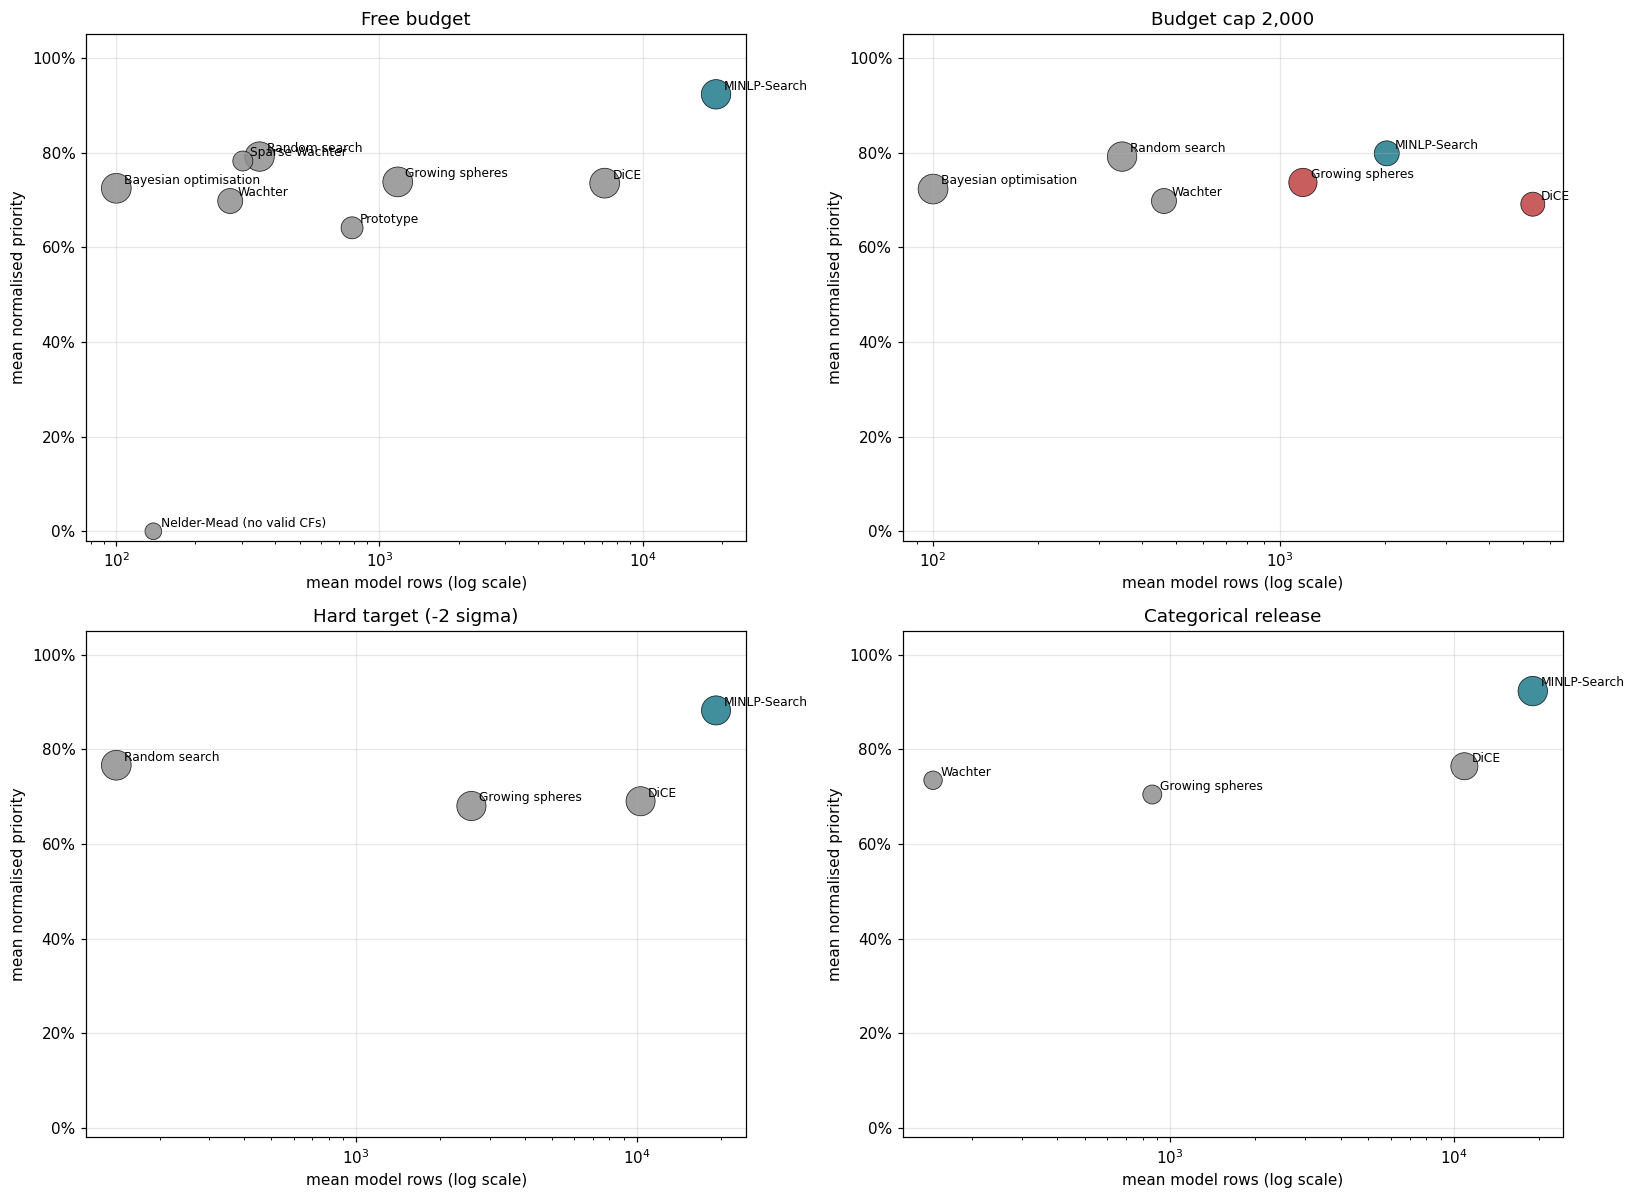

#### Regime overview

regime,method,validity,priority,model rows,time (s),budget fail,n valid
Free budget,MINLP-Search,0.966667,0.922923,19030.488889,1.310225,0.000000,87
Free budget,Random search,0.966667,0.791438,350.411111,0.552915,0.000000,87
Free budget,DiCE,1.000000,0.735272,7180.122222,1.632587,0.000000,90
Free budget,Growing spheres,1.000000,0.737969,1173.944444,1.522957,0.000000,90
Free budget,Bayesian optimisation,1.000000,0.724437,100.000000,0.339107,0.000000,90
Free budget,Wachter,0.566667,0.697608,271.033333,2.019601,0.000000,51
Free budget,Sparse Wachter,0.200000,0.782068,302.666667,3.676503,0.000000,18
Free budget,Prototype,0.333333,0.640990,787.200000,3.369937,0.000000,30
Free budget,Nelder-Mead,0.000000,-,138.300000,0.186813,0.000000,0
"Budget cap 2,000",MINLP-Search,0.566667,0.798254,2028.655556,0.272306,0.000000,51


#### Free-budget paired comparisons against MINLP

method,pairs,delta vs MINLP,paired priority (arm),paired priority (ref),wins,losses,priority p,effect size
Prototype,30,-0.268241,0.640990,0.909231,0,30,0.000000,-0.986667
Wachter,51,-0.220092,0.697608,0.917700,0,51,0.000000,-0.949250
Bayesian optimisation,87,-0.196907,0.726016,0.922923,1,86,0.000000,-0.940811
DiCE,87,-0.185677,0.737246,0.922923,0,87,0.000000,-0.900647
Growing spheres,87,-0.182952,0.739971,0.922923,1,86,0.000000,-0.907253
Sparse Wachter,18,-0.158756,0.782068,0.940824,1,17,0.000015,-0.759259
Random search,87,-0.131485,0.791438,0.922923,5,82,0.000000,-0.746334


#### What the 2,000-row budget cap changes

...

Output()

**Raw counterfactual row browser**

Output()

#### Interpretation

- Study III is the cleanest external comparison in the notebook because, within each regime, the task is fixed and only the method changes: same dataset, same source case, same target, same tolerance, same feasible region, and the same number of requested counterfactuals.
- The **free-budget** result is the headline competitive claim: **MINLP-Search** reaches a mean normalised priority of **92.3%** at validity **96.7%**, while the best non-MINLP competitor here is **Random search** at **79.1%** and validity **96.7%**.
- The paired table matters more than the regime-average bar alone. A negative `delta vs MINLP` means the baseline method loses on the same matched tasks, so the result is not just a different success subset or a different dataset mix.
- The **2,000-row budget cap** changes the scientific claim. Under that cap, **MINLP-Search** falls to validity **56.7%** and priority **79.8%**, while the best competitor in that regime is **Random search** at **79.1%**. So any superiority claim for MINLP has to be stated as a claim about the **high-budget regime**, not as a budget-invariant fact.
- The **hard-target regime** is where priority-aware search is expected to matter most, because the feasible target region is farther away. Here MINLP reaches **88.2%** priority with validity **93.3%**, compared with the best non-MINLP competitor **Random search** at **76.6%**.
- The **categorical-release regime** is not a new method family; it is a fairness stress test for baselines that normally keep one-hot groups pinned. If `allow_categorical` improves priority but hurts validity after one-hot repair, that means category handling must live inside the search procedure rather than as a post-hoc fix.
- The largest validity hit after releasing categoricals is **Growing spheres**, where validity moves by -86.7%. That is the key warning sign in this regime: extra categorical freedom can help search superficially while breaking target-band validity after repair.
- Quality metrics in this section are always conditional on valid counterfactuals. That means a method with high average priority but low validity is not 'better' in a practical sense; it is just better on the smaller subset of cases it solved. The regime tables therefore need to be read in the order: validity first, priority second, cost third.

In [36]:
from IPython.display import HTML
from matplotlib.ticker import PercentFormatter

study3_root = RESULTS_ROOT / "study3_comparison"
study3_analysis_dir = study3_root / "analysis"
study3_analysis_dir.mkdir(parents=True, exist_ok=True)

study3_index = pd.read_csv(study3_root / "index.csv")
study3_cf = study("study3_comparison").copy()


def _study3_html(obj, index=False):
    if isinstance(obj, pd.DataFrame):
        html = obj.to_html(index=index)
    else:
        html = obj.to_html()
    return HTML(f"<div style='overflow-x:auto; max-width:100%;'>{html}</div>")


def _study3_format_table(df):
    percent_cols = [
        col for col in [
            "validity", "priority", "budget fail", "delta vs MINLP",
            "validity (free)", "validity (variant)", "validity delta",
            "priority (free)", "priority (variant)", "priority delta",
            "priority gain vs base", "priority delta vs free",
        ] if col in df.columns
    ]
    float_cols = [
        col for col in [
            "model rows", "time (s)", "l1", "rows ratio", "priority p",
            "effect size", "mean priority", "mean rows", "priority (MINLP)",
            "priority (other)", "paired priority (ref)", "paired priority (arm)",
            "ci low", "ci high",
        ] if col in df.columns
    ]
    int_cols = [
        col for col in [
            "n", "n valid", "pairs", "wins", "losses", "ties", "seed", "sample_id"
        ] if col in df.columns
    ]
    style = df.style
    if percent_cols:
        style = style.format({col: "{:.1%}" for col in percent_cols}, na_rep="-")
    if float_cols:
        style = style.format({col: "{:.3f}" for col in float_cols}, na_rep="-")
    if int_cols:
        style = style.format({col: "{:,.0f}" for col in int_cols}, na_rep="-")
    return style


STUDY3_METHOD_LABELS = {
    "minlp": "MINLP-Search",
    "random_search": "Random search",
    "dice": "DiCE",
    "wachter": "Wachter",
    "sparse_wachter": "Sparse Wachter",
    "prototype": "Prototype",
    "growing_spheres": "Growing spheres",
    "nelder_mead": "Nelder-Mead",
    "bayesian_optimization": "Bayesian optimisation",
}

STUDY3_METHOD_ORDER = [
    "minlp", "random_search", "dice", "growing_spheres", "bayesian_optimization",
    "wachter", "sparse_wachter", "prototype", "nelder_mead",
]

STUDY3_REGIME_LABELS = {
    "free_budget": "Free budget",
    "budget2k": "Budget cap 2,000",
    "hard_target": "Hard target (-2 sigma)",
    "categorical_release": "Categorical release",
}

STUDY3_REGIME_ORDER = [
    "free_budget", "budget2k", "hard_target", "categorical_release",
]

STUDY3_REFERENCE_ARM = {
    "free_budget": "minlp",
    "budget2k": "minlp_budget2k",
    "hard_target": "minlp_hard_target",
    "categorical_release": "minlp",
}


def _study3_regime_from_arm(arm):
    text = str(arm)
    if text.endswith("_budget2k"):
        return "budget2k"
    if text.endswith("_hard_target"):
        return "hard_target"
    if text.endswith("_cat"):
        return "categorical_release"
    return "free_budget"


def _study3_base_method_from_arm(arm):
    text = str(arm)
    for suffix in ["_budget2k", "_hard_target", "_cat"]:
        if text.endswith(suffix):
            return text[: -len(suffix)]
    return text


def _study3_method_sort_key(method_name):
    try:
        return STUDY3_METHOD_ORDER.index(method_name)
    except ValueError:
        return len(STUDY3_METHOD_ORDER)


study3_cf["regime"] = study3_cf["arm"].map(_study3_regime_from_arm)
study3_cf["regime_label"] = study3_cf["regime"].map(STUDY3_REGIME_LABELS)
study3_cf["base_method"] = study3_cf["arm"].map(_study3_base_method_from_arm)
study3_cf["method_label"] = study3_cf["base_method"].map(STUDY3_METHOD_LABELS).fillna(study3_cf["base_method"])
,
study3_cf["validity_num"] = study3_cf["validity"].fillna(False).astype(float)
study3_cf["budget_fail"] = study3_cf.get("error", pd.Series("", index=study3_cf.index)).eq("budget_exceeded").astype(float)

study3_index["regime"] = study3_index["arm"].map(_study3_regime_from_arm)
study3_index["regime_label"] = study3_index["regime"].map(STUDY3_REGIME_LABELS)
study3_index["base_method"] = study3_index["arm"].map(_study3_base_method_from_arm)
study3_index["method_label"] = study3_index["base_method"].map(STUDY3_METHOD_LABELS).fillna(study3_index["base_method"])
,
all_study3_arms = sorted(set(study3_cf["arm"]))


def _study3_arms_for_regime(regime):
    if regime == "categorical_release":
        arms = [arm for arm in all_study3_arms if arm.endswith("_cat")]
        if "minlp" in all_study3_arms:
            arms = ["minlp"] + sorted(arms, key=lambda arm: (_study3_method_sort_key(_study3_base_method_from_arm(arm)), arm))
        return arms
    arms = [arm for arm in all_study3_arms if _study3_regime_from_arm(arm) == regime]
    return sorted(arms, key=lambda arm: (_study3_method_sort_key(_study3_base_method_from_arm(arm)), arm))


study3_summary_rows = []
for regime in STUDY3_REGIME_ORDER:
    for arm in _study3_arms_for_regime(regime):
        subset = study3_cf.loc[study3_cf["arm"] == arm].copy()
        if subset.empty:
            continue
        valid = subset.loc[subset["validity"] == True].copy()
        study3_summary_rows.append({
            "regime": regime,
            "regime label": STUDY3_REGIME_LABELS[regime],
            "arm": arm,
            "base_method": _study3_base_method_from_arm(arm),
            "method": STUDY3_METHOD_LABELS.get(_study3_base_method_from_arm(arm), _study3_base_method_from_arm(arm)),
            "n": int(len(subset)),
            "n valid": int(valid.shape[0]),
            "validity": float(subset["validity_num"].mean()),
            "priority": float(valid["priority_score_normalised"].mean()) if not valid.empty else np.nan,
            "l1": float(valid["l1"].mean()) if not valid.empty else np.nan,
            "model rows": float(subset["model_rows"].mean()),
            "time (s)": float(subset["time_seconds"].mean()),
            "budget fail": float(subset["budget_fail"].mean()),
        })

study3_summary = pd.DataFrame(study3_summary_rows)
study3_summary["method_order"] = study3_summary["base_method"].map(_study3_method_sort_key)
study3_summary["regime_order"] = study3_summary["regime"].map({name: idx for idx, name in enumerate(STUDY3_REGIME_ORDER)})
study3_summary = study3_summary.sort_values(["regime_order", "method_order", "arm"]).reset_index(drop=True)
study3_summary.to_csv(study3_analysis_dir / "regime_summary.csv", index=False)


study3_paired_rows = []
for regime in STUDY3_REGIME_ORDER:
    reference_arm = STUDY3_REFERENCE_ARM[regime]
    arms = [arm for arm in _study3_arms_for_regime(regime) if arm != reference_arm]
    for arm in arms:
        subset = study3_cf.loc[study3_cf["arm"].isin([arm, reference_arm])].copy()
        subset = subset.loc[subset["validity"] == True].copy()
        if subset.empty or subset["arm"].nunique() < 2:
            continue
        try:
            result = stats.paired_comparison(
                subset,
                arm,
                reference_arm,
                by="arm",
                value_col="priority_score_normalised",
            )
        except Exception:
            continue
        study3_paired_rows.append({
            "regime": regime,
            "regime label": STUDY3_REGIME_LABELS[regime],
            "arm": arm,
            "method": STUDY3_METHOD_LABELS.get(_study3_base_method_from_arm(arm), _study3_base_method_from_arm(arm)),
            "reference": STUDY3_METHOD_LABELS.get(_study3_base_method_from_arm(reference_arm), _study3_base_method_from_arm(reference_arm)),
            "pairs": int(result.n_pairs),
            "paired priority (arm)": float(result.mean_a),
            "paired priority (ref)": float(result.mean_b),
            "delta vs MINLP": float(result.mean_delta),
            "wins": int(result.wins_a),
            "losses": int(result.wins_b),
            "ties": int(result.ties),
            "priority p": float(result.wilcoxon_p) if pd.notna(result.wilcoxon_p) else np.nan,
            "effect size": float(result.cliffs_delta) if pd.notna(result.cliffs_delta) else np.nan,
            "ci low": float(result.delta_ci_low) if pd.notna(result.delta_ci_low) else np.nan,
            "ci high": float(result.delta_ci_high) if pd.notna(result.delta_ci_high) else np.nan,
        })

study3_paired = pd.DataFrame(study3_paired_rows)
if not study3_paired.empty:
    study3_paired["method_order"] = study3_paired["arm"].map(lambda arm: _study3_method_sort_key(_study3_base_method_from_arm(arm)))
    study3_paired["regime_order"] = study3_paired["regime"].map({name: idx for idx, name in enumerate(STUDY3_REGIME_ORDER)})
    study3_paired = study3_paired.sort_values(["regime_order", "method_order", "arm"]).reset_index(drop=True)
study3_paired.to_csv(study3_analysis_dir / "regime_paired.csv", index=False)


study3_budget_rows = []
for arm in [name for name in all_study3_arms if name.endswith("_budget2k")]:
    base_arm = _study3_base_method_from_arm(arm)
    if base_arm not in all_study3_arms:
        continue
    base_summary = study3_summary.loc[study3_summary["arm"] == base_arm]
    budget_summary = study3_summary.loc[study3_summary["arm"] == arm]
    if base_summary.empty or budget_summary.empty:
        continue
    base_summary = base_summary.iloc[0]
    budget_summary = budget_summary.iloc[0]
    paired_row = study3_paired.loc[study3_paired["arm"] == arm]
    delta_priority = float(paired_row["delta vs MINLP"].iloc[0]) if (not paired_row.empty and base_arm == "minlp") else np.nan
    study3_budget_rows.append({
        "method": budget_summary["method"],
        "validity (free)": float(base_summary["validity"]),
        "validity (variant)": float(budget_summary["validity"]),
        "validity delta": float(budget_summary["validity"] - base_summary["validity"]),
        "priority (free)": float(base_summary["priority"]) if pd.notna(base_summary["priority"]) else np.nan,
        "priority (variant)": float(budget_summary["priority"]) if pd.notna(budget_summary["priority"]) else np.nan,
        "priority delta": (
            float(budget_summary["priority"] - base_summary["priority"])
            if pd.notna(base_summary["priority"]) and pd.notna(budget_summary["priority"])
            else np.nan
        ),
        "rows ratio": float(budget_summary["model rows"] / base_summary["model rows"]) if base_summary["model rows"] else np.nan,
        "budget fail": float(budget_summary["budget fail"]),
    })

study3_budget_display = pd.DataFrame(study3_budget_rows).sort_values("priority (variant)", ascending=False)
study3_budget_display.to_csv(study3_analysis_dir / "budget2k_delta.csv", index=False)


study3_cat_rows = []
for arm in [name for name in all_study3_arms if name.endswith("_cat")]:
    base_arm = _study3_base_method_from_arm(arm)
    if base_arm not in all_study3_arms:
        continue
    base_summary = study3_summary.loc[study3_summary["arm"] == base_arm]
    cat_summary = study3_summary.loc[study3_summary["arm"] == arm]
    if base_summary.empty or cat_summary.empty:
        continue
    base_summary = base_summary.iloc[0]
    cat_summary = cat_summary.iloc[0]
    subset = study3_cf.loc[study3_cf["arm"].isin([arm, base_arm])].copy()
    subset = subset.loc[subset["validity"] == True].copy()
    priority_gain = np.nan
    priority_p = np.nan
    if not subset.empty and subset["arm"].nunique() == 2:
        try:
            result = stats.paired_comparison(subset, arm, base_arm, by="arm", value_col="priority_score_normalised")
            priority_gain = float(result.mean_delta)
            priority_p = float(result.wilcoxon_p) if pd.notna(result.wilcoxon_p) else np.nan
        except Exception:
            pass
    study3_cat_rows.append({
        "method": cat_summary["method"],
        "validity (free)": float(base_summary["validity"]),
        "validity (variant)": float(cat_summary["validity"]),
        "validity delta": float(cat_summary["validity"] - base_summary["validity"]),
        "priority (free)": float(base_summary["priority"]) if pd.notna(base_summary["priority"]) else np.nan,
        "priority (variant)": float(cat_summary["priority"]) if pd.notna(cat_summary["priority"]) else np.nan,
        "priority gain vs base": priority_gain,
        "priority p": priority_p,
    })

study3_cat_display = pd.DataFrame(study3_cat_rows).sort_values("priority gain vs base", ascending=False)
study3_cat_display.to_csv(study3_analysis_dir / "categorical_release_delta.csv", index=False)


fig, axes = plt.subplots(2, 2, figsize=(15, 11))
for axis, regime in zip(axes.flat, STUDY3_REGIME_ORDER):
    view = study3_summary.loc[study3_summary["regime"] == regime].copy()
    if view.empty:
        axis.set_visible(False)
        continue
    y_values = view["priority"].fillna(0.0).to_numpy(dtype=float)
    x_values = view["model rows"].to_numpy(dtype=float)
    sizes = 120 + 260 * view["validity"].to_numpy(dtype=float)
    colours = [
        "#1f7a8c" if row["base_method"] == "minlp" else ("#bf4342" if row["budget fail"] > 0 else "#8f8f8f")
        for _, row in view.iterrows()
    ]
    axis.scatter(x_values, y_values, s=sizes, c=colours, alpha=0.85, edgecolors="black", linewidths=0.5)
    for _, row in view.iterrows():
        label = row["method"]
        if pd.isna(row["priority"]):
            label = f"{label} (no valid CFs)"
        axis.annotate(label, (row["model rows"], 0.0 if pd.isna(row["priority"]) else row["priority"]), fontsize=8, xytext=(5, 3), textcoords="offset points")
    axis.set_xscale("log")
    axis.set_title(STUDY3_REGIME_LABELS[regime])
    axis.set_xlabel("mean model rows (log scale)")
    axis.set_ylabel("mean normalised priority")
    axis.set_ylim(-0.02, 1.05)
    axis.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.show()

study3_overview_display = study3_summary[[
    "regime label", "method", "validity", "priority", "model rows", "time (s)", "budget fail", "n valid"
 ]].rename(columns={
    "regime label": "regime",
})

study3_free_paired_display = study3_paired.loc[study3_paired["regime"] == "free_budget", [
    "method", "pairs", "delta vs MINLP", "paired priority (arm)", "paired priority (ref)",
    "wins", "losses", "priority p", "effect size",
]].sort_values("delta vs MINLP") if not study3_paired.empty else pd.DataFrame()

display(Markdown("#### Regime overview"))
display(_study3_html(_study3_format_table(study3_overview_display).hide(axis="index")))

if not study3_free_paired_display.empty:
    display(Markdown("#### Free-budget paired comparisons against MINLP"))
    display(_study3_html(_study3_format_table(study3_free_paired_display).hide(axis="index")))

if not study3_budget_display.empty:
    display(Markdown("#### What the 2,000-row budget cap changes"))
    display(_study3_html(_study3_format_table(study3_budget_display).hide(axis="index")))

if not study3_cat_display.empty:
    display(Markdown("#### What releasing categoricals buys the baseline methods"))
    display(_study3_html(_study3_format_table(study3_cat_display).hide(axis="index")))

display(Markdown("#### Interactive Study III browser"))

study3_metric_map = {
    "Priority": "priority",
    "Validity": "validity",
    "Model rows": "model rows",
    "Budget fail": "budget fail",
    "L1 distance": "l1",
}

study3_regime_dropdown = widgets.Dropdown(
    options=[(STUDY3_REGIME_LABELS[name], name) for name in STUDY3_REGIME_ORDER],
    value="free_budget",
    description="Regime:",
    layout=widgets.Layout(width="260px"),
)
study3_metric_dropdown = widgets.Dropdown(
    options=list(study3_metric_map.keys()),
    value="Priority",
    description="Metric:",
    layout=widgets.Layout(width="220px"),
)
study3_display_dropdown = widgets.Dropdown(
    options=["bar", "scatter", "table"],
    value="bar",
    description="Display:",
    layout=widgets.Layout(width="220px"),
)
study3_summary_output = widgets.Output()


def _study3_render_summary(regime, metric_label, display_mode):
    metric = study3_metric_map[metric_label]
    view = study3_summary.loc[study3_summary["regime"] == regime].copy()
    if view.empty:
        with study3_summary_output:
            clear_output(wait=True)
            display(Markdown("No rows match the selected regime."))
        return
    view = view.sort_values(metric, ascending=(metric in {"model rows", "budget fail", "l1"}))
    with study3_summary_output:
        clear_output(wait=True)
        if display_mode == "table":
            table = view[["method", "validity", "priority", "model rows", "budget fail", "l1", "n valid"]]
            display(_study3_html(_study3_format_table(table).hide(axis="index")))
            return
        if display_mode == "scatter":
            fig, ax = plt.subplots(figsize=(9.5, 4.8))
            x_vals = view["model rows"].to_numpy(dtype=float)
            y_vals = view[metric].fillna(0.0).to_numpy(dtype=float)
            colours = ["#1f7a8c" if name == "minlp" else "#8f8f8f" for name in view["base_method"]]
            ax.scatter(x_vals, y_vals, s=130 + 240 * view["validity"].to_numpy(dtype=float), c=colours, edgecolors="black", linewidths=0.5)
            for _, row in view.iterrows():
                ax.annotate(row["method"], (row["model rows"], 0.0 if pd.isna(row[metric]) else row[metric]), fontsize=8, xytext=(5, 3), textcoords="offset points")
            ax.set_xscale("log")
            ax.set_xlabel("mean model rows (log scale)")
            ax.set_ylabel(metric_label)
            if metric in {"priority", "validity", "budget fail"}:
                ax.yaxis.set_major_formatter(PercentFormatter(1.0))
            ax.set_title(f"{STUDY3_REGIME_LABELS[regime]}: {metric_label}")
            plt.show()
            return
        fig, ax = plt.subplots(figsize=(10, 4.8))
        values = view[metric].fillna(0.0).to_numpy(dtype=float)
        colours = np.where(view["base_method"].eq("minlp"), "#1f7a8c", np.where(values >= 0, "#8f8f8f", "#bf4342"))
        ax.bar(view["method"], values, color=colours)
        if metric in {"priority", "validity", "budget fail"}:
            ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.set_ylabel(metric_label)
        ax.set_title(f"{STUDY3_REGIME_LABELS[regime]}: {metric_label}")
        ax.tick_params(axis="x", rotation=30)
        plt.show()


study3_summary_controls = widgets.HBox([
    study3_regime_dropdown,
    study3_metric_dropdown,
    study3_display_dropdown,
])
display(study3_summary_controls)
study3_summary_binding = widgets.interactive_output(
    _study3_render_summary,
    {
        "regime": study3_regime_dropdown,
        "metric_label": study3_metric_dropdown,
        "display_mode": study3_display_dropdown,
    },
)
display(study3_summary_output)


display(Markdown("**Paired comparison browser**"))
study3_pair_regime = widgets.Dropdown(
    options=[(STUDY3_REGIME_LABELS[name], name) for name in STUDY3_REGIME_ORDER],
    value="free_budget",
    description="Regime:",
    layout=widgets.Layout(width="260px"),
)
study3_pair_output = widgets.Output()


def _study3_render_pairs(regime):
    view = study3_paired.loc[study3_paired["regime"] == regime].copy() if not study3_paired.empty else pd.DataFrame()
    with study3_pair_output:
        clear_output(wait=True)
        if view.empty:
            display(Markdown("No paired priority comparisons are available for the selected regime."))
            return
        view = view[[
            "method", "pairs", "delta vs MINLP", "paired priority (arm)", "paired priority (ref)",
            "wins", "losses", "priority p", "effect size", "ci low", "ci high",
        ]].sort_values("delta vs MINLP")
        display(_study3_html(_study3_format_table(view).hide(axis="index")))
        fig, ax = plt.subplots(figsize=(8.5, 0.55 * len(view) + 1.8))
        y = np.arange(len(view))
        ax.errorbar(view["delta vs MINLP"], y, xerr=[view["delta vs MINLP"] - view["ci low"], view["ci high"] - view["delta vs MINLP"]], fmt="none", ecolor="0.6")
        ax.scatter(view["delta vs MINLP"], y, color=np.where(view["delta vs MINLP"] >= 0, "#2a9d8f", "#bf4342"), s=55, zorder=3)
        ax.axvline(0.0, color="black", linewidth=1)
        ax.set_yticks(y)
        ax.set_yticklabels(view["method"])
        ax.set_xlabel("priority delta vs MINLP")
        ax.xaxis.set_major_formatter(PercentFormatter(1.0))
        ax.set_title(f"{STUDY3_REGIME_LABELS[regime]}: paired priority deltas")
        plt.show()


study3_pair_controls = widgets.HBox([study3_pair_regime])
display(study3_pair_controls)
study3_pair_binding = widgets.interactive_output(_study3_render_pairs, {"regime": study3_pair_regime})
display(study3_pair_output)


display(Markdown("**Run-level summary browser**"))
study3_run_regime = widgets.Dropdown(
    options=[("All regimes", "all")] + [(STUDY3_REGIME_LABELS[name], name) for name in STUDY3_REGIME_ORDER],
    value="all",
    description="Regime:",
    layout=widgets.Layout(width="250px"),
)
study3_run_method = widgets.Dropdown(
    options=[("All methods", "all")] + [(label, method) for method, label in STUDY3_METHOD_LABELS.items()],
    value="all",
    description="Method:",
    layout=widgets.Layout(width="240px"),
)
study3_run_dataset = widgets.Dropdown(
    options=[("All datasets", "all")] + [(name, name) for name in sorted(study3_index["dataset"].unique())],
    value="all",
    description="Dataset:",
    layout=widgets.Layout(width="280px"),
)
study3_run_output = widgets.Output()


def _study3_render_runs(regime, method, dataset):
    subset = study3_index.copy()
    if regime != "all":
        subset = subset.loc[subset["regime"] == regime]
    if method != "all":
        subset = subset.loc[subset["base_method"] == method]
    if dataset != "all":
        subset = subset.loc[subset["dataset"] == dataset]
    subset = subset[[
        "regime_label", "method_label", "arm", "dataset", "seed",
        "avg_priority_score_normalised", "n_cfs_valid", "avg_model_rows", "avg_time_seconds",
    ]].rename(columns={
        "regime_label": "regime",
        "method_label": "method",
        "avg_priority_score_normalised": "mean priority",
        "n_cfs_valid": "n valid",
        "avg_model_rows": "mean rows",
        "avg_time_seconds": "time (s)",
    })
    with study3_run_output:
        clear_output(wait=True)
        if subset.empty:
            display(Markdown("No run rows match the selected filters."))
            return
        display(_study3_html(_study3_format_table(subset).hide(axis="index")))


study3_run_controls = widgets.HBox([
    study3_run_regime,
    study3_run_method,
    study3_run_dataset,
])
display(study3_run_controls)
study3_run_binding = widgets.interactive_output(
    _study3_render_runs,
    {
        "regime": study3_run_regime,
        "method": study3_run_method,
        "dataset": study3_run_dataset,
    },
)
display(study3_run_output)


display(Markdown("**Raw counterfactual row browser**"))
study3_cf_regime = widgets.Dropdown(
    options=[("All regimes", "all")] + [(STUDY3_REGIME_LABELS[name], name) for name in STUDY3_REGIME_ORDER],
    value="all",
    description="Regime:",
    layout=widgets.Layout(width="250px"),
)
study3_cf_method = widgets.Dropdown(
    options=[("All methods", "all")] + [(label, method) for method, label in STUDY3_METHOD_LABELS.items()],
    value="all",
    description="Method:",
    layout=widgets.Layout(width="240px"),
)
study3_cf_dataset = widgets.Dropdown(
    options=[("All datasets", "all")] + [(name, name) for name in sorted(study3_cf["dataset"].unique())],
    value="all",
    description="Dataset:",
    layout=widgets.Layout(width="280px"),
)
study3_cf_validity = widgets.Dropdown(
    options=[("All rows", "all"), ("Valid only", "valid"), ("Invalid only", "invalid")],
    value="all",
    description="Validity:",
    layout=widgets.Layout(width="220px"),
)
study3_cf_limit = widgets.IntSlider(value=12, min=5, max=30, step=1, description="Rows:", layout=widgets.Layout(width="240px"))
study3_cf_output = widgets.Output()


def _study3_render_cf_rows(regime, method, dataset, validity_filter, limit):
    subset = study3_cf.copy()
    if regime != "all":
        subset = subset.loc[subset["regime"] == regime]
    if method != "all":
        subset = subset.loc[subset["base_method"] == method]
    if dataset != "all":
        subset = subset.loc[subset["dataset"] == dataset]
    if validity_filter == "valid":
        subset = subset.loc[subset["validity"] == True]
    elif validity_filter == "invalid":
        subset = subset.loc[subset["validity"] != True]
    subset = subset[[
        "regime_label", "method_label", "arm", "dataset", "sample_id", "seed",
        "validity", "priority_score_normalised", "l1", "model_rows", "time_seconds",
        "cf_source", "error",
    ]].head(limit).rename(columns={
        "regime_label": "regime",
        "method_label": "method",
        "priority_score_normalised": "priority",
        "time_seconds": "time (s)",
        "cf_source": "cf source",
    })
    with study3_cf_output:
        clear_output(wait=True)
        if subset.empty:
            display(Markdown("No counterfactual rows match the selected filters."))
            return
        display(_study3_html(_study3_format_table(subset).hide(axis="index")))


study3_cf_controls = widgets.HBox([
    study3_cf_regime,
    study3_cf_method,
    study3_cf_dataset,
    study3_cf_validity,
    study3_cf_limit,
])
display(study3_cf_controls)
study3_cf_binding = widgets.interactive_output(
    _study3_render_cf_rows,
    {
        "regime": study3_cf_regime,
        "method": study3_cf_method,
        "dataset": study3_cf_dataset,
        "validity_filter": study3_cf_validity,
        "limit": study3_cf_limit,
    },
)
display(study3_cf_output)


display(Markdown("#### Interpretation"))

free_view = study3_summary.loc[study3_summary["regime"] == "free_budget"].copy()
free_minlp = free_view.loc[free_view["arm"] == "minlp"].iloc[0]
free_best_other = free_view.loc[free_view["arm"] != "minlp"].sort_values(["priority", "validity"], ascending=[False, False]).iloc[0]

budget_view = study3_summary.loc[study3_summary["regime"] == "budget2k"].copy()
budget_minlp = budget_view.loc[budget_view["arm"] == "minlp_budget2k"].iloc[0]
budget_best_other = budget_view.loc[budget_view["arm"] != "minlp_budget2k"].sort_values(["priority", "validity"], ascending=[False, False]).iloc[0]

hard_view = study3_summary.loc[study3_summary["regime"] == "hard_target"].copy()
hard_minlp = hard_view.loc[hard_view["arm"] == "minlp_hard_target"].iloc[0]
hard_best_other = hard_view.loc[hard_view["arm"] != "minlp_hard_target"].sort_values(["priority", "validity"], ascending=[False, False]).iloc[0]

cat_biggest = study3_cat_display.sort_values("validity delta").iloc[0] if not study3_cat_display.empty else None

display(Markdown(
    "\n".join([
        "- Study III is the cleanest external comparison in the notebook because, within each regime, the task is fixed and only the method changes: same dataset, same source case, same target, same tolerance, same feasible region, and the same number of requested counterfactuals.",
        "- The **free-budget** result is the headline competitive claim: **MINLP-Search** reaches a mean normalised priority of "
        f"**{free_minlp['priority']:.1%}** at validity **{free_minlp['validity']:.1%}**, while the best non-MINLP competitor here is **{free_best_other['method']}** at **{free_best_other['priority']:.1%}** and validity **{free_best_other['validity']:.1%}**.",
        "- The paired table matters more than the regime-average bar alone. A negative `delta vs MINLP` means the baseline method loses on the same matched tasks, so the result is not just a different success subset or a different dataset mix.",
        "- The **2,000-row budget cap** changes the scientific claim. Under that cap, **MINLP-Search** falls to validity **"
        f"{budget_minlp['validity']:.1%}** and priority **{budget_minlp['priority']:.1%}**, while the best competitor in that regime is **{budget_best_other['method']}** at **{budget_best_other['priority']:.1%}**. So any superiority claim for MINLP has to be stated as a claim about the **high-budget regime**, not as a budget-invariant fact.",
        "- The **hard-target regime** is where priority-aware search is expected to matter most, because the feasible target region is farther away. Here MINLP reaches **"
        f"{hard_minlp['priority']:.1%}** priority with validity **{hard_minlp['validity']:.1%}**, compared with the best non-MINLP competitor **{hard_best_other['method']}** at **{hard_best_other['priority']:.1%}**.",
        "- The **categorical-release regime** is not a new method family; it is a fairness stress test for baselines that normally keep one-hot groups pinned. If `allow_categorical` improves priority but hurts validity after one-hot repair, that means category handling must live inside the search procedure rather than as a post-hoc fix.",
        (
            f"- The largest validity hit after releasing categoricals is **{cat_biggest['method']}**, where validity moves by {cat_biggest['validity delta']:.1%}. "
            f"That is the key warning sign in this regime: extra categorical freedom can help search superficially while breaking target-band validity after repair."
            if cat_biggest is not None else "- No categorical-release delta table was available."
        ),
        "- Quality metrics in this section are always conditional on valid counterfactuals. That means a method with high average priority but low validity is not 'better' in a practical sense; it is just better on the smaller subset of cases it solved. The regime tables therefore need to be read in the order: validity first, priority second, cost third.",
    ])))